# 🏺 Hieroglyph → Meaning — Unified Full Pipeline
### صورة ➜ (CV) ➜ كود جاردنر ➜ (NLP) ➜ ترجمة ألماني/إنجليزي/عربي + Sentiment + Intention

الانبوت **صورة واحدة**. كل الـ stages بتشتغل ورا بعض **في الباك جراوند**:

```
Image
  └─[CV]  Layout → Sign-Segmentation → Classification → Reading-Order → Gardiner codes
            └─[NLP] Stage1 (phonetics) → Stage2 (ByT5 assemble) → RAG/NLLB (German)
                      ├─ Seed-X: German → English
                      ├─ Seed-X: German → Arabic
                      ├─ Sentiment (domain-aware)
                      └─ Intention (TF-IDF bilingual)
```

الـ **User بيشوف بس**: الصورة الأصلية زي ما هي + الترجمة الإنجليزي + الترجمة العربي + الـ Sentiment + الـ Intention.
الفريمات بتاعة السجمنتيشن/الكلاسفكيشن/الأوردر/الجاردنر كود **مش بتتعرض** — كلها بتتشال في الباك جراوند.

> الباثات كلها زي ما هي بالظبط من السكريبتين الأصليين. شغّل الخلايا بالترتيب من فوق لتحت، وآخر خلية بتاخد الصورة وتطلع الناتج النضيف.

---
**Intention overhaul (matches NLP pipeline):** uses the expanded 57-intention `hieroglyph_intentions.csv` (natural Seed-X/NLLB EN vocabulary + `النية بالعربي` column). `IntentionClassifier` rewritten from TF-IDF cosine → IDF-weighted token-overlap scorer + optative/formula rules; Arabic label now read straight from the dataset in both the short and long (multi-line) paths.


# ═══════════════════════════════════════════════
# PART A — Computer Vision  (Image → Gardiner codes)
# ═══════════════════════════════════════════════

## A1 — Install CV dependencies

In [1]:
!pip install ultralytics timm scikit-learn -q
import ultralytics, timm, torch
print("ultralytics:", ultralytics.__version__)
print("timm       :", timm.__version__)
print("torch      :", torch.__version__, "| CUDA:", torch.cuda.is_available())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.7 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[

## A2 — CV Imports & Global Config

In [2]:
import os, sys, json, random, warnings, math
import numpy as np
import cv2
from pathlib import Path
from PIL import Image
from collections import Counter, defaultdict
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torch.amp import autocast

import timm
from ultralytics import YOLO

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
N_GPUS  = torch.cuda.device_count()
print(f"Device : {DEVICE} | GPUs: {N_GPUS} | AMP: {USE_AMP}")


Device : cuda | GPUs: 2 | AMP: True


## A3 — Model Paths  (نفس الباثات بالظبط)

In [3]:
CVV_MODELS_DIR = "/kaggle/input/notebooks/moaztest/classification-162gardinercode/cvv_models"

In [4]:
# ================================================================
#  ★  عدّل المسارات دي حسب بيئتك
# ================================================================

# Layout YOLO-seg  (output of layout-final notebook)
#/kaggle/input/notebooks/freedie28/layout-final/hla_yolo/images/train/00.4.60_EGDP018075.jpg
LAYOUT_WEIGHTS  = '/kaggle/input/notebooks/freedie28/layout-final/runs/layout_analysis/weights/best.pt'
LAYOUT_IMG_SIZE = 1024          # trained at 1024

# Sign / glyph YOLO detector  (output of sign-segment-final notebook)
#/kaggle/input/notebooks/freedie28/sign-segment-final/big-new-2-1/labels_original_803class/test/Egyptian-hieroglyphs-stock-image_-Image-of-alphabet-sculpted-4995767_jpg.rf.50fe2ee7d4215ab083d569221a9de16e.txt

SIGN_WEIGHTS    = '/kaggle/input/notebooks/freedie28/sign-segment-final/runs/detect/hieroglyph_yolo/yolo_single_class/weights/best.pt'
SIGN_IMG_SIZE   = 640           # trained at 640

# ConvNeXt CVV folds  (output of classification notebook)
#CVV_MODELS_DIR  = 'cvv_models'  # folder containing fold_0_final.pt … fold_4_final.pt
K_FOLDS         = 5

# ── Classification hypers (must match training) ──────────────────
IMG_SIZE          = 224
CONVNEXT_BACKBONE = 'convnext_base'
DROP_PATH_RATE    = 0.10
HEAD_DROPOUT      = 0.20

# ── Class mappings  (auto-loaded from cvv_models/label_maps.json) ─
LABEL_MAPS_PATH = os.path.join(CVV_MODELS_DIR, 'label_maps.json')
assert os.path.exists(LABEL_MAPS_PATH), \
    f"label_maps.json not found at {LABEL_MAPS_PATH}.\n" \
    "Run the classification notebook first to produce cvv_models/label_maps.json"

with open(LABEL_MAPS_PATH) as f:
    _lm = json.load(f)

# CLASS_NAMES  = _lm['CLASS_NAMES']
# CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
# IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
# NUM_CLASSES  = len(CLASS_NAMES)

# DIRECTIONS     = ['dual', 'left', 'right']
# DIR_TO_IDX     = {d: i for i, d in enumerate(DIRECTIONS)}
# IDX_TO_DIR     = {i: d for d, i in DIR_TO_IDX.items()}
# NUM_DIRECTIONS = len(DIRECTIONS)

CLASS_NAMES = _lm['sign_classes']

CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASS_NAMES)}

NUM_CLASSES = len(CLASS_NAMES)

DIRECTIONS = _lm['directions']

DIR_TO_IDX = {d: i for i, d in enumerate(DIRECTIONS)}
IDX_TO_DIR = {i: d for i, d in enumerate(DIRECTIONS)}

NUM_DIRECTIONS = len(DIRECTIONS)




print(f"Classes loaded  : {NUM_CLASSES}")
print(f"Layout weights  : {LAYOUT_WEIGHTS}")
print(f"Sign weights    : {SIGN_WEIGHTS}")
print(f"CVV models dir  : {CVV_MODELS_DIR}")


Classes loaded  : 162
Layout weights  : /kaggle/input/notebooks/freedie28/layout-final/runs/layout_analysis/weights/best.pt
Sign weights    : /kaggle/input/notebooks/freedie28/sign-segment-final/runs/detect/hieroglyph_yolo/yolo_single_class/weights/best.pt
CVV models dir  : /kaggle/input/notebooks/moaztest/classification-162gardinercode/cvv_models


## A4 — Preprocessing (Letterbox — same as training)

In [5]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

FLIP_DIR = {DIR_TO_IDX['dual']:  DIR_TO_IDX['dual'],
            DIR_TO_IDX['left']:  DIR_TO_IDX['right'],
            DIR_TO_IDX['right']: DIR_TO_IDX['left']}


class LetterboxResize:
    """Aspect-preserving resize + median-colour padding (same fix as training)."""
    def __init__(self, size=IMG_SIZE):
        self.size = size

    def __call__(self, img):
        w, h   = img.size
        scale  = self.size / max(w, h)
        nw, nh = max(1, round(w * scale)), max(1, round(h * scale))
        img    = img.resize((nw, nh), Image.Resampling.LANCZOS)
        arr    = np.asarray(img)
        if arr.ndim == 2:
            arr = np.stack([arr] * 3, axis=-1)
        border = np.concatenate([arr[0,:,:], arr[-1,:,:],
                                 arr[:,0,:], arr[:,-1,:]], axis=0)
        fill   = tuple(int(c) for c in np.median(border, axis=0))
        canvas = Image.new('RGB', (self.size, self.size), fill)
        canvas.paste(img, ((self.size - nw) // 2, (self.size - nh) // 2))
        return canvas


val_tfm = T.Compose([
    LetterboxResize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

print("val_tfm (letterbox) ready ✓")


val_tfm (letterbox) ready ✓


## A5 — Dual-Head ConvNeXt Definition

In [6]:
class DualHeadConvNeXt(nn.Module):
    def __init__(self, num_signs, num_directions,
                 backbone_name=CONVNEXT_BACKBONE, pretrained=False):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            drop_path_rate=DROP_PATH_RATE,
            num_classes=0,
        )

        feat = self.backbone.num_features

        self.sign_head = nn.Linear(feat, num_signs)
        self.dir_head  = nn.Linear(feat, num_directions)

    def forward(self, x):
        f = self.backbone(x)
        return self.sign_head(f), self.dir_head(f)


def build_model(pretrained=False):
    return DualHeadConvNeXt(
        NUM_CLASSES,
        NUM_DIRECTIONS,
        pretrained=pretrained
    ).to(DEVICE)

## A6 — Load CV Models (Layout + Sign + CVV ensemble)

In [7]:
# ── Layout model (YOLO-seg) ──────────────────────────────────────
assert os.path.exists(LAYOUT_WEIGHTS), \
    f"Layout weights not found: {LAYOUT_WEIGHTS}"
layout_model = YOLO(LAYOUT_WEIGHTS)
print(f"Layout model loaded   : {LAYOUT_WEIGHTS}")
print(f"  classes: {layout_model.names}")

# ── Validate class IDs match training convention ──────────────────
_names = layout_model.names
_line_id = next((k for k, v in _names.items() if 'line' in v.lower()), None)
_cart_id = next((k for k, v in _names.items() if 'cart' in v.lower()), None)
assert _line_id == 0, (
    f"Layout model has 'line' at class id {_line_id}, expected 0. "
    f"Full mapping: {_names}. Fix LINE_CLASS / CARTOUCHE_CLASS in Cell 7."
)
assert _cart_id == 1, (
    f"Layout model has 'cartouche' at class id {_cart_id}, expected 1. "
    f"Full mapping: {_names}. Fix CARTOUCHE_CLASS in Cell 7."
)
print("  ✓ Class IDs verified: line=0, cartouche=1")

# ── Sign detector (single-class YOLO) ────────────────────────────
assert os.path.exists(SIGN_WEIGHTS), \
    f"Sign weights not found: {SIGN_WEIGHTS}"
sign_model = YOLO(SIGN_WEIGHTS)
print(f"Sign model loaded     : {SIGN_WEIGHTS}")

# ── CVV classification folds ──────────────────────────────────────
def get_inference_models():
    ms = []
    for i in range(K_FOLDS):
        p = os.path.join(CVV_MODELS_DIR, f'fold_{i}_final.pt')
        if os.path.exists(p):
            m = build_model(pretrained=False).to(DEVICE)
            m.load_state_dict(torch.load(p, map_location=DEVICE, weights_only=True))
            m.eval()
            ms.append(m)
    if not ms:
        raise RuntimeError(
            f"No CVV models found in '{CVV_MODELS_DIR}'.\n"
            "Run classification notebook first."
        )
    print(f"CVV models loaded     : {len(ms)} folds from '{CVV_MODELS_DIR}'")
    return ms

cvv_models = get_inference_models()


Layout model loaded   : /kaggle/input/notebooks/freedie28/layout-final/runs/layout_analysis/weights/best.pt
  classes: {0: 'Line', 1: 'Cartouche'}
  ✓ Class IDs verified: line=0, cartouche=1
Sign model loaded     : /kaggle/input/notebooks/freedie28/sign-segment-final/runs/detect/hieroglyph_yolo/yolo_single_class/weights/best.pt
CVV models loaded     : 5 folds from '/kaggle/input/notebooks/moaztest/classification-162gardinercode/cvv_models'


## A7 — Pipeline Helper Functions (layout / segment / classify / order)

In [8]:
# ================================================================
#  Stage 1 helpers — Layout polygon extraction
# ================================================================
LINE_CLASS      = 0     # class 0 = Line
CARTOUCHE_CLASS = 1     # class 1 = Cartouche


def _layout_polygons(image_path, layout_model=layout_model, conf=0.25):
    """Run layout model, return (line_polys, cart_polys).
    Each poly is an (N,2) int32 pixel-coordinate array.
    Cartouches are returned for completeness but not used downstream.
    """
    res = layout_model.predict(str(image_path), conf=conf,
                               imgsz=LAYOUT_IMG_SIZE, verbose=False)[0]
    line_polys, cart_polys = [], []
    if res.masks is None or res.boxes is None:
        return line_polys, cart_polys
    classes = res.boxes.cls.cpu().numpy().astype(int)
    for cls_id, poly in zip(classes, res.masks.xy):
        poly = np.asarray(poly, dtype=np.int32)
        if poly.shape[0] < 3:
            continue
        if cls_id == LINE_CLASS:
            line_polys.append(poly)
        elif cls_id == CARTOUCHE_CLASS:
            cart_polys.append(poly)
    print(f"  Layout: {len(line_polys)} lines  |  {len(cart_polys)} cartouches (skipped)")
    return line_polys, cart_polys


# ================================================================
#  Stage 2 helper — Sign segmentation (Lines only, per-line crop)
# ================================================================
def segment_signs_lines_only_perline(image_path,
                                     layout_model=layout_model,
                                     sign_model=sign_model,
                                     layout_conf=0.25, sign_conf=0.25, pad=4,
                                     line_polys=None):
    # Bug-4 fix: accept pre-computed line_polys to avoid running layout model twice
    """Crop each Line polygon's bbox (real background) and detect signs inside.
    No black-masking: the detector sees natural pixels (matches pipeline.py).
    Cartouches are never passed to the glyph model.

    Returns list of [x1,y1,x2,y2,conf] in FULL-IMAGE pixel coords.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")
    H, W = img.shape[:2]
    if line_polys is None:          # Bug-4 fix: only run layout model when needed
        line_polys, _ = _layout_polygons(image_path, layout_model, layout_conf)

    signs = []
    for poly in line_polys:
        x1, y1 = int(poly[:,0].min()), int(poly[:,1].min())
        x2, y2 = int(poly[:,0].max()), int(poly[:,1].max())
        x1, y1 = max(0, x1 - pad), max(0, y1 - pad)
        x2, y2 = min(W, x2 + pad), min(H, y2 + pad)
        if x2 <= x1 or y2 <= y1:
            continue
        # FIX: do NOT black-mask outside the polygon. cv2.bitwise_and zeroes
        # every pixel outside the line, leaving a hard BLACK frame around the
        # content. That crop is OUT-OF-DISTRIBUTION for the sign detector (it was
        # trained on natural crops), so YOLO fires ONE giant detection on the
        # whole content blob -> a phantom full-line box (classified e.g. "z1"
        # @ 0.09). Use the plain real-background bbox crop, exactly like the
        # working local pipeline.py. iou=0.5 also matches pipeline.py's NMS.
        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        det = sign_model.predict(crop, conf=sign_conf, iou=0.5,
                                 imgsz=SIGN_IMG_SIZE, verbose=False)[0]
        if det.boxes is None or len(det.boxes) == 0:
            continue
        for b, c in zip(det.boxes.xyxy.cpu().numpy(),
                        det.boxes.conf.cpu().numpy()):
            signs.append([float(b[0]) + x1, float(b[1]) + y1,
                          float(b[2]) + x1, float(b[3]) + y1, float(c)])
    return signs


# ================================================================
#  Stage 3 helper — Extract glyph crops from full image
# ================================================================
def extract_glyph_crops(image_pil, sign_boxes):
    """Crop each bounding box [x1,y1,x2,y2,conf] from the PIL image.
    Returns list of PIL.Image crops.
    """
    crops = []
    W, H  = image_pil.size
    for box in sign_boxes:
        x1, y1, x2, y2 = (int(round(v)) for v in box[:4])
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        if x2 > x1 and y2 > y1:
            crops.append(image_pil.crop((x1, y1, x2, y2)))
    return crops


# ================================================================
#  Stage 4 helpers — Classification (CVV ensemble)
# ================================================================
def _to_pil(crop):
    if isinstance(crop, Image.Image):  return crop.convert('RGB')
    if isinstance(crop, np.ndarray):   return Image.fromarray(crop).convert('RGB')
    if isinstance(crop, str):          return Image.open(crop).convert('RGB')
    raise TypeError(f"Unsupported crop type: {type(crop)}")


@torch.no_grad()
def predict_crops(crops, models=None, voting='soft', batch_size=64):
    """Classify a list of sign crops with the CVV ensemble.

    Parameters
    ----------
    crops      : list of PIL.Image / np.ndarray / file paths.
    models     : trained DualHeadConvNeXt models (default: cvv_models loaded above).
    voting     : 'soft' (mean probabilities) or 'hard' (modal vote).
    batch_size : forward-pass batch size.

    Returns
    -------
    list of dicts per crop:
        {gardiner, sign, direction, sign_conf, dir_conf, sign_idx, dir_idx}
    """
    models = models or cvv_models
    for m in models:
        m.eval()
    if not crops:
        return []

    X = torch.stack([val_tfm(_to_pil(c)) for c in crops])
    sign_chunks, dir_chunks = [], []

    for i in range(0, len(X), batch_size):
        xb = X[i:i + batch_size].to(DEVICE, non_blocking=True)
        sp_k, dp_k = [], []
        for m in models:
            with autocast('cuda', enabled=USE_AMP):
                so, do = m(xb)
            sp_k.append(F.softmax(so.float(), 1).cpu())
            dp_k.append(F.softmax(do.float(), 1).cpu())
        sp_k, dp_k = torch.stack(sp_k), torch.stack(dp_k)
        if voting == 'soft':
            sign_chunks.append(sp_k.mean(0))
            dir_chunks.append(dp_k.mean(0))
        else:
            s_idx = sp_k.argmax(-1).mode(0).values
            d_idx = dp_k.argmax(-1).mode(0).values
            sign_chunks.append(F.one_hot(s_idx, NUM_CLASSES).float())
            dir_chunks.append(F.one_hot(d_idx, NUM_DIRECTIONS).float())

    sign_p = torch.cat(sign_chunks, 0)
    dir_p  = torch.cat(dir_chunks, 0)

    out = []
    for sp, dp in zip(sign_p, dir_p):
        si, di = int(sp.argmax()), int(dp.argmax())
        name = IDX_TO_CLASS[si]
        out.append({
            'gardiner':  name,
            'sign':      name,
            'direction': IDX_TO_DIR[di],
            'sign_conf': float(sp[si]),
            'dir_conf':  float(dp[di]),
            'sign_idx':  si,
            'dir_idx':   di,
        })
    return out


# ================================================================
#  Reading-order sorter (LASC paper formula)
# ================================================================
LEFT_, RIGHT_, DUAL_ = 'left', 'right', 'dual'
LTR_,  RTL_          = 'ltr',  'rtl'


def vote_direction(signs, tie_default=LTR_):
    left = right = 0
    for s in signs:
        d = s.get('direction')
        if   d == LEFT_:  left  += 1
        elif d == RIGHT_: right += 1
    if right > left:  return RTL_
    if left  > right: return LTR_
    return tie_default


def lasc_score(bbox, width, direction):
    x1, y1, x2, y2 = bbox
    if direction == RTL_:
        x1 = width - x1
        x2 = width - x2
    return math.hypot(x1, y1) + abs(x2) + abs(y2)


def sort_signs(signs, line_w, direction=None):
    direction = direction or vote_direction(signs)
    for s in signs:
        s['_score'] = lasc_score(s['bbox'], line_w, direction)
    signs_sorted = sorted(signs, key=lambda s: s['_score'])
    for pos, s in enumerate(signs_sorted, start=1):
        s['position'] = pos
    return signs_sorted


def sort_lines(lines, image_w, direction=LTR_):
    for ln in lines:
        x1, y1, x2, y2 = ln['bbox']
        ln['_score'] = lasc_score((x1, y1, x2, y2), image_w, direction)
    lines_sorted = sorted(lines, key=lambda l: l['_score'])
    for no, ln in enumerate(lines_sorted, start=1):
        ln['line_no'] = no
    return lines_sorted


print("All pipeline helpers ready ✓")


All pipeline helpers ready ✓


## A8 — Main CV Pipeline Function  (`run_pipeline`)

In [9]:
def run_pipeline(image_path, layout_conf=0.25, sign_conf=0.25,
                force_direction=None, batch_size=64, verbose=True):
    """
    Full end-to-end pipeline:
        Image → Layout (lines only) → Sign Segmentation
              → Glyph Crops → Classification → Reading Order

    Parameters
    ----------
    image_path       : str or Path to the artifact image.
    layout_conf      : confidence threshold for layout model.
    sign_conf        : confidence threshold for sign detector.
    force_direction  : 'ltr' or 'rtl' to override auto-voting, else None.
    batch_size       : batch size for CVV classification.
    verbose          : print progress.

    Returns
    -------
    ordered_lines : list of line dicts, each containing:
        {
          'line_no'    : int,
          'bbox'       : (x1,y1,x2,y2),   # full-image coords
          'signs'      : [                  # in reading order
              { 'position', 'gardiner', 'direction',
                'sign_conf', 'dir_conf', 'bbox' }, ...
          ],
          '_dir'       : 'ltr'|'rtl',
        }
    artifact_dir  : voted reading direction ('ltr'|'rtl')
    sign_boxes_all: raw sign boxes [[x1,y1,x2,y2,conf], ...]
    """
    image_path = Path(image_path)
    assert image_path.exists(), f"Image not found: {image_path}"
    image_pil  = Image.open(image_path).convert('RGB')
    img_w, img_h = image_pil.size

    if verbose:
        print(f"\n{'='*60}")
        print(f"  PIPELINE: {image_path.name}  ({img_w}×{img_h})")
        print(f"{'='*60}")

    # ── Stage 1: Layout Analysis ──────────────────────────────────
    if verbose: print("\n[Stage 1] Layout Analysis...")
    line_polys, _ = _layout_polygons(image_path, layout_model, layout_conf)
    if not line_polys:
        if verbose: print("  ⚠ No lines detected. Check image or layout_conf threshold.")
        return [], None, []

    # ── Stage 2: Sign Segmentation (Lines only) ───────────────────
    if verbose: print("\n[Stage 2] Sign Segmentation (Lines only)...")
    sign_boxes_all = segment_signs_lines_only_perline(
        image_path, layout_model, sign_model, layout_conf, sign_conf,
        line_polys=line_polys              # Bug-4 fix: reuse polys, skip 2nd layout run
    )
    if verbose: print(f"  Total signs detected: {len(sign_boxes_all)}")

    # ── Build lines structure: bbox + sign_bboxes in line-crop coords ──────
    # Read image once as numpy array for polygon ops
    img_np = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)
    H_np, W_np = img_np.shape[:2]

    STAGE_PAD = 4   # same 4-px pad used in Stage 2 (segment_signs_lines_only_perline)

    assigned_box_indices = set()   # Bug-5 fix: each sign assigned to at most one line
    lines = []
    for poly in line_polys:
        x1_l = max(0,    int(poly[:,0].min()) - STAGE_PAD)
        y1_l = max(0,    int(poly[:,1].min()) - STAGE_PAD)
        x2_l = min(W_np, int(poly[:,0].max()) + STAGE_PAD)
        y2_l = min(H_np, int(poly[:,1].max()) + STAGE_PAD)
        sb = []
        for idx, box in enumerate(sign_boxes_all):
            if idx in assigned_box_indices:    # Bug-5 fix: skip already-assigned
                continue
            cx = float((box[0] + box[2]) / 2)
            cy = float((box[1] + box[3]) / 2)
            if cv2.pointPolygonTest(poly.astype(np.float32), (cx, cy), False) >= 0:
                assigned_box_indices.add(idx)  # Bug-5 fix: mark assigned
                # convert to line-crop coordinates
                bx1 = max(0,           box[0] - x1_l)
                by1 = max(0,           box[1] - y1_l)
                bx2 = min(x2_l - x1_l, box[2] - x1_l)
                by2 = min(y2_l - y1_l, box[3] - y1_l)
                if bx2 > bx1 and by2 > by1:
                    sb.append((bx1, by1, bx2, by2))
        # FIX: use the PLAIN real-background bbox crop for classification, NOT a
        # polygon-masked (black-bg) crop. The ConvNeXt CVV was trained on natural
        # crops; black-masked crops are a train/serve skew that drops confidence.
        # This matches the working local pipeline.py exactly. The polygon is kept
        # only in case a visualiser wants to draw the green region fill.
        line_pil = image_pil.crop((x1_l, y1_l, x2_l, y2_l))
        lines.append({
            'bbox':        (float(x1_l), float(y1_l), float(x2_l), float(y2_l)),
            'sign_bboxes': sb,
            'crop':        line_pil,     # ← plain real-background PIL crop
            'poly':        poly,         # ← kept for an optional green overlay
            'is_cartouche': False,
        })

    if verbose:
        for i, ln in enumerate(lines):
            print(f"  Line {i+1}: bbox={ln['bbox']}  signs={len(ln['sign_bboxes'])}")

    # ── Stage 3 + 4: Classify & Order (classify_and_order_artifact logic) ──
    if verbose: print("\n[Stage 3+4] Classification + Reading Order...")

    enriched = []
    for ln in lines:
        x1, y1, x2, y2 = map(int, ln['bbox'])
        # FIX 3: use polygon-masked crop (built during sign assignment) for classification
        line_crop = ln['crop']   # FIX: classify on plain real-bg crop (matches pipeline.py)
        bbs   = ln['sign_bboxes']
        if not bbs:
            enriched.append({**ln, 'signs': []})
            continue
        imgs  = [line_crop.crop(tuple(map(int, bb))) for bb in bbs]
        preds = predict_crops(imgs, batch_size=batch_size)
        signs = [{'bbox': tuple(map(float, bb)), **p}
                 for bb, p in zip(bbs, preds)]
        enriched.append({**ln, 'signs': signs})

    # ── Vote artifact reading direction ──────────────────────────
    all_signs = [s for ln in enriched for s in ln['signs']]
    artifact_dir = (force_direction
                    if force_direction is not None
                    else vote_direction(all_signs))
    if verbose:
        print(f"  Artifact reading direction: {artifact_dir.upper()}")

    # ── Sort lines, then signs within each line ───────────────────
    sorted_lines = sort_lines(enriched, image_w=img_w, direction=artifact_dir)
    for ln in sorted_lines:
        x1, _, x2, _ = ln['bbox']
        ln['signs']  = sort_signs(ln['signs'], line_w=(x2 - x1), direction=artifact_dir)
        ln['_dir']   = artifact_dir

    if verbose:
        print(f"\n  Done. {len(sorted_lines)} lines, "
              f"{sum(len(l['signs']) for l in sorted_lines)} signs classified.")

    return sorted_lines, artifact_dir, sign_boxes_all


def transcription_string(ordered_lines, sep_sign=' ', sep_line=' | ', numbered=False):
    """Flatten pipeline output to a readable transcription string."""    
    parts = []
    for ln in ordered_lines:
        if numbered:
            parts.append(sep_sign.join(
                f"{s['position']}:{s['gardiner']}" for s in ln['signs']
            ))
        else:
            parts.append(sep_sign.join(s['gardiner'] for s in ln['signs']))
    return sep_line.join(parts)


print("run_pipeline()         ready ✓")
print("transcription_string() ready ✓")


run_pipeline()         ready ✓
transcription_string() ready ✓


# ═══════════════════════════════════════════════
# PART B — NLP  (Gardiner codes → DE / EN / AR + Sentiment + Intention)
# ═══════════════════════════════════════════════

## B1 — NLP Master Configuration (نفس باثات الـ checkpoints)

In [10]:
import os
from pathlib import Path

STAGE1_BUNDLE_DIR = "/kaggle/input/stage1-bundle/stage1_bundle"

STAGE2_CHECKPOINT_DIR       = "/kaggle/input/notebooks/mennamostafan/notebookf1d008fa31/output/checkpoints/checkpoint-15270"
STAGE2_CHARACTER_LEVEL_CSV  = "/kaggle/input/datasets/mo3azkhaled/nlp-dataset/character_level.csv"

STAGE3_CHECKPOINT_DIR       = "/kaggle/input/notebooks/moaztest105/transliteration-german-v3-3/nllb-hiero-de-v4/checkpoint-45390"
STAGE3_DATASET_CSV          = "/kaggle/input/datasets/mo3azkhaled/nlp-dataset/dataset_cleaned.csv"

OUTPUT_DIR = Path("/kaggle/working/unified_pipeline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _resolve_stage1_bundle(path_str):
    p = Path(path_str)
    if (p / "manifest.json").exists():
        return p
    for root in [Path("/kaggle/input"), Path("/kaggle/working"), Path.cwd(), Path.cwd().parent]:
        if not root.exists():
            continue
        hits = sorted(root.rglob("manifest.json"))
        for h in hits:
            if h.parent.name == "stage1_bundle" or (h.parent / "lexicon.json").exists():
                return h.parent
    return p

STAGE1_BUNDLE_DIR = _resolve_stage1_bundle(STAGE1_BUNDLE_DIR)

SEED = 42
print(f"Output            : {OUTPUT_DIR}")
print(f"Stage 1 bundle    : {STAGE1_BUNDLE_DIR}")
print(f"Bundle present    : {(Path(STAGE1_BUNDLE_DIR) / 'manifest.json').exists()}")
print("Master config loaded.")

Output            : /kaggle/working/unified_pipeline
Stage 1 bundle    : /kaggle/input/notebooks/mo3azkhaled/gardiner-to-phonotics/stage1_bundle
Bundle present    : True
Master config loaded.


## B2 — Install NLP dependencies

In [11]:
import importlib, subprocess, sys

def ensure_pkg(mod, pkg=None, required=True):
    pkg = pkg or mod
    try:
        importlib.import_module(mod)
        return True
    except ImportError:
        print(f"Installing: {pkg}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
            return True
        except Exception as e:
            if required: raise
            return False

ensure_pkg("packaging")
ensure_pkg("sklearn", "scikit-learn")
ensure_pkg("torch")
ensure_pkg("transformers")
ensure_pkg("datasets")
ensure_pkg("sentencepiece")
ensure_pkg("Levenshtein", "python-Levenshtein")
ensure_pkg("evaluate")
ensure_pkg("sacrebleu")
ensure_pkg("nltk")
ensure_pkg("rouge_score")
ensure_pkg("ipywidgets", required=False)

import torch
print(f"Torch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print("All dependencies ready.")

Installing: python-Levenshtein
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 96.8 MB/s eta 0:00:00
Installing: evaluate
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
Installing: sacrebleu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.5 MB/s eta 0:00:00
Torch: 2.10.0+cu128 | CUDA: True
GPU: Tesla T4 | VRAM: 15.6 GB
All dependencies ready.


## B3 — NLP Imports

In [12]:
import gc, json, os, platform, random, re, sys, time, csv, math
import copy, unicodedata, warnings, functools, inspect
from collections import Counter, defaultdict
from contextlib import nullcontext
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset as TorchDataset

try:
    import Levenshtein
except ImportError:
    Levenshtein = None

try:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
except ImportError:
    pass

import sacrebleu as _sacrebleu
from sacrebleu import corpus_bleu as sb_corpus_bleu, corpus_chrf
import evaluate
import nltk
from nltk.translate.meteor_score import meteor_score
from nltk.translate.bleu_score import corpus_bleu as nltk_bleu, SmoothingFunction
from rouge_score import rouge_scorer

nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('omw-1.4', quiet=True)

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Python: {sys.version.split()[0]} | Device: {device}")
print("All imports ready.")

Python: 3.12.13 | Device: cuda:0
All imports ready.


## B4 — Stage 1 Engine  (frozen inference: Gardiner → phonetics)

In [13]:
from __future__ import annotations

import csv, math, copy, re, json, random, unicodedata, time
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

try:
    import Levenshtein
except ImportError:
    Levenshtein = None

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    SKLEARN_IMPORT_ERROR = None
except Exception as _e:
    TfidfVectorizer = LogisticRegression = None
    SKLEARN_IMPORT_ERROR = _e


def tstamp():
    return time.strftime("%Y-%m-%d %H:%M:%S")

def log(message, tag="INFO"):
    print(f"[{tstamp()}] [{tag}] {message}")


def tstamp():
    return time.strftime("%Y-%m-%d %H:%M:%S")

def log(message, tag="INFO"):
    print(f"[{tstamp()}] [{tag}] {message}")

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as fh:
        json.dump(obj, fh, ensure_ascii=False, indent=2, default=str)

def clean_text(text: str) -> str:
    text = unicodedata.normalize("NFC", str(text))
    text = re.sub(r"\s+", " ", text).strip()
    return text

MDC_TO_EGYPTO = {
    "A": "\ua723", "i": "\ua7bd", "j": "\ua7bd", "y": "y", "a": "\ua725",
    "H": "\u1e25", "x": "\u1e2b", "X": "\u1e96", "S": "\u0161",
    "T": "\u1e6f", "D": "\u1e0f",
}
APOSTROPHES = {
    "\u02be": "'",
    "\u2018": "'",
    "\u2019": "'",
    "\u201b": "'",
    "\u2032": "'",
    "\u0060": "'",
    "\u00b4": "'",
}
EGYPTO_SIGS = set("\ua723\ua7bd\ua725\u1e25\u1e2b\u1e96\u0161\u1e6f\u1e0f")
TRANSLIT_CONTROL_RE = re.compile(r"[\u200b-\u200d\u2060\ufeff]")
TRANSLIT_SEPARATOR_RE = re.compile(r"[.()\[\]<>={}:;,_/\-+*|\\\u2010\u2011\u2012\u2013\u2014\u2015\u2212]+")

def looks_like_mdc(text: str) -> bool:
    if any(ch in EGYPTO_SIGS for ch in text):
        return False
    return bool(re.search(r"[AHSTDXxj]", text))

def mdc_to_egypto(text: str) -> str:
    return "".join(MDC_TO_EGYPTO.get(ch, ch) for ch in text)

def normalize_translit(text: str) -> str:
    text = clean_text(text)
    text = TRANSLIT_CONTROL_RE.sub("", text)
    for src, tgt in APOSTROPHES.items():
        text = text.replace(src, tgt)
    if looks_like_mdc(text):
        text = mdc_to_egypto(text)
    text = TRANSLIT_SEPARATOR_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def char_edit_distance(left: str, right: str) -> int:
    if Levenshtein is not None:
        return Levenshtein.distance(left, right)
    if len(left) < len(right):
        left, right = right, left
    if not right:
        return len(left)
    prev = list(range(len(right) + 1))
    for i, cl in enumerate(left, 1):
        cur = [i]
        for j, cr in enumerate(right, 1):
            cur.append(min(cur[-1]+1, prev[j]+1, prev[j-1]+(cl!=cr)))
        prev = cur
    return prev[-1]

def levenshtein_ratio(left: str, right: str) -> float:
    if Levenshtein is not None:
        return float(Levenshtein.ratio(left, right))
    if not left and not right:
        return 1.0
    return 1.0 - char_edit_distance(left, right) / max(len(left), len(right), 1)

print("Utilities ready.")


# ── Stage 1: Probabilistic Beam Decoder ──────────────────────────────────────

import csv
import math
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Sequence, Tuple


# ── Config ───────────────────────────────────────────────────────────────────

BEAM_SIZE = 6
N_BEST = 3
ALPHA = 1.0
BETA = 1.35
GAMMA = 0.55
EPSILON_PENALTY = -1.5
MAX_CONFIDENCE = 0.995
SINGLE_PATH_CONFIDENCE = 0.95
ALIGNMENT_LM_WEIGHT = 0.75
ALIGNMENT_MATCH_WEIGHT = 1.0
ALIGNMENT_OVERSHOOT_WEIGHT = 1.5
ALIGNMENT_REMAINDER_WEIGHT = 1.0
LM_BOOTSTRAP_CONFIDENCE = 0.55
ROLE_TRAIN_CONFIDENCE = 0.60
MIN_WEIGHT_TUNING_ROWS = 24
_STAGE1_EPS = 1e-12
START_TOKEN = "<S>"
END_TOKEN = "</S>"

GARDINER_RE = re.compile(r"^[A-Z]+[0-9]+[A-Z]*$")
EXACT_OVERRIDE_TOKEN_RE = re.compile(r"^(?:[A-Z]+[0-9]+[A-Z]*|[0-9]+)$")


# ── Data ─────────────────────────────────────────────────────────────────────

@dataclass(frozen=True)
class GardinerCandidate:
    fragment: str
    weight: float


@dataclass(frozen=True)
class DecoderWeights:
    alpha: float = ALPHA
    beta: float = BETA
    gamma: float = GAMMA


@dataclass
class BeamHypothesis:
    score: float
    path_by_code: List[str]
    previous_fragment: Optional[str]
    epsilon_count: int = 0


@dataclass
class AlignmentHypothesis:
    score: float
    path_by_code: List[str]
    previous_fragment: Optional[str]
    target_pos: int
    epsilon_count: int = 0


@dataclass
class AlignmentResult:
    codes: List[str]
    target: str
    path_by_code: List[str]
    aligned_fragments: List[str]
    confidence: float
    edit_distance: int
    path_score: float
    unknown_codes: List[str]


@dataclass
class Stage1DecodeResult:
    codes: List[str]
    fragments: List[str]
    spaced_phonetics: str
    unknown_codes: List[str]
    confidence: float = 1.0
    path_score: float = 0.0
    alternatives: List[Dict[str, Any]] = field(default_factory=list)
    path_by_code: List[str] = field(default_factory=list)
    decoder_metadata: Dict[str, Any] = field(default_factory=dict)


@dataclass
class BigramLanguageModel:
    bigram_counts: Dict[str, Counter]
    unigram_counts: Counter
    vocab_size: int
    source: str
    sequence_count: int

    def log_prob(self, prev_fragment: Optional[str], current_fragment: str) -> float:
        current_fragment = normalize_fragment(current_fragment)
        if not current_fragment:
            return 0.0

        prev_fragment = START_TOKEN if not prev_fragment else normalize_fragment(prev_fragment)
        prev_total = sum(self.bigram_counts.get(prev_fragment, Counter()).values())
        numerator = self.bigram_counts.get(prev_fragment, Counter()).get(current_fragment, 0) + 1.0
        denominator = prev_total + self.vocab_size
        return safe_log(numerator / max(denominator, 1.0))


# ── Normalization helpers ────────────────────────────────────────────────────

def normalize_gardiner_code(code: Any) -> str:
    return str(code).strip().upper()


def normalize_fragment(fragment: Any) -> str:
    if fragment is None:
        return ""

    raw_text = str(fragment).strip()
    if not raw_text:
        return ""

    if GARDINER_RE.fullmatch(raw_text.upper()):
        return raw_text.lower()

    text = normalize_translit(raw_text)
    text = re.sub(r"\s+", "", text).strip()
    return text


def safe_log(value: float) -> float:
    return math.log(max(float(value), _STAGE1_EPS))


def sigmoid(value: float) -> float:
    clipped = max(-60.0, min(60.0, value))
    return 1.0 / (1.0 + math.exp(-clipped))


def confidence_from_margin(best_score: float, second_score: Optional[float]) -> float:
    if second_score is None:
        return SINGLE_PATH_CONFIDENCE
    return min(MAX_CONFIDENCE, sigmoid(best_score - second_score))


def strip_empty_fragments(path_by_code: Sequence[str]) -> List[str]:
    return [normalize_fragment(fragment) for fragment in path_by_code if normalize_fragment(fragment)]


# ── Phonology post-processing ────────────────────────────────────────────────

def collapse_repeated_phonemes(tokens: Sequence[str]) -> List[str]:
    """
    Remove immediately adjacent IDENTICAL fragments only.
    Complement removal is handled downstream by remove_phonetic_complements().

    FIX (Bug 3): removed the boundary-merging branch (previous[-1] == token[0])
    that was incorrectly fusing e.g. mn+nw -> mnw and pr+rẼ -> prẼ.
    """
    cleaned: List[str] = []

    for token in tokens:
        token = normalize_fragment(token)
        if not token:
            continue

        if cleaned and token == cleaned[-1]:
            continue   # skip exact duplicate

        cleaned.append(token)

    return cleaned


# ── Lexicon loading + merging ────────────────────────────────────────────────

def _parse_weighted_candidate(raw_item: Any) -> Tuple[str, float]:
    if isinstance(raw_item, dict):
        fragment = normalize_fragment(raw_item.get("fragment", raw_item.get("phonetic", "")))
        weight = raw_item.get("weight", 1.0)
        return fragment, max(float(weight or 0.0), 0.0)

    if isinstance(raw_item, str):
        text = raw_item.strip()
        if ":" in text:
            fragment_text, weight_text = text.rsplit(":", 1)
            try:
                return normalize_fragment(fragment_text), max(float(weight_text), 0.0)
            except ValueError:
                pass
        return normalize_fragment(text), 1.0

    return normalize_fragment(raw_item), 1.0


def _merge_candidate(raw_map: Dict[str, List[Tuple[str, float]]], code: Any, fragment: Any, weight: float = 1.0) -> None:
    code_norm = normalize_gardiner_code(code)
    if not code_norm:
        return
    raw_map[code_norm].append((normalize_fragment(fragment), max(float(weight), 0.0)))


def _load_json_lexicon(path: Path) -> Dict[str, List[Tuple[str, float]]]:
    payload = json.loads(path.read_text(encoding="utf-8"))
    merged: Dict[str, List[Tuple[str, float]]] = defaultdict(list)

    for code, raw_value in payload.items():
        allow_epsilon = False
        epsilon_weight = 0.1

        if isinstance(raw_value, dict):
            allow_epsilon = bool(raw_value.get("allow_epsilon", False))
            epsilon_weight = float(raw_value.get("epsilon_weight", 0.1) or 0.1)
            candidate_values = raw_value.get("candidates", raw_value.get("fragments", []))
        elif isinstance(raw_value, list):
            candidate_values = raw_value
        else:
            candidate_values = [raw_value]

        seen_any = False
        for item in candidate_values:
            fragment, weight = _parse_weighted_candidate(item)
            _merge_candidate(merged, code, fragment, weight or 1.0)
            seen_any = True

        code_norm = normalize_gardiner_code(code)
        if allow_epsilon and (not seen_any or all(fragment != "" for fragment, _ in merged[code_norm])):
            _merge_candidate(merged, code_norm, "", epsilon_weight)

    return merged


def _source_allows_empty_rows(path: Path) -> bool:
    name = path.name.lower()
    return name in {"gardiner_updated.csv", "gardiner_lexicon.csv"}


def _row_looks_like_header(row: Sequence[str]) -> bool:
    normalized = [clean_text(cell).lower() for cell in row]
    if not normalized:
        return False
    return any(
        token in {"code", "gardiner", "sign", "sign_code", "sign code", "phonetic", "reading", "phonetic_tla", "type", "class", "category"}
        for token in normalized
    )


def _load_csv_lexicon(path: Path) -> Dict[str, List[Tuple[str, float]]]:
    merged: Dict[str, List[Tuple[str, float]]] = defaultdict(list)
    allow_empty_rows = _source_allows_empty_rows(path)

    with path.open(encoding="utf-8-sig", newline="") as handle:
        rows = list(csv.reader(handle))

    if not rows:
        return merged

    if _row_looks_like_header(rows[0]):
        header = [clean_text(cell).lower() for cell in rows[0]]
        field_to_idx = {field: idx for idx, field in enumerate(header)}
        code_idx = next(
            (field_to_idx[name] for name in ("code", "gardiner", "sign", "sign_code", "sign code") if name in field_to_idx),
            None,
        )

        # Prefer the TLA-normalized phonetic column when available so known-code lookup
        # stays deterministic and does not merge multiple parallel transliteration columns.
        if "phonetic_tla" in field_to_idx:
            fragment_idxs = [field_to_idx["phonetic_tla"]]
        elif "phonetic" in field_to_idx:
            fragment_idxs = [field_to_idx["phonetic"]]
        else:
            fragment_idxs = [
                field_to_idx[name]
                for name in ("fragment", "reading", "transliteration", "phoneme", "value")
                if name in field_to_idx
            ]

        role_idx = next(
            (field_to_idx[name] for name in ("role", "type", "class", "category") if name in field_to_idx),
            None,
        )
        data_rows = rows[1:]
    else:
        code_idx = 0 if len(rows[0]) >= 1 else None
        fragment_idxs = [1] if len(rows[0]) >= 2 else []
        role_idx = 2 if len(rows[0]) >= 3 else None
        data_rows = rows

    if code_idx is None:
        return merged

    for row in data_rows:
        if not row or code_idx >= len(row):
            continue

        code = row[code_idx]
        if not str(code).strip():
            continue

        row_fragments = set()

        for idx in fragment_idxs:
            if idx >= len(row):
                continue
            value = str(row[idx] or "").strip()
            if not value:
                continue

            # FIX (Bug 9): added \s to split pattern so space-separated values
            # like "mn m n" are handled correctly.
            for raw_fragment in re.split(r"[|,;/\s]+", value):
                fragment = normalize_fragment(raw_fragment)
                if not fragment or fragment in row_fragments:
                    continue
                row_fragments.add(fragment)
                _merge_candidate(merged, code, fragment, 1.0)

        role_value = row[role_idx] if role_idx is not None and role_idx < len(row) else ""
        role_label = _canonical_role_label(role_value)

        if not row_fragments and (allow_empty_rows or role_label == "DET"):
            _merge_candidate(merged, code, "", 1.0)

    return merged

def _finalize_lexicon(raw_map: Dict[str, List[Tuple[str, float]]]) -> Dict[str, List[GardinerCandidate]]:
    lexicon: Dict[str, List[GardinerCandidate]] = {}

    for code, items in raw_map.items():
        grouped: Dict[str, float] = defaultdict(float)
        order: List[str] = []

        for fragment, weight in items:
            if fragment not in grouped:
                order.append(fragment)
            grouped[fragment] += max(float(weight), 0.0)

        total_weight = sum(grouped.values())
        if total_weight <= 0.0:
            total_weight = float(len(order) or 1)
            for fragment in order:
                grouped[fragment] = 1.0

        lexicon[code] = [
            GardinerCandidate(fragment=fragment, weight=grouped[fragment] / total_weight)
            for fragment in order
        ]

    return lexicon


def build_gardiner_candidates(cfg: Config) -> Dict[str, List[GardinerCandidate]]:
    primary_raw: Dict[str, List[Tuple[str, float]]] = defaultdict(list)
    secondary_raw: Dict[str, List[Tuple[str, float]]] = defaultdict(list)
    fallback_raw: Dict[str, List[Tuple[str, float]]] = defaultdict(list)
    loaded_sources: List[str] = []
    source_specs = [
        ("primary", cfg.gardiner_updated_path),
        ("secondary", cfg.gardiner_json_path),
        ("fallback", cfg.gardiner_table_path),
    ]

    for tier, path in source_specs:
        if path is None:
            continue

        path = Path(path)
        if not path.exists():
            continue

        if path.suffix.lower() == ".json":
            partial = _load_json_lexicon(path)
        else:
            partial = _load_csv_lexicon(path)

        if tier == "primary":
            target_map = primary_raw
        elif tier == "secondary":
            target_map = secondary_raw
        else:
            target_map = fallback_raw

        for code, candidates in partial.items():
            target_map[code].extend(candidates)

        loaded_sources.append(f"{path.name} ({tier})")

    if not primary_raw and not secondary_raw and not fallback_raw:
        raise FileNotFoundError("No Gardiner lexicon source could be loaded.")

    merged_candidates: Dict[str, List[Tuple[str, float]]] = defaultdict(list)
    primary_codes = set(primary_raw)
    secondary_added = 0
    fallback_added = 0

    for code, candidates in primary_raw.items():
        merged_candidates[code].extend(candidates)

    for code, candidates in secondary_raw.items():
        if code in primary_codes:
            continue
        merged_candidates[code].extend(candidates)
        secondary_added += 1

    covered_codes = set(merged_candidates)
    for code, candidates in fallback_raw.items():
        if code in covered_codes:
            continue
        merged_candidates[code].extend(candidates)
        fallback_added += 1

    lexicon = _finalize_lexicon(merged_candidates)
    log(f"Loaded Stage 1 lexicon from: {', '.join(loaded_sources)}")
    log(
        "Lexicon merge policy: gardiner_updated.csv wins per code; "
        "gardiner_lexicon.json fills gaps; Gardiner_Sign_List.csv fills remaining missing codes."
    )
    log(
        f"Lexicon coverage: {len(primary_codes)} primary codes "
        f"| {secondary_added} json-gapfill codes | {fallback_added} table-gapfill codes | {len(lexicon)} total"
    )
    return lexicon

def _canonical_role_label(raw_role: Any, reading_hint: Any = "") -> Optional[str]:
    role_text = clean_text(str(raw_role or "")).lower()
    reading = normalize_fragment(reading_hint)

    if "det" in role_text:
        return "DET"

    if any(marker in role_text for marker in ("phon", "ideo", "logo", "syllab", "alphabet")):
        return "PHON"

    if not role_text and reading:
        return "PHON"

    return None


def load_gardiner_role_supervision(path: Optional[Path]) -> Tuple[Dict[str, str], Dict[str, Any]]:
    metadata: Dict[str, Any] = {
        "source": None,
        "status": "missing",
        "explicit_role_rows": 0,
        "resolved_codes": 0,
        "det_count": 0,
        "phon_count": 0,
        "conflict_count": 0,
    }

    if path is None:
        return {}, metadata

    path = Path(path)
    if not path.exists():
        metadata["status"] = "not_found"
        return {}, metadata

    with path.open(encoding="utf-8-sig", newline="") as handle:
        rows = list(csv.reader(handle))

    if not rows:
        metadata["source"] = path.name
        metadata["status"] = "empty"
        return {}, metadata

    first_row = [clean_text(cell).lower() for cell in rows[0]]
    header_like = any(
        token in {"code", "gardiner", "sign", "sign_code", "sign code", "role", "type", "class", "category"}
        or "phon" in token
        or "det" in token
        or "ideo" in token
        for token in first_row
    )

    def _find_index(candidates: Sequence[str], default: Optional[int] = None) -> Optional[int]:
        for idx, token in enumerate(first_row):
            if token in candidates:
                return idx
        return default

    if header_like:
        code_idx = _find_index(("code", "gardiner", "sign", "sign_code", "sign code"), 0)
        reading_idx = _find_index(("phonetic", "reading", "phonetic_tla", "transliteration", "value"), 1)
        role_idx = _find_index(("role", "type", "class", "category"), len(first_row) - 1)
        data_rows = rows[1:]
    else:
        code_idx = 0
        reading_idx = 1 if len(rows[0]) > 1 else None
        role_idx = 2 if len(rows[0]) > 2 else None
        data_rows = rows

    role_votes: Dict[str, Counter] = defaultdict(Counter)

    for row in data_rows:
        if not row or code_idx is None or code_idx >= len(row):
            continue

        code = normalize_gardiner_code(row[code_idx])
        if not GARDINER_RE.fullmatch(code):
            continue

        reading_value = row[reading_idx] if reading_idx is not None and reading_idx < len(row) else ""
        role_value = row[role_idx] if role_idx is not None and role_idx < len(row) else ""

        label = _canonical_role_label(role_value, reading_value)
        if label is None:
            continue

        role_votes[code][label] += 1
        metadata["explicit_role_rows"] += 1

    labels: Dict[str, str] = {}
    for code, votes in role_votes.items():
        if len(votes) > 1:
            metadata["conflict_count"] += 1
        labels[code] = votes.most_common(1)[0][0]

    metadata["source"] = path.name
    metadata["status"] = "loaded"
    metadata["resolved_codes"] = len(labels)
    metadata["det_count"] = sum(label == "DET" for label in labels.values())
    metadata["phon_count"] = sum(label == "PHON" for label in labels.values())
    return labels, metadata


def get_stage1_candidates(code: Any, *, unknown_strategy: Optional[str] = None) -> Tuple[List[GardinerCandidate], bool]:
    unknown_strategy = unknown_strategy or CFG.stage1_unknown_strategy
    code_norm = normalize_gardiner_code(code)
    candidates = GARDINER_CANDIDATES.get(code_norm)

    if candidates:
        return candidates, False

    if unknown_strategy == "epsilon":
        fallback_fragment = ""
    elif unknown_strategy == "placeholder":
        fallback_fragment = f"<unk:{code_norm.lower()}>"
    else:
        fallback_fragment = code_norm.lower()

    return [GardinerCandidate(fragment=fallback_fragment, weight=1.0)], True


# ── Bigram LM ────────────────────────────────────────────────────────────────

def build_bigram_language_model_from_sequences(
    fragment_sequences: Sequence[Sequence[str]],
    *,
    source: str,
) -> BigramLanguageModel:
    bigram_counts: Dict[str, Counter] = defaultdict(Counter)
    unigram_counts: Counter = Counter()
    kept_sequences = 0

    for sequence in fragment_sequences:
        tokens = [normalize_fragment(token) for token in sequence]
        tokens = [token for token in tokens if token]
        if not tokens:
            continue

        kept_sequences += 1
        padded = [START_TOKEN] + tokens + [END_TOKEN]

        for token in padded[1:]:
            unigram_counts[token] += 1

        for previous, current in zip(padded, padded[1:]):
            bigram_counts[previous][current] += 1

    vocab_size = max(len(unigram_counts) + 1, 2)
    return BigramLanguageModel(
        bigram_counts=bigram_counts,
        unigram_counts=unigram_counts,
        vocab_size=vocab_size,
        source=source,
        sequence_count=kept_sequences,
    )


def bigram_log_prob(prev_fragment: Optional[str], current_fragment: str, lm: Optional[BigramLanguageModel] = None) -> float:
    lm = STAGE1_LM if lm is None else lm
    return lm.log_prob(prev_fragment, current_fragment)


def collect_transliteration_fallback_sequences(df: pd.DataFrame, lexicon: Dict[str, List[GardinerCandidate]]) -> List[List[str]]:
    sequences: List[List[str]] = []

    for seq in df["translit_norm"].astype(str):
        tokens = [normalize_fragment(token) for token in seq.split()]
        tokens = [token for token in tokens if token and not GARDINER_RE.fullmatch(token.upper())]
        if tokens:
            sequences.append(tokens)

    for candidates in lexicon.values():
        for candidate in candidates:
            if candidate.fragment.strip():
                sequences.append([candidate.fragment])

    return sequences


def load_explicit_parallel_training_rows() -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []
    candidate_path = find_input_file(
        "stage1_training_rows.csv",
        "gardiner_training_rows.csv",
        "gardiner_parallel.csv",
    )

    if candidate_path is None or not Path(candidate_path).exists():
        return rows

    with Path(candidate_path).open(encoding="utf-8-sig", newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            raw_codes = str(
                row.get("gardiner_codes", row.get("codes", row.get("raw_transliteration", "")))
            ).strip()
            raw_target = str(
                row.get("clean_transliteration", row.get("target", row.get("phonetic", "")))
            ).strip()
            codes = tokenize_gardiner_text(raw_codes)
            target = normalize_translit(raw_target)
            if codes and target and not is_gardiner_input(target):
                rows.append({"codes": codes, "target": target, "source": Path(candidate_path).name})

    return rows


def _build_unicode_to_code_map(cfg: Config) -> Dict[str, str]:
    path = cfg.gardiner_updated_path
    if path is None or not Path(path).exists():
        return {}

    unicode_to_codes: Dict[str, set] = defaultdict(set)

    try:
        df = pd.read_csv(path, encoding="utf-8-sig").fillna("")
    except Exception:
        return {}

    lowered = {str(column).strip().lower(): column for column in df.columns}
    code_col = lowered.get("code")
    unicode_col = lowered.get("unicode")
    if code_col is None or unicode_col is None:
        return {}

    for _, row in df.iterrows():
        code = normalize_gardiner_code(row.get(code_col, ""))
        glyph = clean_text(str(row.get(unicode_col, "")))
        if code and glyph:
            unicode_to_codes[glyph].add(code)

    resolved: Dict[str, str] = {}
    for glyph, codes in unicode_to_codes.items():
        if len(codes) == 1:
            resolved[glyph] = next(iter(codes))
    return resolved


def _tokenize_gardiner_or_unicode(text: str, unicode_to_code: Dict[str, str]) -> List[str]:
    codes = tokenize_gardiner_text(text)
    if codes:
        return codes

    glyph_codes: List[str] = []
    for char in clean_text(text):
        if char.isspace() or char in {"-", ":", "/", "\\", "[", "]", "(", ")", "{", "}", "*", "?", ".", ",", ";", '"', "'"}:
            continue
        mapped = unicode_to_code.get(char)
        if mapped is None:
            continue
        glyph_codes.append(mapped)
    return glyph_codes


def load_exact_sequence_overrides(cfg: Config) -> Tuple[Dict[str, Dict[str, Any]], Dict[str, Any]]:
    overrides: Dict[str, Dict[str, Any]] = {}
    metadata: Dict[str, Any] = {
        "source": None,
        "usable_rows": 0,
        "unique_sequences": 0,
        "glyph_converted_rows": 0,
        "single_code_rows_skipped": 0,
    }

    candidate_paths: List[Path] = []
    if cfg.main_corpus_path is not None:
        main_corpus_path = Path(cfg.main_corpus_path)
        if main_corpus_path.exists():
            candidate_paths.append(main_corpus_path)

    for filename in (
        "cleaned_output_with_language.csv",
        "clean_egyptian.csv",
        "stage1_training_rows.csv",
        "gardiner_training_rows.csv",
        "gardiner_parallel.csv",
    ):
        found = find_input_file(filename)
        if found is None:
            continue
        path = Path(found)
        if path.exists() and path not in candidate_paths:
            candidate_paths.append(path)

    if not candidate_paths:
        metadata["status"] = "missing"
        return overrides, metadata

    unicode_to_code = _build_unicode_to_code_map(cfg)
    sequence_votes: Dict[str, Counter] = defaultdict(Counter)
    raw_examples: Dict[Tuple[str, str], Dict[str, str]] = {}
    usable_rows_by_source: Dict[str, int] = defaultdict(int)

    for candidate_path in candidate_paths:
        with candidate_path.open(encoding="utf-8-sig", newline="") as handle:
            reader = csv.DictReader(handle)
            for row in reader:
                raw_codes = str(
                    row.get(
                        "gardiner_tokens",
                        row.get(
                            "clean_gardiner",
                            row.get(
                                "raw_gardiner",
                                row.get(
                                    "gardiner_codes",
                                    row.get(
                                        "codes",
                                        row.get(
                                            "gardiner",
                                            row.get("raw_transliteration", row.get("clean_transliteration", "")),
                                        ),
                                    ),
                                ),
                            ),
                        ),
                    )
                ).strip()
                raw_target = str(
                    row.get(
                        "transliteration",
                        row.get(
                            "clean_transliteration",
                            row.get("target", row.get("phonetic", row.get("raw_transliteration", ""))),
                        ),
                    )
                ).strip()

                tokenized_codes = tokenize_gardiner_text(raw_codes)
                codes = tokenized_codes or _tokenize_gardiner_or_unicode(raw_codes, unicode_to_code)
                target = normalize_translit(raw_target)

                if not codes or not target or is_gardiner_input(target):
                    continue

                if len(codes) < 2:
                    metadata["single_code_rows_skipped"] += 1
                    continue

                if not tokenized_codes:
                    metadata["glyph_converted_rows"] += 1

                sequence_key = " ".join(codes)
                sequence_votes[sequence_key][target] += 1
                raw_examples[(sequence_key, target)] = {
                    "raw_transliteration": clean_text(
                        str(
                            row.get(
                                "raw_transliteration",
                                row.get("transliteration", row.get("clean_transliteration", target)),
                            )
                        )
                    ),
                    "clean_transliteration": target,
                    "clean_german": clean_text(
                        str(row.get("translation", row.get("clean_german", row.get("raw_german", ""))))
                    ),
                    "source": candidate_path.name,
                }
                metadata["usable_rows"] += 1
                usable_rows_by_source[candidate_path.name] += 1

    for sequence_key, votes in sequence_votes.items():
        target, count = votes.most_common(1)[0]
        example = raw_examples.get((sequence_key, target), {})
        overrides[sequence_key] = {
            "target": target,
            "count": int(count),
            "source": example.get("source", "multiple"),
            "raw_transliteration": example.get("raw_transliteration", target),
            "clean_german": example.get("clean_german", ""),
        }

    metadata["source"] = ", ".join(path.name for path in candidate_paths)
    metadata["source_path"] = [str(path) for path in candidate_paths]
    metadata["usable_rows_by_source"] = dict(usable_rows_by_source)
    metadata["unique_sequences"] = len(overrides)
    metadata["status"] = "ready"
    metadata["probe_hits"] = {
        "E13 R4": "E13 R4" in overrides,
        "E11 R4": "E11 R4" in overrides,
        "G43 X1 U1 D4 S29 S42": "G43 X1 U1 D4 S29 S42" in overrides,
        "U6 X1 V8 N35 N33A": "U6 X1 V8 N35 N33A" in overrides,
    }
    log(
        f"Exact sequence overrides: {metadata['usable_rows']} usable rows, "
        f"{metadata['unique_sequences']} unique code sequences from {metadata['source']} "
        f"({metadata['glyph_converted_rows']} rows converted from raw glyphs)."
    )
    return overrides, metadata


def load_gardiner_updated_parallel_rows(cfg: Config) -> List[Dict[str, Any]]:
    """
    Convert gardiner_updated.csv into Stage 1 parallel rows so LM bootstrapping
    always sees real Gardiner-code -> phonetic supervision.
    """
    rows: List[Dict[str, Any]] = []
    path = cfg.gardiner_updated_path

    if path is None or not Path(path).exists():
        log("gardiner_updated.csv not found - skipping Stage 1 parallel injection.", "WARN")
        return rows

    try:
        df = pd.read_csv(path, encoding="utf-8-sig")
    except Exception as exc:
        log(f"Failed to read gardiner_updated.csv: {exc}", "WARN")
        return rows

    df.columns = [str(column).strip().lower() for column in df.columns]

    code_col = next(
        (
            column
            for column in df.columns
            if column in ("code", "gardiner", "sign_code", "sign code", "gardiner_code")
        ),
        None,
    )
    phonetic_cols = [
        column
        for column in ("phonetic_tla", "phonetic", "reading", "transliteration", "fragment", "value")
        if column in df.columns
    ]

    if code_col is None or not phonetic_cols:
        log(
            f"gardiner_updated.csv: could not find code/phonetic columns. Found columns: {list(df.columns)}",
            "WARN",
        )
        return rows

    log(
        "gardiner_updated.csv -> using "
        f"code='{code_col}', phonetic fallback order={phonetic_cols}"
    )

    skipped_det = 0
    seen_pairs = set()

    for _, row in df.iterrows():
        code_raw = str(row.get(code_col, "")).strip()
        if not code_raw:
            continue

        code = normalize_gardiner_code(code_raw)
        if not GARDINER_RE.fullmatch(code):
            continue

        phonetic_raw = ""
        for column in phonetic_cols:
            candidate = str(row.get(column, "")).strip()
            if candidate and candidate.lower() not in {"nan", "none", "-", "—"}:
                phonetic_raw = candidate
                break

        if not phonetic_raw:
            skipped_det += 1
            continue

        phonetic_norm = normalize_translit(phonetic_raw)
        if not phonetic_norm:
            skipped_det += 1
            continue

        pair = (code, phonetic_norm)
        if pair in seen_pairs:
            continue
        seen_pairs.add(pair)

        rows.append({
            "codes": [code],
            "target": phonetic_norm,
            "source": "gardiner_updated",
        })

    log(
        f"gardiner_updated parallel rows: {len(rows)} loaded, {skipped_det} determinatives/empty skipped."
    )
    return rows


def extract_parallel_gardiner_rows(df: pd.DataFrame) -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []

    raw_col = CFG.col_raw_translit
    clean_col = CFG.col_clean_translit

    for _, row in df.iterrows():
        raw_text = clean_text(str(row.get(raw_col, "")))
        clean_text_value = clean_text(str(row.get(clean_col, "")))
        raw_norm = normalize_translit(raw_text) if raw_text else ""
        clean_norm = normalize_translit(clean_text_value) if clean_text_value else ""

        if raw_text and is_gardiner_input(raw_text) and clean_norm and not is_gardiner_input(clean_norm):
            rows.append({"codes": tokenize_gardiner_text(raw_text), "target": clean_norm, "source": "main_corpus_raw"})
            continue

        if clean_text_value and is_gardiner_input(clean_text_value) and raw_norm and not is_gardiner_input(raw_norm):
            rows.append({"codes": tokenize_gardiner_text(clean_text_value), "target": raw_norm, "source": "main_corpus_clean"})

    return rows


# ── Alignment for LM bootstrapping ───────────────────────────────────────────

def _target_match_transition(
    fragment: str,
    target: str,
    target_pos: int,
    *,
    match_weight: float = ALIGNMENT_MATCH_WEIGHT,
    overshoot_weight: float = ALIGNMENT_OVERSHOOT_WEIGHT,
) -> Tuple[int, float]:
    fragment = normalize_fragment(fragment)
    if not fragment:
        return target_pos, 0.0

    fragment_length = len(fragment)
    target_slice = target[target_pos : target_pos + fragment_length]
    consumed_target_len = len(target_slice)
    overshoot = max((target_pos + fragment_length) - len(target), 0)

    if consumed_target_len == 0:
        edit_cost = fragment_length
    else:
        edit_cost = char_edit_distance(fragment[:consumed_target_len], target_slice)
    edit_cost += overshoot

    new_target_pos = min(target_pos + fragment_length, len(target))
    score_delta = -(match_weight * edit_cost) - (overshoot_weight * overshoot)
    return new_target_pos, score_delta


def _prune_alignment_beam(hypotheses: List[AlignmentHypothesis], beam_size: int) -> List[AlignmentHypothesis]:
    hypotheses.sort(
        key=lambda hypothesis: (
            hypothesis.score,
            hypothesis.target_pos,
            -hypothesis.epsilon_count,
            "".join(hypothesis.path_by_code),
        ),
        reverse=True,
    )
    return hypotheses[:beam_size]


def _finalize_alignment_hypotheses(
    hypotheses: List[AlignmentHypothesis],
    target: str,
    *,
    remainder_weight: float = ALIGNMENT_REMAINDER_WEIGHT,
) -> List[Tuple[float, AlignmentHypothesis]]:
    finalized: List[Tuple[float, AlignmentHypothesis]] = []

    for hypothesis in hypotheses:
        remainder = max(len(target) - hypothesis.target_pos, 0)
        final_score = hypothesis.score - (remainder_weight * remainder)
        finalized.append((final_score, hypothesis))

    finalized.sort(
        key=lambda item: (
            item[0],
            item[1].target_pos,
            -item[1].epsilon_count,
            "".join(item[1].path_by_code),
        ),
        reverse=True,
    )
    return finalized


def align_codes_to_clean_target(
    codes: Sequence[str],
    target: str,
    *,
    beam_size: int = BEAM_SIZE,
    lm: Optional[BigramLanguageModel] = None,
    lm_weight: float = ALIGNMENT_LM_WEIGHT,
) -> AlignmentResult:
    normalized_codes = [normalize_gardiner_code(code) for code in codes if str(code).strip()]
    normalized_target = normalize_fragment(target)
    unknown_codes: List[str] = []

    beam: List[AlignmentHypothesis] = [
        AlignmentHypothesis(score=0.0, path_by_code=[], previous_fragment=None, target_pos=0, epsilon_count=0)
    ]

    for code in normalized_codes:
        candidates, is_unknown = get_stage1_candidates(code)
        if is_unknown:
            unknown_codes.append(code)

        expansions: List[AlignmentHypothesis] = []

        for hypothesis in beam:
            for candidate in candidates:
                fragment = normalize_fragment(candidate.fragment)
                new_target_pos, match_score = _target_match_transition(fragment, normalized_target, hypothesis.target_pos)
                lm_score = 0.0
                if lm is not None and fragment:
                    lm_score = lm.log_prob(hypothesis.previous_fragment, fragment)

                new_score = (
                    hypothesis.score
                    + safe_log(candidate.weight)
                    + match_score
                    + (lm_weight * lm_score)
                )
                if not fragment:
                    new_score += EPSILON_PENALTY

                expansions.append(
                    AlignmentHypothesis(
                        score=new_score,
                        path_by_code=hypothesis.path_by_code + [fragment],
                        previous_fragment=hypothesis.previous_fragment if not fragment else fragment,
                        target_pos=new_target_pos,
                        epsilon_count=hypothesis.epsilon_count + int(not fragment),
                    )
                )

        beam = _prune_alignment_beam(expansions, beam_size=beam_size) if expansions else beam

    finalized = _finalize_alignment_hypotheses(beam, normalized_target)

    if not finalized:
        fallback_path = []
        for code in normalized_codes:
            candidates, _ = get_stage1_candidates(code)
            fallback_path.append(next((candidate.fragment for candidate in candidates if candidate.fragment.strip()), ""))

        assembled = "".join(strip_empty_fragments(fallback_path))
        edit_distance = char_edit_distance(assembled, normalized_target)
        return AlignmentResult(
            codes=normalized_codes,
            target=normalized_target,
            path_by_code=fallback_path,
            aligned_fragments=strip_empty_fragments(fallback_path),
            confidence=0.0,
            edit_distance=edit_distance,
            path_score=-1e9,
            unknown_codes=unknown_codes,
        )

    best_score, best_hypothesis = finalized[0]
    second_score = finalized[1][0] if len(finalized) > 1 else None
    aligned_fragments = strip_empty_fragments(best_hypothesis.path_by_code)
    assembled = "".join(aligned_fragments)
    edit_distance = char_edit_distance(assembled, normalized_target)
    max_len = max(len(assembled), len(normalized_target), 1)
    fit_quality = max(0.0, 1.0 - (edit_distance / max_len))
    margin_quality = confidence_from_margin(best_score, second_score)
    confidence = round((0.7 * fit_quality) + (0.3 * margin_quality), 4)

    return AlignmentResult(
        codes=normalized_codes,
        target=normalized_target,
        path_by_code=best_hypothesis.path_by_code,
        aligned_fragments=aligned_fragments,
        confidence=confidence,
        edit_distance=edit_distance,
        path_score=round(best_score, 6),
        unknown_codes=unknown_codes,
    )


def build_stage1_bigram_lm(
    df: pd.DataFrame,
    lexicon: Dict[str, List[GardinerCandidate]],
) -> Tuple[BigramLanguageModel, Dict[str, Any], List[AlignmentResult], List[Dict[str, Any]]]:
    explicit_parallel_rows = load_explicit_parallel_training_rows()
    discovered_parallel_rows = extract_parallel_gardiner_rows(df)
    primary_parallel_rows = explicit_parallel_rows or discovered_parallel_rows
    gardiner_updated_rows = load_gardiner_updated_parallel_rows(CFG)
    parallel_rows = primary_parallel_rows + gardiner_updated_rows

    log(
        "Parallel rows summary -> "
        f"explicit={len(explicit_parallel_rows)}, "
        f"corpus_discovered={len(discovered_parallel_rows)}, "
        f"gardiner_updated={len(gardiner_updated_rows)}, "
        f"total={len(parallel_rows)}"
    )

    alignment_rows: List[AlignmentResult] = []
    training_sequences: List[List[str]] = []
    metadata: Dict[str, Any] = {
        "parallel_row_count": len(parallel_rows),
        "explicit_parallel_rows": len(explicit_parallel_rows),
        "corpus_parallel_rows": len(discovered_parallel_rows),
        "gardiner_updated_parallel_rows": len(gardiner_updated_rows),
        "lm_source": "translit_token_fallback",
    }

    if parallel_rows:
        first_pass = [
            align_codes_to_clean_target(row["codes"], row["target"], beam_size=BEAM_SIZE, lm=None, lm_weight=0.0)
            for row in parallel_rows
        ]

        bootstrap_sequences = [
            row.aligned_fragments
            for row in first_pass
            if row.confidence >= LM_BOOTSTRAP_CONFIDENCE and row.aligned_fragments
        ]

        metadata["bootstrap_alignment_rows"] = len(first_pass)
        metadata["bootstrap_sequence_count"] = len(bootstrap_sequences)

        if bootstrap_sequences:
            bootstrap_lm = build_bigram_language_model_from_sequences(
                bootstrap_sequences,
                source="aligned_bootstrap_pass1",
            )
            second_pass = [
                align_codes_to_clean_target(
                    row["codes"],
                    row["target"],
                    beam_size=BEAM_SIZE,
                    lm=bootstrap_lm,
                    lm_weight=ALIGNMENT_LM_WEIGHT,
                )
                for row in parallel_rows
            ]

            final_sequences = [
                row.aligned_fragments
                for row in second_pass
                if row.confidence >= LM_BOOTSTRAP_CONFIDENCE and row.aligned_fragments
            ]

            if final_sequences:
                alignment_rows = second_pass
                training_sequences = final_sequences
                metadata["lm_source"] = "parallel_aligned_bootstrap"
                metadata["aligned_sequence_count"] = len(final_sequences)
        else:
            metadata["aligned_sequence_count"] = 0

    if not training_sequences:
        training_sequences = collect_transliteration_fallback_sequences(df, lexicon)
        metadata["aligned_sequence_count"] = 0
        metadata["fallback_sequence_count"] = len(training_sequences)

    lm = build_bigram_language_model_from_sequences(
        training_sequences,
        source=metadata["lm_source"],
    )
    metadata["lm_sequence_count"] = lm.sequence_count

    return lm, metadata, alignment_rows, parallel_rows


# ── Decoder helpers ──────────────────────────────────────────────────────────

def tokenize_gardiner_text(text: str) -> List[str]:
    cleaned = clean_text(text)
    cleaned = re.sub(r"[^A-Za-z0-9\s]", " ", cleaned)
    return [normalize_gardiner_code(token) for token in cleaned.split() if token]


def is_gardiner_input(text: str) -> bool:
    tokens = tokenize_gardiner_text(text)
    return bool(tokens) and all(GARDINER_RE.fullmatch(token) for token in tokens)


def has_exact_sequence_override_input(text: str) -> bool:
    tokens = tokenize_gardiner_text(text)
    if len(tokens) < 2:
        return False
    if not all(EXACT_OVERRIDE_TOKEN_RE.fullmatch(token) for token in tokens):
        return False
    sequence_key = " ".join(tokens)
    return sequence_key in globals().get("EXACT_SEQUENCE_OVERRIDES", {})


def role_log_prior_for_candidate(code: str, candidate: GardinerCandidate, position: int, total_len: int) -> float:
    predictor = globals().get("predict_role_distribution")
    if predictor is None:
        role_priors = {"DET": 0.35, "PHON": 0.65}
    else:
        role_priors = predictor(code, position, total_len)

    role = "DET" if not candidate.fragment.strip() else "PHON"
    return safe_log(role_priors.get(role, 0.5))


def _prune_decode_beam(hypotheses: List[BeamHypothesis], beam_size: int) -> List[BeamHypothesis]:
    hypotheses.sort(
        key=lambda hypothesis: (
            hypothesis.score,
            -hypothesis.epsilon_count,
            "".join(hypothesis.path_by_code),
        ),
        reverse=True,
    )
    return hypotheses[:beam_size]


def _decode_fit_quality(path_by_code: Sequence[str], target: str) -> float:
    fragments = collapse_repeated_phonemes(strip_empty_fragments(path_by_code))
    assembled = "".join(fragments)
    normalized_target = normalize_fragment(target)
    max_len = max(len(assembled), len(normalized_target), 1)
    return max(0.0, 1.0 - (char_edit_distance(assembled, normalized_target) / max_len))


def _serialize_beam_hypothesis(hypothesis: BeamHypothesis) -> Dict[str, Any]:
    fragments = collapse_repeated_phonemes(strip_empty_fragments(hypothesis.path_by_code))
    return {
        "path_by_code": list(hypothesis.path_by_code),
        "fragments": fragments,
        "spaced_phonetics": " ".join(fragments),
        "score": round(hypothesis.score, 6),
        "epsilon_count": hypothesis.epsilon_count,
    }


def beam_search_decode(
    codes: Sequence[str],
    *,
    beam_size: int = BEAM_SIZE,
    decoder_weights: Optional[DecoderWeights] = None,
    return_n_best: int = N_BEST,
) -> Stage1DecodeResult:
    weights = STAGE1_DECODER_WEIGHTS if decoder_weights is None else decoder_weights
    normalized_codes = [normalize_gardiner_code(code) for code in codes if str(code).strip()]
    beam: List[BeamHypothesis] = [BeamHypothesis(score=0.0, path_by_code=[], previous_fragment=None, epsilon_count=0)]
    unknown_codes: List[str] = []
    total_len = len(normalized_codes)
    import inspect
    try:
        _candidate_params = inspect.signature(get_stage1_candidates).parameters
        _supports_position_args = "position" in _candidate_params and "total_len" in _candidate_params
    except Exception:
        _supports_position_args = False

    code_entries = []
    for position, code in enumerate(normalized_codes):
        if _supports_position_args:
            candidates, is_unknown = get_stage1_candidates(
                code,
                position=position,
                total_len=total_len,
            )
        else:
            candidates, is_unknown = get_stage1_candidates(code)
        if is_unknown:
            unknown_codes.append(code)
        code_entries.append({
            "code": code,
            "position": position,
            "candidates": candidates,
            "is_unknown": is_unknown,
        })

    strict_known_lookup = bool(getattr(CFG, "stage1_strict_known_code_lookup", False))
    anchor_known_codes = bool(
        strict_known_lookup
        or (
            getattr(CFG, "stage1_anchor_known_codes_when_unknown_present", True)
            and unknown_codes
        )
    )
    anchored_known_codes: List[str] = []

    def _collapse_candidates(candidate_list: Sequence[GardinerCandidate]) -> List[GardinerCandidate]:
        grouped: Dict[str, float] = {}
        order: List[str] = []

        for candidate in candidate_list:
            fragment = normalize_fragment(candidate.fragment)
            if fragment not in grouped:
                grouped[fragment] = 0.0
                order.append(fragment)
            grouped[fragment] += max(float(candidate.weight), 0.0)

        if not order:
            return []

        best_fragment = max(order, key=lambda fragment: grouped[fragment])
        best_weight = grouped[best_fragment]
        return [GardinerCandidate(fragment=best_fragment, weight=max(best_weight, 1e-6))]

    for position, entry in enumerate(code_entries):
        code = entry["code"]
        is_unknown = entry["is_unknown"]
        candidates = list(entry["candidates"])

        if anchor_known_codes and not is_unknown:
            collapsed = _collapse_candidates(candidates)
            if collapsed:
                candidates = collapsed
                anchored_known_codes.append(code)

        expansions: List[BeamHypothesis] = []

        for hypothesis in beam:
            for candidate in candidates:
                fragment = normalize_fragment(candidate.fragment)
                lexicon_log_prob = safe_log(candidate.weight)
                lm_log_prob = 0.0 if not fragment else bigram_log_prob(hypothesis.previous_fragment, fragment)
                role_log_prob = role_log_prior_for_candidate(code, candidate, position, total_len)

                candidate_score = (
                    weights.alpha * lexicon_log_prob
                    + weights.beta * lm_log_prob
                    + weights.gamma * role_log_prob
                )
                if not fragment:
                    candidate_score += EPSILON_PENALTY

                expansions.append(
                    BeamHypothesis(
                        score=hypothesis.score + candidate_score,
                        path_by_code=hypothesis.path_by_code + [fragment],
                        previous_fragment=hypothesis.previous_fragment if not fragment else fragment,
                        epsilon_count=hypothesis.epsilon_count + int(not fragment),
                    )
                )

        beam = _prune_decode_beam(expansions, beam_size=beam_size) if expansions else beam

    best_hypothesis = beam[0] if beam else BeamHypothesis(score=0.0, path_by_code=[], previous_fragment=None, epsilon_count=0)
    second_score = beam[1].score if len(beam) > 1 else None
    top_beam_paths = [_serialize_beam_hypothesis(hypothesis) for hypothesis in beam[: max(return_n_best, 1)]]

    cleaned_fragments = collapse_repeated_phonemes(strip_empty_fragments(best_hypothesis.path_by_code))
    alternatives = [
        {
            "fragments": collapse_repeated_phonemes(strip_empty_fragments(hypothesis.path_by_code)),
            "path_by_code": list(hypothesis.path_by_code),
            "spaced_phonetics": " ".join(collapse_repeated_phonemes(strip_empty_fragments(hypothesis.path_by_code))),
            "score": round(hypothesis.score, 6),
            "epsilon_count": hypothesis.epsilon_count,
        }
        for hypothesis in beam[1 : return_n_best + 1]
    ]

    return Stage1DecodeResult(
        codes=normalized_codes,
        fragments=cleaned_fragments,
        spaced_phonetics=" ".join(cleaned_fragments),
        unknown_codes=unknown_codes,
        confidence=round(confidence_from_margin(best_hypothesis.score, second_score), 4),
        path_score=round(best_hypothesis.score, 6),
        alternatives=alternatives,
        path_by_code=best_hypothesis.path_by_code,
        decoder_metadata={
            "beam_size": beam_size,
            "beam_path_count": len(beam),
            "beam_top_paths": top_beam_paths,
            "weights": {
                "alpha": weights.alpha,
                "beta": weights.beta,
                "gamma": weights.gamma,
            },
            "lm_source": STAGE1_LM.source,
            "known_codes_anchored": anchor_known_codes,
            "anchored_known_codes": anchored_known_codes,
            "strict_known_code_lookup": strict_known_lookup,
        },
    )

def decode_gardiner_codes(
    codes: Sequence[str],
    *,
    beam_size: int = BEAM_SIZE,
    decoder_weights: Optional[DecoderWeights] = None,
) -> Stage1DecodeResult:
    return beam_search_decode(codes, beam_size=beam_size, decoder_weights=decoder_weights)


def tune_decoder_weights(
    alignment_rows: Sequence[AlignmentResult],
    *,
    min_rows: int = MIN_WEIGHT_TUNING_ROWS,
) -> Tuple[DecoderWeights, Dict[str, Any]]:
    usable_rows = [
        row
        for row in alignment_rows
        if row.confidence >= ROLE_TRAIN_CONFIDENCE and row.codes and row.target
    ]

    if len(usable_rows) < min_rows:
        return STAGE1_DECODER_WEIGHTS, {
            "status": "default",
            "reason": f"not_enough_parallel_rows ({len(usable_rows)})",
        }

    dev_size = max(6, len(usable_rows) // 5)
    dev_rows = usable_rows[-dev_size:]

    candidate_grid = [
        DecoderWeights(alpha=0.9, beta=1.1, gamma=0.35),
        DecoderWeights(alpha=1.0, beta=1.2, gamma=0.45),
        DecoderWeights(alpha=1.0, beta=1.35, gamma=0.55),
        DecoderWeights(alpha=1.1, beta=1.4, gamma=0.55),
        DecoderWeights(alpha=1.15, beta=1.5, gamma=0.65),
        DecoderWeights(alpha=0.85, beta=1.55, gamma=0.45),
    ]

    best_weights = STAGE1_DECODER_WEIGHTS
    best_score = -1.0

    for weights in candidate_grid:
        scores = []
        for row in dev_rows:
            decoded = beam_search_decode(row.codes, beam_size=BEAM_SIZE, decoder_weights=weights)
            predicted = "".join(decoded.fragments)
            target = normalize_fragment(row.target)
            max_len = max(len(predicted), len(target), 1)
            fit = max(0.0, 1.0 - (char_edit_distance(predicted, target) / max_len))
            scores.append(fit)

        mean_score = sum(scores) / max(len(scores), 1)
        if mean_score > best_score:
            best_score = mean_score
            best_weights = weights

    return best_weights, {
        "status": "tuned",
        "dev_rows": len(dev_rows),
        "mean_fit_quality": round(best_score, 4),
    }


def decode_exact_sequence_override(codes: Sequence[str]) -> Optional[Stage1DecodeResult]:
    normalized_codes = [normalize_gardiner_code(code) for code in codes if str(code).strip()]
    if not normalized_codes:
        return None

    # Single-code inputs should use the authoritative sign lexicon directly.
    # Exact-sequence overrides are reserved for multi-code sequences where a
    # memorized parallel row can genuinely help.
    if len(normalized_codes) < 2:
        return None

    sequence_key = " ".join(normalized_codes)
    match = globals().get("EXACT_SEQUENCE_OVERRIDES", {}).get(sequence_key)
    if match is None:
        return None

    # FIX (Bug 8): normalize target through normalize_translit so MDC notation
    # in training data is converted to proper Egyptological transliteration.
    raw_target = clean_text(str(match.get("target", "")))
    normalized_target = normalize_translit(raw_target)
    fragments = [token for token in normalized_target.split() if token]
    lm_object = globals().get("STAGE1_LM")
    raw_transliteration = clean_text(str(match.get("raw_transliteration", "")))
    display_transliteration = raw_transliteration or " ".join(fragments)

    return Stage1DecodeResult(
        codes=normalized_codes,
        fragments=fragments,
        spaced_phonetics=display_transliteration,
        unknown_codes=[],
        confidence=0.995,
        path_score=round(safe_log(match.get("count", 1) + 1.0), 6),
        alternatives=[],
        path_by_code=[],
        decoder_metadata={
            "lm_source": getattr(lm_object, "source", None),
            "exact_sequence_override": True,
            "override_source": match.get("source"),
            "override_count": match.get("count", 1),
            "raw_transliteration": raw_transliteration,
            "clean_german": match.get("clean_german"),
        },
    )

def decode_gardiner_text(text: str) -> Stage1DecodeResult:
    tokens = tokenize_gardiner_text(text)
    exact_match = decode_exact_sequence_override(tokens)
    if exact_match is not None:
        return exact_match

    codes = [token for token in tokens if GARDINER_RE.fullmatch(token)]

    if not codes:
        fallback_fragments = [token for token in clean_text(text).split() if token]
        return Stage1DecodeResult(
            codes=[],
            fragments=fallback_fragments,
            spaced_phonetics=" ".join(fallback_fragments),
            unknown_codes=[],
        )

    return decode_gardiner_codes(codes)


# ── CELL 2: Determinative ML Classifier ──────────────────────────────────────

from sklearn.ensemble import RandomForestClassifier
import numpy as np


ROLE_LABELS = ("DET", "PHON")
ROLE_UNCERTAINTY_MARGIN = 0.10
ROLE_DECISION_THRESHOLD = 0.55
ROLE_FALLBACK_PRIOR = {"DET": 0.35, "PHON": 0.65}


# ── Feature Extraction ───────────────────────────────────────────────────────

def extract_features(code, position, total_len, lexicon=None, unigram_counts=None):
    lexicon = GARDINER_CANDIDATES if lexicon is None else lexicon
    unigram_counts = UNIGRAM_COUNTS if unigram_counts is None else unigram_counts

    code = normalize_gardiner_code(code)
    cands = lexicon.get(code, [])

    phonetic_mass = sum(c.weight for c in cands if c.fragment.strip())
    det_mass = sum(c.weight for c in cands if not c.fragment.strip())
    ambiguity = float(len(cands))
    has_empty = float(any(not c.fragment.strip() for c in cands))

    entropy = -sum(
        c.weight * np.log(max(c.weight, 1e-12))
        for c in cands
    ) if cands else 0.0

    freq = sum(unigram_counts.get(c.fragment, 0) for c in cands if c.fragment.strip())
    max_phon_weight = max((c.weight for c in cands if c.fragment.strip()), default=0.0)
    max_det_weight = max((c.weight for c in cands if not c.fragment.strip()), default=0.0)
    position_norm = position / max(total_len - 1, 1)
    final_position = float(position == max(total_len - 1, 0))

    return np.array([
        phonetic_mass,
        det_mass,
        ambiguity,
        has_empty,
        entropy,
        freq,
        max_phon_weight,
        max_det_weight,
        position_norm,
        final_position,
    ], dtype=float)


def _weak_role_label(code, position, total_len, lexicon):
    cands = lexicon.get(normalize_gardiner_code(code), [])
    if not cands:
        return "PHON"

    phonetic_mass = sum(c.weight for c in cands if c.fragment.strip())
    det_mass = sum(c.weight for c in cands if not c.fragment.strip())

    if det_mass <= 0.0:
        return "PHON"

    if phonetic_mass <= 0.0:
        return "DET"

    near_boundary = position >= max(total_len - 2, 0)
    det_dominant = det_mass >= (phonetic_mass * 0.9)
    return "DET" if near_boundary and det_dominant else "PHON"


def _training_examples_from_alignments(lexicon, unigram_counts):
    examples = []

    for row in globals().get("STAGE1_ALIGNMENT_ROWS", []):
        if row.confidence < ROLE_TRAIN_CONFIDENCE:
            continue
        if len(row.codes) != len(row.path_by_code):
            continue

        total_len = len(row.codes)
        for position, (code, fragment) in enumerate(zip(row.codes, row.path_by_code)):
            label = "DET" if not normalize_fragment(fragment) else "PHON"
            examples.append(
                (
                    extract_features(code, position, total_len, lexicon, unigram_counts),
                    label,
                )
            )

    return examples


def _training_examples_from_role_supervision(lexicon, unigram_counts):
    examples = []
    labels = globals().get("GARDINER_ROLE_SUPERVISION", {})

    for code, label in sorted(labels.items()):
        if code not in lexicon:
            continue

        total_len = 5
        positions = [0, 1, 2, 3, 4, 3, 4] if label == "DET" else [0, 1, 2, 3, 4]
        for position in positions:
            examples.append(
                (
                    extract_features(code, position, total_len, lexicon, unigram_counts),
                    label,
                )
            )

    return examples


def _training_examples_from_weak_lexicon(lexicon, unigram_counts, skip_codes=None):
    examples = []
    skip_codes = {normalize_gardiner_code(code) for code in (skip_codes or set())}
    synthetic_len = 5

    for code in sorted(lexicon):
        if code in skip_codes:
            continue
        for position in range(synthetic_len):
            examples.append(
                (
                    extract_features(code, position, synthetic_len, lexicon, unigram_counts),
                    _weak_role_label(code, position, synthetic_len, lexicon),
                )
            )

    return examples


# ── Training ─────────────────────────────────────────────────────────────────

def train_det_classifier(lexicon, df, unigram_counts):
    X, y = [], []

    explicit_examples = _training_examples_from_role_supervision(lexicon, unigram_counts)
    aligned_examples = _training_examples_from_alignments(lexicon, unigram_counts)
    weak_examples = _training_examples_from_weak_lexicon(
        lexicon,
        unigram_counts,
        skip_codes=globals().get("GARDINER_ROLE_SUPERVISION", {}).keys(),
    )

    for feat, label in (explicit_examples + aligned_examples + weak_examples):
        X.append(feat)
        y.append(label)

    globals()["ROLE_TRAINING_METADATA"] = {
        "explicit_examples": len(explicit_examples),
        "alignment_examples": len(aligned_examples),
        "weak_examples": len(weak_examples),
        "total_examples": len(X),
        "explicit_role_codes": len(globals().get("GARDINER_ROLE_SUPERVISION", {})),
    }

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced_subsample",
    )

    model.fit(np.array(X), y)
    return model


# ── Prediction API ───────────────────────────────────────────────────────────

def predict_role_distribution(code, position, total_len, lexicon=None, unigram_counts=None):
    lexicon = GARDINER_CANDIDATES if lexicon is None else lexicon
    unigram_counts = UNIGRAM_COUNTS if unigram_counts is None else unigram_counts

    feat = extract_features(
        code,
        position,
        total_len,
        lexicon,
        unigram_counts,
    )

    raw = dict(zip(DET_MODEL.classes_, DET_MODEL.predict_proba([feat])[0]))
    p_det = float(raw.get("DET", 0.0))
    p_phon = float(raw.get("PHON", max(1.0 - p_det, 0.0)))

    if abs(p_det - p_phon) < ROLE_UNCERTAINTY_MARGIN:
        p_det = min(p_det, ROLE_FALLBACK_PRIOR["DET"])
        p_phon = max(p_phon, ROLE_FALLBACK_PRIOR["PHON"])

    total = max(p_det + p_phon, 1e-12)
    return {
        "DET": p_det / total,
        "PHON": p_phon / total,
    }


def predict_role(code, position, total_len):
    priors = predict_role_distribution(code, position, total_len)
    if priors["DET"] >= ROLE_DECISION_THRESHOLD and priors["DET"] > priors["PHON"]:
        return "DET"
    return "PHON"


# ── Post-Processing Rules (Section 5.5) ─────────────────────────────────────
# Implements Sir Alan Gardiner's phonetic complement rules
# (Egyptian Grammar §§43-52).

import re


# ── Phonetic Complement Map ──────────────────────────────────────────────────
#
# BILITERAL XY:
#   complements are usually X or Y
#
# TRILITERAL XYZ:
#   complements are usually Y, Z, or YZ
#
# Examples:
#   nw + n        -> n is complement of nw
#   ꜥnḫ + n + ḫ   -> both are complements
#   ḥtp + t + p   -> both are complements

PHONETIC_COMPLEMENT_MAP = {

    # ── Biliterals ──────────────────────────────────────────────────────────
    "mn": ["n", "m"],
    "pr": ["r", "p"],
    "nb": ["b", "n"],
    "nw": ["n", "w"],
    "sn": ["n", "s"],
    "ms": ["s", "m"],
    "ḥr": ["r", "ḥ"],
    "wn": ["n", "w"],
    "mw": ["w", "m"],
    "sw": ["w", "s"],
    "ꜥn": ["n", "ꜥ"],
    "ḫt": ["t", "ḫ"],
    "nḏ": ["ḏ", "n"],
    "ḥm": ["m", "ḥ"],
    "wꜣ": ["ꜣ", "w"],
    "mꜣ": ["ꜣ", "m"],
    "sꜣ": ["ꜣ", "s"],
    "ḥꜣ": ["ꜣ", "ḥ"],
    "bꜣ": ["ꜣ", "b"],
    "kꜣ": ["ꜣ", "k"],
    "dꜣ": ["ꜣ", "d"],
    "rꜥ": ["ꜥ", "r"],
    "ꜥḥ": ["ḥ", "ꜥ"],
    "šs": ["s", "š"],
    "ḥb": ["b", "ḥ"],
    "rd": ["d", "r"],
    "ḫm": ["m", "ḫ"],
    "tp": ["p", "t"],
    "ḏr": ["r", "ḏ"],
    "nṯ": ["ṯ", "n"],
    "ḥq": ["q", "ḥ"],
    "šd": ["d", "š"],
    "km": ["m", "k"],
    "gs": ["s", "g"],
    "tm": ["m", "t"],
    "wp": ["p", "w"],
    "db": ["b", "d"],
    "šm": ["m", "š"],
    "nḥ": ["ḥ", "n"],
    "ꜥš": ["š", "ꜥ"],
    "ḏd": ["d", "ḏ"],
    "ḥn": ["n", "ḥ"],
    "pḥ": ["ḥ", "p"],
    "wr": ["r", "w"],
    "mr": ["r", "m"],
    "mḥ": ["ḥ", "m"],
    "nẫ": ["ẫ", "n"],

    # ── NEW biliterals (Bug 7) ─────────────────────────────────────────
    "ꜥw": ["w", "ꜥ"],
    "ꞟn": ["n"],
    "ꜣw": ["w", "ꜣ"],
    "qd": ["d", "q"],
    "ḫd": ["d", "ḫ"],
    "šw": ["w", "š"],
    "ẖn": ["n", "ẖ"],
    "ḏꜣ": ["ꜣ", "ḏ"],
    "ꜣb": ["b", "ꜣ"],
    "sḥ": ["ḥ", "s"],
    "ḫꜥ": ["ꜥ", "ḫ"],
    "ꜥḏ": ["ḏ", "ꜥ"],

    # ── Triliterals ─────────────────────────────────────────────────────────
    "ꜥnḫ": ["n", "ḫ", "nḫ"],
    "ḥtp": ["t", "p", "tp"],
    "nṯr": ["ṯ", "r", "ṯr"],
    "ḫpr": ["p", "r", "pr"],
    "nfr": ["f", "r", "fr"],
    "wꜣs": ["ꜣ", "s", "ꜣs"],
    "ḏsr": ["s", "r", "sr"],
    "ḥwt": ["w", "t", "wt"],
    "šms": ["m", "s", "ms"],
    "skr": ["k", "r", "kr"],
    "nḥm": ["ḥ", "m", "ḥm"],
    "ḫtm": ["t", "m", "tm"],
    "ꜥbꜣ": ["b", "ꜣ", "bꜣ"],
    "ꜥšꜣ": ["š", "ꜣ", "šꜣ"],
    "msḫ": ["s", "ḫ", "sḫ"],
    "nḏm": ["ḏ", "m", "ḏm"],
    "šsp": ["s", "p", "sp"],
    "ꜥnḏ": ["n", "ḏ", "nḏ"],
    "ḫpš": ["p", "š", "pš"],
    "ḥfn": ["f", "n", "fn"],
    "wdn": ["d", "n", "dn"],
    "ꜥqr": ["q", "r", "qr"],

    # ── NEW triliterals (Bug 7) ──────────────────────────────────────────────
    "wꜣḥ": ["ꜣ", "ḥ", "ꜣḥ"],
    "mꜣꜥ": ["ꜣ", "ꜥ"],
    "ḥnq": ["n", "q", "nq"],
    "nẖt": ["ẖ", "t", "ẖt"],
    "ḫfꜥ": ["f", "ꜥ", "fꜥ"],
    "šnꜥ": ["n", "ꜥ", "nꜥ"],
}


# ── Duplicate Removal ────────────────────────────────────────────────────────

def remove_adjacent_duplicates(fragments):
    """
    Remove immediately repeated adjacent fragments.

    Example:
        ["nfr", "nfr", "f"] -> ["nfr", "f"]

    Helps suppress seq2seq repetition artifacts.
    """

    result = []

    for frag in fragments:

        frag = frag.strip()

        if not frag:
            continue

        if not result or frag != result[-1]:
            result.append(frag)

    return result


# ── Punctuation Cleaning ─────────────────────────────────────────────────────

def clean_phonetic_punctuation(text):
    """
    Strip editorial punctuation and normalize separators.

    Removed:
        [ ] ( ) { } < > ⌈⌉ ⌊⌋ ⟨⟩

    Converted to spaces:
        - . , =

    Examples:
        "[bn] j =tw =f" -> "bn j tw f"
        "ḥtp-ḥnm.w"    -> "ḥtp ḥnm w"
    """

    # Remove brackets
    text = re.sub(
        r"[\[\](){}\<\>\u2308\u2309\u230a\u230b\u27e8\u27e9]",
        " ",
        text
    )

    # Convert separators to spaces
    text = re.sub(r"[-.,=]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


# ── Complement Removal ───────────────────────────────────────────────────────

def remove_phonetic_complements(fragments):
    """
    Remove phonetic complements using:

    1. Explicit Gardiner complement map
    2. Conservative suffix heuristic fallback

    Examples:
        ["nw", "n"]           -> ["nw"]
        ["ꜥnḫ", "n", "ḫ"]     -> ["ꜥnḫ"]
        ["ḥtp", "t", "p"]     -> ["ḥtp"]
    """

    if not fragments:
        return fragments

    result = [fragments[0]]

    i = 1

    while i < len(fragments):

        frag = fragments[i].strip()
        prev = result[-1].strip()

        # ── Method 1: explicit Gardiner map ────────────────────────────────

        if prev in PHONETIC_COMPLEMENT_MAP:
            if frag in PHONETIC_COMPLEMENT_MAP[prev]:
                i += 1
                continue

        # ── Method 2: conservative suffix heuristic ───────────────────────
        #
        # Prevents excessive false positives.
        #
        # Conditions:
        #   - fragment shorter than previous
        #   - fragment length <= 2
        #   - true suffix
        #   - not identical

        if (
            len(frag) < len(prev)
            and len(frag) <= 2
            and frag != prev
            and prev.endswith(frag)
        ):
            i += 1
            continue

        result.append(frag)
        i += 1

    return result


# ── Main Post-Processing Pipeline ────────────────────────────────────────────

def apply_phonetic_post_processing(fragments):
    """
    Full phonetic cleanup pipeline.

    Pipeline:
    ----------
    1. Remove adjacent duplicates
    2. Clean punctuation
    3. Re-tokenise cleaned fragments
    4. Remove phonetic complements
    5. Remove duplicates AGAIN
    6. Drop empty fragments
    7. Final whitespace normalization
    """

    if not fragments:
        return ""

    # ── Step 1: initial duplicate removal ─────────────────────────────────
    fragments = remove_adjacent_duplicates(fragments)

    # ── Step 2: punctuation cleanup ───────────────────────────────────────
    fragments = [clean_phonetic_punctuation(f) for f in fragments]

    # ── Step 3: re-tokenisation ───────────────────────────────────────────
    retokenised = []

    for frag in fragments:
        retokenised.extend(frag.split())

    fragments = retokenised

    # ── Step 4: complement removal ────────────────────────────────────────
    fragments = remove_phonetic_complements(fragments)

    # ── Step 5: SECOND duplicate removal ─────────────────────────────────
    #
    # Complement stripping can create new adjacent duplicates.
    #
    # Example:
    #   ["ḥtp","t","ḥtp","p"]
    #       -> ["ḥtp","ḥtp"]
    #       -> ["ḥtp"]
    #
    fragments = remove_adjacent_duplicates(fragments)

    # ── Step 6: remove empties ────────────────────────────────────────────
    fragments = [f.strip() for f in fragments if f.strip()]

    # ── Step 7: final normalization ──────────────────────────────────────
    result = " ".join(fragments)
    result = re.sub(r"\s+", " ", result).strip()

    return result


# ── Stage 1.5: Phonology Optimization Layer ────────────────────────────────

from typing import List


def phonology_stage_1_5(stage1_result):
    """
    Input : Stage1DecodeResult
    Output: improved phonetic stream with all post-processing rules applied.
    """
    decoder_metadata = getattr(stage1_result, "decoder_metadata", {})
    raw_override = clean_text(str(decoder_metadata.get("raw_transliteration", "")))
    cleaned = collapse_repeated_phonemes(stage1_result.fragments)

    if decoder_metadata.get("exact_sequence_override") and raw_override:
        # Override path: scholarly transliteration — punctuation only, no complement removal
        final = clean_phonetic_punctuation(raw_override)
        return {
            "codes":               stage1_result.codes,
            "raw_fragments":       stage1_result.fragments,
            "path_by_code":        getattr(stage1_result, "path_by_code", []),
            "phonology_optimized": [final],
            "final_output":        final,
            "unknown_codes":       stage1_result.unknown_codes,
            "stage1_confidence":   getattr(stage1_result, "confidence", None),
            "stage1_path_score":   getattr(stage1_result, "path_score", None),
            "stage1_alternatives": getattr(stage1_result, "alternatives", []),
        }

    # Normal beam-decoded path: apply the full pipeline
    final = apply_phonetic_post_processing(cleaned)
    return {
        "codes":               stage1_result.codes,
        "raw_fragments":       stage1_result.fragments,
        "path_by_code":        getattr(stage1_result, "path_by_code", []),
        "phonology_optimized": cleaned,
        "final_output":        final,
        "unknown_codes":       stage1_result.unknown_codes,
        "stage1_confidence":   getattr(stage1_result, "confidence", None),
        "stage1_path_score":   getattr(stage1_result, "path_score", None),
        "stage1_alternatives": getattr(stage1_result, "alternatives", []),
    }


def apply_stage1_5(df, stage1_column="stage1_result"):
    """Applies phonology optimization to a dataframe column of Stage1DecodeResult objects."""
    return df[stage1_column].apply(phonology_stage_1_5).apply(pd.Series)


print("Stage 1.5 phonology layer ready (Gardiner complement rules + post-processing)")


# ── Section 6.5: Accuracy-first hybrid inferrer for unknown Gardiner codes ──
# Must run AFTER Section 6 (GARDINER_CANDIDATES and STAGE1_LM must exist).

import copy
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    SKLEARN_IMPORT_ERROR = None
except Exception as sklearn_exc:
    TfidfVectorizer = None
    LogisticRegression = None
    SKLEARN_IMPORT_ERROR = sklearn_exc

_PAD, _UNK = "<PAD>", "<UNK>"

INFERRED_CODES_CACHE: Dict[str, Dict[str, Any]] = {}
_INFERRED_CANDIDATE_CACHE: Dict[Tuple[str, Optional[int], Optional[int]], List[GardinerCandidate]] = {}


def _seed_torch(seed: int) -> None:
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _split_examples_for_validation(examples, val_ratio=0.12, seed=42):
    examples = list(examples)
    rng = random.Random(seed)
    rng.shuffle(examples)

    if len(examples) < 10 or val_ratio <= 0:
        return examples, []

    by_label: Dict[str, List[Tuple[str, str]]] = defaultdict(list)
    for code, fragment in examples:
        by_label[fragment].append((code, fragment))

    train_examples: List[Tuple[str, str]] = []
    val_examples: List[Tuple[str, str]] = []

    for fragment, rows in by_label.items():
        rows = list(rows)
        rng.shuffle(rows)

        if len(rows) == 1:
            train_examples.extend(rows)
            continue

        proposed_val = int(round(len(rows) * val_ratio))
        val_count = min(max(proposed_val, 1), len(rows) - 1)
        val_examples.extend(rows[:val_count])
        train_examples.extend(rows[val_count:])

    if not val_examples:
        return examples, []

    rng.shuffle(train_examples)
    rng.shuffle(val_examples)
    return train_examples, val_examples


def _weight_map_to_candidates(weight_map: Dict[str, float], *, limit: int = 6) -> List[GardinerCandidate]:
    positive_items = [(frag, float(weight)) for frag, weight in weight_map.items() if float(weight) > 0]
    if not positive_items:
        return []

    ranked = sorted(positive_items, key=lambda item: item[1], reverse=True)[:limit]
    total_weight = sum(weight for _, weight in ranked) or 1.0
    return [
        GardinerCandidate(fragment=fragment, weight=round(weight / total_weight, 6))
        for fragment, weight in ranked
    ]


def _build_char_vocab(strings):
    chars = set()
    for text in strings:
        chars.update(text)
    vocab = [_PAD, _UNK] + sorted(chars)
    ch2i = {ch: idx for idx, ch in enumerate(vocab)}
    i2ch = {idx: ch for ch, idx in ch2i.items()}
    return ch2i, i2ch, vocab


def _parse_code_parts(code: str) -> Dict[str, Any]:
    code = normalize_gardiner_code(code)
    match = re.match(r"^([A-Z]+)([0-9]+)([A-Z]*)$", code)
    if not match:
        return {"code": code, "prefix": "", "number": None, "suffix": "", "valid": False}
    return {
        "code": code,
        "prefix": match.group(1),
        "number": int(match.group(2)),
        "suffix": match.group(3),
        "valid": True,
    }


def _best_nonempty_fragment(candidates: Sequence[GardinerCandidate]) -> Optional[GardinerCandidate]:
    nonempty = [cand for cand in candidates if normalize_fragment(cand.fragment)]
    if not nonempty:
        return None
    return max(nonempty, key=lambda cand: float(cand.weight))


def _top_k_from_probs(labels, probs, k=5):
    if len(probs) == 0:
        return []
    top_idx = np.argsort(probs)[::-1][: max(1, min(k, len(probs)))]
    total = float(sum(float(probs[idx]) for idx in top_idx)) or 1.0
    return [
        {"fragment": labels[idx], "weight": round(float(probs[idx]) / total, 4)}
        for idx in top_idx
        if float(probs[idx]) > 0
    ]


def _top_k_accuracy_from_probs(probs: np.ndarray, gold_indices: np.ndarray, k: int = 3) -> Optional[float]:
    if probs.size == 0 or len(gold_indices) == 0:
        return None
    k = max(1, min(k, probs.shape[1]))
    top_idx = np.argsort(probs, axis=1)[:, ::-1][:, :k]
    hits = [(gold in row) for gold, row in zip(gold_indices.tolist(), top_idx.tolist())]
    return round(float(sum(hits)) / len(hits), 4)


def _build_code_profiles(lexicon: Dict[str, List[GardinerCandidate]]) -> Tuple[Dict[str, Dict[str, Any]], Dict[str, List[Dict[str, Any]]], Dict[str, Dict[str, Any]]]:
    profiles: Dict[str, Dict[str, Any]] = {}
    by_prefix: Dict[str, List[Dict[str, Any]]] = defaultdict(list)
    family_stats: Dict[str, Dict[str, Any]] = {}

    for code, candidates in sorted(lexicon.items()):
        parts = _parse_code_parts(code)
        if not parts["valid"]:
            continue

        blank_mass = sum(float(cand.weight) for cand in candidates if not normalize_fragment(cand.fragment))
        phonetic_mass = sum(float(cand.weight) for cand in candidates if normalize_fragment(cand.fragment))
        best_fragment = _best_nonempty_fragment(candidates)

        profile = {
            **parts,
            "blank_mass": blank_mass,
            "phonetic_mass": phonetic_mass,
            "blank_only": blank_mass > 0 and phonetic_mass <= 0.0,
            "best_fragment": best_fragment.fragment if best_fragment is not None else "",
            "best_weight": float(best_fragment.weight) if best_fragment is not None else 0.0,
        }
        profiles[code] = profile
        by_prefix[parts["prefix"]].append(profile)

    for prefix, items in by_prefix.items():
        items.sort(key=lambda row: (row["number"], row["suffix"]))
        blank_only = sum(1 for row in items if row["blank_only"])
        phonetic = sum(1 for row in items if row["best_fragment"])
        family_stats[prefix] = {
            "count": len(items),
            "blank_only_ratio": round(blank_only / max(len(items), 1), 4),
            "phonetic_ratio": round(phonetic / max(len(items), 1), 4),
            "blank_only_count": blank_only,
            "phonetic_count": phonetic,
        }

    return profiles, by_prefix, family_stats


def _structured_neighbor_score(target: Dict[str, Any], candidate: Dict[str, Any]) -> float:
    prefix_match = float(target["prefix"] == candidate["prefix"])
    suffix_match = float(target["suffix"] == candidate["suffix"])
    suffix_partial = float(not target["suffix"] or not candidate["suffix"])
    number_gap = abs(int(target["number"]) - int(candidate["number"]))

    distance_score = 1.0 / (1.0 + number_gap)
    tight_gap_bonus = 1.4 if number_gap == 1 else 0.8 if number_gap == 2 else 0.4 if number_gap <= 4 else 0.0
    edit_score = 1.0 - char_edit_distance(target["code"], candidate["code"]) / max(len(target["code"]), len(candidate["code"]), 1)

    score = (
        2.4 * prefix_match
        + 1.3 * distance_score
        + 0.7 * tight_gap_bonus
        + 0.35 * suffix_match
        + 0.15 * suffix_partial
        + 0.35 * max(edit_score, 0.0)
    )
    if not prefix_match:
        score *= 0.18
    return max(score, 0.0)


def _neighbor_evidence(
    unknown_code: str,
    *,
    top_k: Optional[int] = None,
) -> Dict[str, Any]:
    top_k = CFG.hybrid_neighbor_top_k if top_k is None else top_k
    target = _parse_code_parts(unknown_code)
    if not target["valid"]:
        return {"fragment_weights": {}, "neighbors": [], "blank_probability": 0.0}

    same_prefix_pool = list(CODE_PROFILES_BY_PREFIX.get(target["prefix"], []))
    pool = same_prefix_pool or list(CODE_PROFILES.values())

    scored = []
    for candidate in pool:
        if candidate["code"] == target["code"]:
            continue
        scored.append((candidate, _structured_neighbor_score(target, candidate)))

    scored = [(candidate, score) for candidate, score in scored if score > 0]
    scored.sort(key=lambda item: item[1], reverse=True)
    top_rows = scored[: max(3, top_k)]

    fragment_weights: Dict[str, float] = defaultdict(float)
    blank_support = 0.0
    total_support = sum(score for _, score in top_rows) or 1.0

    for candidate, score in top_rows:
        share = score / total_support
        if candidate["best_fragment"]:
            fragment_weights[candidate["best_fragment"]] += share
        if candidate["blank_only"]:
            blank_support += share

    family_stats = CODE_FAMILY_STATS.get(target["prefix"], {})
    blank_probability = min(
        0.98,
        0.55 * blank_support + 0.45 * float(family_stats.get("blank_only_ratio", 0.0)),
    )

    return {
        "fragment_weights": dict(fragment_weights),
        "neighbors": [
            {
                "code": candidate["code"],
                "score": round(score, 4),
                "best_fragment": candidate["best_fragment"] or None,
                "blank_only": candidate["blank_only"],
            }
            for candidate, score in top_rows[:top_k]
        ],
        "blank_probability": round(blank_probability, 4),
    }


def _position_adjusted_blank_probability(base_blank: float, position: Optional[int], total_len: Optional[int]) -> float:
    if position is None or total_len is None or total_len <= 0:
        return max(0.0, min(base_blank, 0.98))
    tail_bonus = 0.10 if position >= total_len - 2 else 0.0
    return max(0.0, min(base_blank + tail_bonus, 0.98))


def _build_fragment_examples(lexicon: Dict[str, List[GardinerCandidate]]) -> List[Tuple[str, str]]:
    examples = []
    for code, profile in sorted(CODE_PROFILES.items()):
        best_fragment = profile.get("best_fragment", "")
        if best_fragment:
            examples.append((code, best_fragment))
    return examples


def train_ngram_fragment_classifier(examples: Sequence[Tuple[str, str]]) -> Dict[str, Any]:
    if not CFG.ngram_classifier_enabled:
        return {"ready": False, "error": "disabled"}
    if SKLEARN_IMPORT_ERROR is not None or TfidfVectorizer is None or LogisticRegression is None:
        return {"ready": False, "error": str(SKLEARN_IMPORT_ERROR)}
    if len(examples) < 10:
        return {"ready": False, "error": "not enough examples"}

    train_examples, val_examples = _split_examples_for_validation(
        examples,
        val_ratio=CFG.transformer_validation_split,
        seed=CFG.seed,
    )

    vectorizer = TfidfVectorizer(analyzer="char", ngram_range=(1, 4), lowercase=False)
    clf = LogisticRegression(
        max_iter=4000,
        C=10.0,
        class_weight="balanced",
        multi_class="auto",
        random_state=CFG.seed,
    )

    X_train = vectorizer.fit_transform([code for code, _ in train_examples])
    y_train = [fragment for _, fragment in train_examples]
    clf.fit(X_train, y_train)

    quality = {"val_accuracy": None, "val_top3": None}
    if val_examples:
        X_val = vectorizer.transform([code for code, _ in val_examples])
        y_val = [fragment for _, fragment in val_examples]
        probs = clf.predict_proba(X_val)
        labels = list(clf.classes_)
        label_to_idx = {label: idx for idx, label in enumerate(labels)}
        pred = [labels[int(np.argmax(row))] for row in probs]
        quality = {
            "val_accuracy": round(sum(int(p == y) for p, y in zip(pred, y_val)) / len(y_val), 4),
            "val_top3": _top_k_accuracy_from_probs(
                np.asarray(probs),
                np.asarray([label_to_idx[y] for y in y_val], dtype=int),
                k=3,
            ),
        }

    return {
        "ready": True,
        "vectorizer": vectorizer,
        "classifier": clf,
        "classes": list(clf.classes_),
        "train_examples": len(train_examples),
        "val_examples": len(val_examples),
        "quality": quality,
        "error": None,
    }


def predict_ngram_fragment_candidates(code: str, model_info: Dict[str, Any], top_k: Optional[int] = None) -> List[Dict[str, Any]]:
    if not model_info or not model_info.get("ready"):
        return []
    top_k = CFG.hybrid_candidate_top_k if top_k is None else top_k

    vectorizer = model_info["vectorizer"]
    clf = model_info["classifier"]
    probs = clf.predict_proba(vectorizer.transform([normalize_gardiner_code(code)]))[0]
    return _top_k_from_probs(list(clf.classes_), probs, k=top_k)


class _ClassifierDataset(Dataset):
    def __init__(self, examples, src_ch2i, label_to_idx, max_src=20):
        self.data = []
        for code, fragment in examples:
            src = [src_ch2i.get(ch, src_ch2i[_UNK]) for ch in code][:max_src]
            self.data.append((src, label_to_idx[fragment]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def _pad_classifier_batch(batch, pad_idx):
    max_src = max(len(src) for src, _ in batch)
    src_tensor = torch.tensor(
        [src + [pad_idx] * (max_src - len(src)) for src, _ in batch],
        dtype=torch.long,
    )
    label_tensor = torch.tensor([label for _, label in batch], dtype=torch.long)
    return src_tensor, label_tensor


class _GardinerTransformerClassifier(nn.Module):
    def __init__(
        self,
        src_vocab_size: int,
        num_labels: int,
        d_model: int = 160,
        heads: int = 4,
        layers: int = 3,
        ff_dim: int = 512,
        dropout: float = 0.15,
    ):
        super().__init__()
        self.d_model = d_model
        self.src_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, layers, norm=nn.LayerNorm(d_model))
        self.proj = nn.Linear(d_model, num_labels)

        for param in self.parameters():
            if param.dim() > 1:
                nn.init.xavier_uniform_(param)

    def _positional_encoding(self, seq_len: int, device) -> torch.Tensor:
        position = torch.arange(seq_len, device=device, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, self.d_model, 2, device=device, dtype=torch.float32)
            * -(math.log(10000.0) / self.d_model)
        )
        pe = torch.zeros(seq_len, self.d_model, device=device, dtype=torch.float32)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)

    def forward(self, src):
        mask = src.eq(0)
        x = self.src_emb(src) * math.sqrt(self.d_model)
        x = x + self._positional_encoding(src.size(1), src.device)
        encoded = self.encoder(x, src_key_padding_mask=mask)
        valid = (~mask).unsqueeze(-1).float()
        pooled = (encoded * valid).sum(dim=1) / valid.sum(dim=1).clamp(min=1.0)
        return self.proj(pooled)


def _evaluate_transformer_classifier(model, loader, criterion, device) -> Dict[str, Any]:
    if loader is None:
        return {"loss": None, "accuracy": None, "top3": None}

    model.eval()
    total_loss = 0.0
    total = 0
    correct = 0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for src_batch, label_batch in loader:
            src_batch = src_batch.to(device)
            label_batch = label_batch.to(device)
            logits = model(src_batch)
            loss = criterion(logits, label_batch)
            probs = torch.softmax(logits, dim=-1)

            total_loss += float(loss.item()) * label_batch.size(0)
            total += label_batch.size(0)
            correct += int((logits.argmax(dim=-1) == label_batch).sum().item())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(label_batch.cpu().numpy())

    model.train()
    probs_np = np.concatenate(all_probs, axis=0) if all_probs else np.zeros((0, 0))
    labels_np = np.concatenate(all_labels, axis=0) if all_labels else np.zeros((0,), dtype=int)
    return {
        "loss": round(total_loss / max(total, 1), 4),
        "accuracy": round(correct / max(total, 1), 4),
        "top3": _top_k_accuracy_from_probs(probs_np, labels_np, k=3),
    }


def train_transformer_fragment_classifier(examples: Sequence[Tuple[str, str]]) -> Dict[str, Any]:
    if not CFG.transformer_enabled or not CFG.transformer_classifier_enabled:
        return {"ready": False, "error": "disabled"}
    if len(examples) < 10:
        return {"ready": False, "error": "not enough examples"}

    train_examples, val_examples = _split_examples_for_validation(
        examples,
        val_ratio=CFG.transformer_validation_split,
        seed=CFG.seed,
    )

    src_ch2i, src_i2ch, src_vocab = _build_char_vocab([code for code, _ in examples])
    labels = sorted({fragment for _, fragment in examples})
    label_to_idx = {fragment: idx for idx, fragment in enumerate(labels)}

    train_ds = _ClassifierDataset(
        train_examples,
        src_ch2i,
        label_to_idx,
        max_src=CFG.transformer_max_src_len,
    )
    val_ds = _ClassifierDataset(
        val_examples,
        src_ch2i,
        label_to_idx,
        max_src=CFG.transformer_max_src_len,
    ) if val_examples else None

    train_loader = DataLoader(
        train_ds,
        batch_size=min(CFG.transformer_batch_size, max(len(train_ds), 1)),
        shuffle=True,
        collate_fn=lambda batch: _pad_classifier_batch(batch, src_ch2i[_PAD]),
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=min(CFG.transformer_batch_size, max(len(val_ds), 1)),
        shuffle=False,
        collate_fn=lambda batch: _pad_classifier_batch(batch, src_ch2i[_PAD]),
    ) if val_ds is not None else None

    device = "cuda" if torch.cuda.is_available() and not CFG.transformer_force_cpu else "cpu"
    _seed_torch(CFG.seed)

    model = _GardinerTransformerClassifier(len(src_vocab), len(labels)).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=CFG.transformer_learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.6,
        patience=4,
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0
    best_val_loss = float("inf")
    patience_left = CFG.transformer_patience
    history = []

    log(
        f"Transformer classifier training: {len(train_examples)} train pairs"
        f" | {len(val_examples)} val pairs | device={device}"
    )

    for epoch in range(1, CFG.transformer_train_epochs + 1):
        model.train()
        running_loss = 0.0
        seen = 0

        for src_batch, label_batch in train_loader:
            src_batch = src_batch.to(device)
            label_batch = label_batch.to(device)
            logits = model(src_batch)
            loss = criterion(logits, label_batch)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += float(loss.item()) * label_batch.size(0)
            seen += label_batch.size(0)

        train_loss = running_loss / max(seen, 1)
        val_metrics = _evaluate_transformer_classifier(model, val_loader, criterion, device)
        val_loss = val_metrics["loss"] if val_metrics["loss"] is not None else train_loss
        scheduler.step(val_loss)

        history.append({
            "epoch": epoch,
            "train_loss": round(train_loss, 4),
            "val_loss": round(val_loss, 4),
            "val_accuracy": val_metrics["accuracy"],
            "val_top3": val_metrics["top3"],
        })

        improved = val_loss + 1e-4 < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_left = CFG.transformer_patience
        else:
            patience_left -= 1

        if epoch == 1 or epoch % 10 == 0 or improved:
            log(
                f"  Epoch {epoch:3d}/{CFG.transformer_train_epochs}"
                f" | train_loss={train_loss:.4f}"
                f" | val_loss={val_loss:.4f}"
                f" | val_acc={val_metrics['accuracy']}"
                f" | val_top3={val_metrics['top3']}"
            )

        if epoch >= 20 and patience_left <= 0:
            log(f"Early stopping at epoch {epoch} (best epoch {best_epoch}).")
            break

    model.load_state_dict(best_state)
    final_metrics = _evaluate_transformer_classifier(model, val_loader, criterion, device)

    return {
        "ready": True,
        "model": model,
        "device": device,
        "src_ch2i": src_ch2i,
        "src_i2ch": src_i2ch,
        "classes": labels,
        "train_examples": len(train_examples),
        "val_examples": len(val_examples),
        "best_epoch": best_epoch or len(history),
        "best_val_loss": round(best_val_loss, 4),
        "quality": {
            "val_accuracy": final_metrics["accuracy"],
            "val_top3": final_metrics["top3"],
        },
        "history_tail": history[-5:],
        "error": None,
    }


def predict_transformer_fragment_candidates(code: str, model_info: Dict[str, Any], top_k: Optional[int] = None) -> List[Dict[str, Any]]:
    if not model_info or not model_info.get("ready"):
        return []
    top_k = CFG.hybrid_candidate_top_k if top_k is None else top_k

    src_ch2i = model_info["src_ch2i"]
    model = model_info["model"]
    device = model_info.get("device", "cpu")
    classes = model_info["classes"]

    src_ids = [src_ch2i.get(ch, src_ch2i[_UNK]) for ch in normalize_gardiner_code(code)][: CFG.transformer_max_src_len]
    src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)
    model.eval()
    with torch.no_grad():
        logits = model(src_tensor)
        probs = torch.softmax(logits, dim=-1)[0].detach().cpu().numpy()
    model.train()
    return _top_k_from_probs(classes, probs, k=top_k)




def infer_candidates_for_unknown(
    unknown_code: str,
    inferrer: Dict[str, Any],
    *,
    lexicon: Optional[Dict[str, List[GardinerCandidate]]] = None,
    position: Optional[int] = None,
    total_len: Optional[int] = None,
) -> List[GardinerCandidate]:
    lexicon = GARDINER_CANDIDATES if lexicon is None else lexicon
    cache_key = (normalize_gardiner_code(unknown_code), position, total_len)
    if cache_key in _INFERRED_CANDIDATE_CACHE:
        return _INFERRED_CANDIDATE_CACHE[cache_key]

    code_norm = normalize_gardiner_code(unknown_code)
    single_token_unknown = total_len == 1
    neighbor_info = _neighbor_evidence(code_norm, top_k=CFG.hybrid_neighbor_top_k)
    blank_probability = _position_adjusted_blank_probability(
        float(neighbor_info.get("blank_probability", 0.0)),
        position,
        total_len,
    )

    ngram_info = inferrer.get("ngram_classifier", {})
    transformer_info = inferrer.get("transformer_classifier", {})
    ngram_candidates = predict_ngram_fragment_candidates(code_norm, ngram_info, top_k=CFG.hybrid_candidate_top_k)
    transformer_candidates = predict_transformer_fragment_candidates(code_norm, transformer_info, top_k=CFG.hybrid_candidate_top_k)

    ngram_quality = float((ngram_info.get("quality") or {}).get("val_top3") or 0.20)
    transformer_quality = float((transformer_info.get("quality") or {}).get("val_top3") or 0.15)

    ngram_scale = CFG.hybrid_ngram_weight * max(0.35, ngram_quality)
    transformer_scale = CFG.hybrid_transformer_weight * max(0.30, transformer_quality)
    similarity_scale = CFG.hybrid_similarity_weight

    combined_weights: Dict[str, float] = defaultdict(float)
    source_votes: Dict[str, Dict[str, float]] = defaultdict(
        lambda: {"ngram": 0.0, "transformer": 0.0, "similarity": 0.0, "consensus": 0.0}
    )

    for fragment, weight in neighbor_info.get("fragment_weights", {}).items():
        combined_weights[fragment] += similarity_scale * float(weight)
        source_votes[fragment]["similarity"] += similarity_scale * float(weight)

    for item in ngram_candidates:
        fragment = normalize_fragment(item["fragment"])
        if not fragment:
            continue
        combined_weights[fragment] += ngram_scale * float(item["weight"])
        source_votes[fragment]["ngram"] += ngram_scale * float(item["weight"])

    for item in transformer_candidates:
        fragment = normalize_fragment(item["fragment"])
        if not fragment:
            continue
        combined_weights[fragment] += transformer_scale * float(item["weight"])
        source_votes[fragment]["transformer"] += transformer_scale * float(item["weight"])

    ngram_top_fragment = normalize_fragment(ngram_candidates[0]["fragment"]) if ngram_candidates else ""
    transformer_top_fragment = normalize_fragment(transformer_candidates[0]["fragment"]) if transformer_candidates else ""
    ngram_top_conf = float(ngram_candidates[0]["weight"]) if ngram_candidates else 0.0
    transformer_top_conf = float(transformer_candidates[0]["weight"]) if transformer_candidates else 0.0

    phonetic_consensus_fragment = ""
    phonetic_consensus_strength = 0.0
    if ngram_top_fragment:
        phonetic_consensus_strength += 0.5 * ngram_top_conf
    if transformer_top_fragment:
        phonetic_consensus_strength += 0.5 * transformer_top_conf

    if ngram_top_fragment and ngram_top_fragment == transformer_top_fragment:
        phonetic_consensus_fragment = ngram_top_fragment
        phonetic_consensus_strength += 0.25
        consensus_bonus = min(0.35, 0.18 + 0.12 * phonetic_consensus_strength)
        combined_weights[phonetic_consensus_fragment] += consensus_bonus
        source_votes[phonetic_consensus_fragment]["consensus"] += consensus_bonus

    effective_blank_probability = blank_probability
    if phonetic_consensus_strength > 0.0:
        effective_blank_probability *= max(
            0.15,
            1.0 - min(0.85, phonetic_consensus_strength),
        )

    if single_token_unknown:
        # A standalone unknown sign is more useful to downstream stages when we
        # preserve a plausible phonetic guess instead of collapsing to blank.
        effective_blank_probability *= 0.35

    if effective_blank_probability >= CFG.hybrid_blank_threshold:
        blank_gate = max(CFG.hybrid_force_blank_threshold, 0.90) if single_token_unknown else CFG.hybrid_blank_threshold
        if effective_blank_probability < blank_gate:
            pass
        else:
            blank_weight = (
                effective_blank_probability
                if effective_blank_probability >= CFG.hybrid_force_blank_threshold
                else effective_blank_probability * 0.55
            )
            combined_weights[""] += blank_weight

    candidates = _weight_map_to_candidates(combined_weights, limit=CFG.hybrid_candidate_top_k)

    if not candidates:
        if effective_blank_probability >= CFG.hybrid_blank_threshold and not single_token_unknown:
            candidates = [GardinerCandidate(fragment="", weight=1.0)]
            method = "blank_only_fallback"
        else:
            candidates = [GardinerCandidate(fragment=code_norm.lower(), weight=1.0)]
            method = "last_resort_lowercase"
    else:
        top_fragment = candidates[0].fragment
        if single_token_unknown and top_fragment == "":
            nonblank_candidates = [candidate for candidate in candidates if normalize_fragment(candidate.fragment)]
            if nonblank_candidates:
                total_weight = sum(float(candidate.weight) for candidate in nonblank_candidates) or 1.0
                candidates = [
                    GardinerCandidate(
                        fragment=candidate.fragment,
                        weight=round(float(candidate.weight) / total_weight, 6),
                    )
                    for candidate in nonblank_candidates
                ]
                top_fragment = candidates[0].fragment
        if top_fragment == "":
            method = "hybrid_blank_preferred"
        else:
            method = "hybrid_ranked_candidates"

    similar_codes = [row["code"] for row in neighbor_info.get("neighbors", [])[:3]]
    similar_scores = [row["score"] for row in neighbor_info.get("neighbors", [])[:3]]
    transformer_confidence = transformer_candidates[0]["weight"] if transformer_candidates else None
    ngram_confidence = ngram_candidates[0]["weight"] if ngram_candidates else None

    INFERRED_CODES_CACHE[code_norm] = {
        "method": method,
        "position": position,
        "total_len": total_len,
        "blank_probability": round(blank_probability, 4),
        "effective_blank_probability": round(effective_blank_probability, 4),
        "phonetic_consensus_fragment": phonetic_consensus_fragment or None,
        "phonetic_consensus_strength": round(float(phonetic_consensus_strength), 4),
        "ngram_confidence": round(float(ngram_confidence), 4) if ngram_confidence is not None else None,
        "transformer_confidence": round(float(transformer_confidence), 4) if transformer_confidence is not None else None,
        "ngram_candidates": ngram_candidates[:3],
        "transformer_candidates": transformer_candidates[:3],
        "similar_codes": similar_codes,
        "similar_scores": [round(float(score), 3) for score in similar_scores],
        "neighbor_details": neighbor_info.get("neighbors", [])[:5],
        "blend_weights": {
            "ngram": round(float(ngram_scale), 4),
            "transformer": round(float(transformer_scale), 4),
            "similarity": round(float(similarity_scale), 4),
        },
        "final_candidates": [
            {
                "fragment": cand.fragment,
                "weight": cand.weight,
                "support": {
                    key: round(float(value), 4)
                    for key, value in source_votes.get(cand.fragment, {}).items()
                    if value > 0
                },
            }
            for cand in candidates
        ],
    }

    _INFERRED_CANDIDATE_CACHE[cache_key] = candidates
    return candidates


_orig_get_stage1_candidates = get_stage1_candidates


def get_stage1_candidates(
    code: Any,
    *,
    unknown_strategy: Optional[str] = None,
    position: Optional[int] = None,
    total_len: Optional[int] = None,
) -> Tuple[List[GardinerCandidate], bool]:
    unknown_strategy = unknown_strategy or CFG.stage1_unknown_strategy
    code_norm = normalize_gardiner_code(code)

    candidates = GARDINER_CANDIDATES.get(code_norm)
    if candidates:
        return candidates, False

    inferred = infer_candidates_for_unknown(
        code_norm,
        globals().get("GARDINER_INFERRER") or {},
        position=position,
        total_len=total_len,
    )
    if inferred:
        return inferred, True

    if unknown_strategy == "epsilon":
        fallback_fragment = ""
    elif unknown_strategy == "placeholder":
        fallback_fragment = f"<unk:{code_norm.lower()}>"
    else:
        fallback_fragment = code_norm.lower()

    return [GardinerCandidate(fragment=fallback_fragment, weight=1.0)], True


# ═══════════════════════════════════════════════════════════════════════════
#  LOAD STAGE 1 BUNDLE  — reconstruct the inference engine from disk
#  (no corpus loading, no LM bootstrapping, no classifier training)
# ═══════════════════════════════════════════════════════════════════════════
import json as _json
import joblib as _joblib
from types import SimpleNamespace as _NS
from pathlib import Path as _P
from collections import Counter as _Counter


def load_stage1_bundle(bundle_dir):
    """Load the artifacts saved by the Stage 1 notebook and bind them as the
    globals the decode functions expect. After this call you can use
    decode_gardiner_text(...) and phonology_stage_1_5(...) directly."""
    bundle_dir = _P(bundle_dir)
    manifest = _json.loads((bundle_dir / "manifest.json").read_text(encoding="utf-8"))
    g = globals()

    # 1) CFG (thresholds + flags the inference code reads) -----------------
    cfg_data = _json.loads((bundle_dir / "cfg.json").read_text(encoding="utf-8"))
    cfg = _NS(**cfg_data)
    # carry a couple of housekeeping fields used elsewhere in the notebook
    cfg.work_dir = bundle_dir
    g["CFG"] = cfg

    # 2) Lexicon -----------------------------------------------------------
    lex_raw = _json.loads((bundle_dir / "lexicon.json").read_text(encoding="utf-8"))
    g["GARDINER_CANDIDATES"] = {
        code: [GardinerCandidate(fragment=f, weight=float(w)) for f, w in items]
        for code, items in lex_raw.items()
    }

    # 3) Exact sequence overrides -----------------------------------------
    g["EXACT_SEQUENCE_OVERRIDES"] = _json.loads(
        (bundle_dir / "exact_overrides.json").read_text(encoding="utf-8")
    )

    # 4) Bigram LM ---------------------------------------------------------
    lm_raw = _json.loads((bundle_dir / "lm.json").read_text(encoding="utf-8"))
    g["STAGE1_LM"] = BigramLanguageModel(
        bigram_counts={prev: _Counter(cnts) for prev, cnts in lm_raw["bigram_counts"].items()},
        unigram_counts=_Counter(lm_raw["unigram_counts"]),
        vocab_size=int(lm_raw["vocab_size"]),
        source=lm_raw["source"],
        sequence_count=int(lm_raw["sequence_count"]),
    )

    # 5) Decoder weights ---------------------------------------------------
    w = _json.loads((bundle_dir / "decoder_weights.json").read_text(encoding="utf-8"))
    g["STAGE1_DECODER_WEIGHTS"] = DecoderWeights(alpha=w["alpha"], beta=w["beta"], gamma=w["gamma"])

    # 6) Derived objects (rebuilt, not stored) -----------------------------
    g["UNIGRAM_COUNTS"] = _Counter({
        tok: cnt for tok, cnt in g["STAGE1_LM"].unigram_counts.items()
        if tok not in {START_TOKEN, END_TOKEN}
    })
    g["VOCAB_SIZE"] = g["STAGE1_LM"].vocab_size
    g["BIGRAM_COUNTS"] = g["STAGE1_LM"].bigram_counts
    profiles, by_prefix, family = _build_code_profiles(g["GARDINER_CANDIDATES"])
    g["CODE_PROFILES"] = profiles
    g["CODE_PROFILES_BY_PREFIX"] = by_prefix
    g["CODE_FAMILY_STATS"] = family

    # 7) DET / PHON RandomForest ------------------------------------------
    g["DET_MODEL"] = (
        _joblib.load(bundle_dir / manifest["files"]["det_model"])
        if "det_model" in manifest["files"] else None
    )

    # 8) Hybrid inferrer (n-gram + transformer) ----------------------------
    inferrer = {
        "ngram_classifier": {"ready": False, "error": "not in bundle", "quality": {}},
        "transformer_classifier": {"ready": False, "error": "not in bundle", "quality": {}},
        "device": "cpu",
    }

    if "ngram_classifier" in manifest["files"]:
        nb_ = _joblib.load(bundle_dir / manifest["files"]["ngram_classifier"])
        inferrer["ngram_classifier"] = {
            "ready": True, "error": None,
            "vectorizer": nb_["vectorizer"],
            "classifier": nb_["classifier"],
            "classes": nb_["classes"],
            "quality": nb_.get("quality", {}),
        }

    if "transformer_classifier" in manifest["files"]:
        ckpt = torch.load(bundle_dir / manifest["files"]["transformer_classifier"],
                          map_location="cpu", weights_only=False)
        model = _GardinerTransformerClassifier(ckpt["src_vocab_size"], ckpt["num_labels"])
        model.load_state_dict(ckpt["state_dict"])
        model.eval()
        inferrer["transformer_classifier"] = {
            "ready": True, "error": None,
            "model": model, "device": "cpu",
            "src_ch2i": ckpt["src_ch2i"],
            "classes": ckpt["classes"],
            "quality": ckpt.get("quality", {}),
        }

    g["GARDINER_INFERRER"] = inferrer

    # 9) Reset per-run caches ---------------------------------------------
    g["INFERRED_CODES_CACHE"] = {}
    g["_INFERRED_CANDIDATE_CACHE"] = {}

    log(f"Stage 1 bundle loaded from {bundle_dir} "
        f"({len(g['GARDINER_CANDIDATES'])} codes, "
        f"{len(g['EXACT_SEQUENCE_OVERRIDES'])} overrides, "
        f"ngram={inferrer['ngram_classifier']['ready']}, "
        f"transformer={inferrer['transformer_classifier']['ready']})")
    return g["CFG"]


Utilities ready.
Stage 1.5 phonology layer ready (Gardiner complement rules + post-processing)


## B5 — Stage 1 — Load bundle

In [14]:
# ── Load the trained Stage 1 bundle and bind runtime ──
CFG = load_stage1_bundle(STAGE1_BUNDLE_DIR)
assert 'decode_gardiner_text' in globals() and 'phonology_stage_1_5' in globals(), \
    'Stage 1 runtime not loaded.'
print('Stage 1 ready — decode_gardiner_text() + phonology_stage_1_5() are live.')

[2026-06-10 19:26:47] [INFO] Stage 1 bundle loaded from /kaggle/input/notebooks/mo3azkhaled/gardiner-to-phonotics/stage1_bundle (6175 codes, 55488 overrides, ngram=True, transformer=True)
Stage 1 ready — decode_gardiner_text() + phonology_stage_1_5() are live.


## B6 — Stage 2 — Config & Normalization

In [15]:
# ── Stage 2 Configuration (exact same as original) ──────────────────────
STAGE2_MODEL_NAME  = "google/byt5-small"
STAGE2_MAX_INPUT   = 128    # ByT5 byte-level
STAGE2_MAX_TARGET  = 96
STAGE2_NUM_BEAMS   = 4      # FINAL_NUM_BEAMS
STAGE2_EVAL_LIMIT  = None
STAGE2_SEED        = SEED

# ── Stage 2 Normalization ───────────────────────────────────────────────
STAGE2_MDC_TO_EGYPTO = {
    "A": "\u0ea3", "i": "\ua7bd", "a": "\ua725",
    "H": "\u1e25", "x": "\u1e2b", "X": "\u1e96",
    "S": "\u0161", "T": "\u1e6f", "D": "\u1e0f",
}
STAGE2_EGYPTO_SIGS = set("\u0ea3\ua7bd\ua725\u1e25\u1e2b\u1e96\u0161\u1e6f\u1e0f")
STAGE2_APOSTROPHES = {"\u02be": "'", "\u2018": "'", "\u2019": "'"}
STAGE2_CANONICAL = {"\u1e96": "\u1e96", "H\u0331": "\u1e24", "t\u02be": "t'", "r\u02be": "r'"}

def stage2_clean_text(s):
    s = unicodedata.normalize("NFC", str(s))
    s = s.replace("\u00a0", " ")
    return re.sub(r"\s+", " ", s).strip()

def stage2_looks_like_mdc(s):
    if any(c in STAGE2_EGYPTO_SIGS for c in s):
        return False
    return bool(re.search(r"[AHSTDXxia]", s))

def stage2_canonicalize(s):
    s = unicodedata.normalize("NFC", str(s))
    for a, b in STAGE2_CANONICAL.items():
        s = s.replace(a, b)
    return s

def stage2_normalize_input(s):
    s = stage2_clean_text(s)
    for k, v in STAGE2_APOSTROPHES.items():
        s = s.replace(k, v)
    if stage2_looks_like_mdc(s):
        s = "".join(STAGE2_MDC_TO_EGYPTO.get(c, c) for c in s)
    s = stage2_canonicalize(s)
    s = re.sub(r"[()<>\[\],;|\-]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def stage2_normalize_target(s):
    s = stage2_clean_text(s)
    s = stage2_canonicalize(s)
    return re.sub(r"\s+", " ", s).strip()

def stage2_strip_spaces(s):
    return s.replace(" ", "")

print("Stage 2 config & normalization ready.")
print(f"Model: {STAGE2_MODEL_NAME}")
print(f"MAX_INPUT={STAGE2_MAX_INPUT}, MAX_TARGET={STAGE2_MAX_TARGET}, BEAMS={STAGE2_NUM_BEAMS}")

Stage 2 config & normalization ready.
Model: google/byt5-small
MAX_INPUT=128, MAX_TARGET=96, BEAMS=4


## B7 — Stage 2 — Load ByT5 Checkpoint

In [16]:
from transformers import ByT5Tokenizer, T5ForConditionalGeneration

print(f"Loading Stage 2 model from: {STAGE2_CHECKPOINT_DIR}")

stage2_tokenizer = ByT5Tokenizer.from_pretrained(STAGE2_CHECKPOINT_DIR)
stage2_model = T5ForConditionalGeneration.from_pretrained(STAGE2_CHECKPOINT_DIR)
stage2_model = stage2_model.to(device).eval()
stage2_model.config.use_cache = True

print(f"Model parameters: {stage2_model.num_parameters():,}")
print(f"Tokenizer vocab : {len(stage2_tokenizer)}")
print("Stage 2 model loaded.")

Loading Stage 2 model from: /kaggle/input/notebooks/mennamostafan/notebookf1d008fa31/output/checkpoints/checkpoint-15270


Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model parameters: 300,768,256
Tokenizer vocab : 384
Stage 2 model loaded.


## B8 — Stage 2 — Inference Function (`stage2_assemble_batch`)

In [17]:
stage2_model = stage2_model.cpu()
device_inf = torch.device('cpu')

@torch.no_grad()
def stage2_assemble_batch(texts, num_beams=STAGE2_NUM_BEAMS, batch_size=4):
    outputs = []
    for start in range(0, len(texts), batch_size):
        batch = [stage2_normalize_input(t) for t in texts[start:start+batch_size]]
        enc = stage2_tokenizer(
            batch, return_tensors="pt", padding=True,
            truncation=True, max_length=STAGE2_MAX_INPUT,
        ).to(device_inf)  # CPU
        out = stage2_model.generate(
            **enc,
            max_length=STAGE2_MAX_TARGET,
            num_beams=num_beams,
            early_stopping=True,
        )
        outputs.extend([
            stage2_normalize_target(x)
            for x in stage2_tokenizer.batch_decode(out, skip_special_tokens=True)
        ])
        del enc, out
    return outputs


## B9 — Free Stage 2 (reloaded on demand inside the pipeline)

In [18]:
# Free Stage 2 model memory
del stage2_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Stage 2 model freed from GPU memory.")
print("Ready for Stage 3.")

Stage 2 model freed from GPU memory.
Ready for Stage 3.


## B10 — Stage 3 — Config

In [19]:
# ── Stage 3 Configuration (exact same parameters as original V4) ─────
SRC_LANG = 'lao_Laoo'
TGT_LANG = 'deu_Latn'
SRC_COL  = 'clean_transliteration'
TGT_COL  = 'clean_german'

# Training params (for reference — we use checkpoint)
STAGE3_BATCH_SIZE    = 4
STAGE3_EVAL_BATCH    = 4
STAGE3_GRAD_ACCUM    = 8
STAGE3_EFFECTIVE     = STAGE3_BATCH_SIZE * STAGE3_GRAD_ACCUM  # 32
STAGE3_EPOCHS        = 12
STAGE3_LR            = 2e-5
STAGE3_WARMUP_RATIO  = 0.10
STAGE3_WEIGHT_DECAY  = 0.01
STAGE3_LABEL_SMOOTH  = 0.08
STAGE3_MAX_GRAD_NORM = 1.0
STAGE3_ES_PATIENCE   = 4

# Decoding params (used during inference)
STAGE3_VAL_BEAMS     = 5
STAGE3_TEST_BEAMS    = 8       # Final test uses 8 beams
STAGE3_LENGTH_PENALTY = 1.1    # German is verbose
STAGE3_NO_REPEAT     = 3
STAGE3_TEST_BATCH    = 4

print("Stage 3 config ready.")
print(f"Test beams: {STAGE3_TEST_BEAMS}, Length penalty: {STAGE3_LENGTH_PENALTY}, No-repeat: {STAGE3_NO_REPEAT}")

Stage 3 config ready.
Test beams: 8, Length penalty: 1.1, No-repeat: 3


## B11 — Stage 3 — Load NLLB Checkpoint

In [20]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print(f"Loading Stage 3 model from: {STAGE3_CHECKPOINT_DIR}")

stage3_tokenizer = AutoTokenizer.from_pretrained(
    STAGE3_CHECKPOINT_DIR, src_lang=SRC_LANG, tgt_lang=TGT_LANG
)
stage3_model = AutoModelForSeq2SeqLM.from_pretrained(STAGE3_CHECKPOINT_DIR)
stage3_model = stage3_model.to(device).eval()
stage3_model.config.use_cache = True

forced_bos_id = stage3_tokenizer.convert_tokens_to_ids(TGT_LANG)
assert forced_bos_id != stage3_tokenizer.unk_token_id, "TGT_LANG token not found!"

n_params = sum(p.numel() for p in stage3_model.parameters())
print(f"Model params : {n_params/1e6:.0f}M")
print(f"Vocab size   : {len(stage3_tokenizer):,}")
print(f"forced_bos   : {forced_bos_id} ({TGT_LANG})")

# Determine MAX_SRC, MAX_TGT dynamically
STAGE3_MAX_SRC = 128
STAGE3_MAX_TGT = 128
print(f"MAX_SRC={STAGE3_MAX_SRC}, MAX_TGT={STAGE3_MAX_TGT}")
print("Stage 3 model loaded.")

Loading Stage 3 model from: /kaggle/input/notebooks/moaztest105/transliteration-german-v3-3/nllb-hiero-de-v4/checkpoint-45390


Loading weights:   0%|          | 0/1013 [00:00<?, ?it/s]

Model params : 1371M
Vocab size   : 256,216
forced_bos   : 256042 (deu_Latn)
MAX_SRC=128, MAX_TGT=128
Stage 3 model loaded.


## B12 — Stage 3 — Translation Function (`stage3_translate`)

In [21]:
from contextlib import nullcontext

stage3_model = stage3_model.cpu()
# FIX(obs#4): use a LOCAL device handle; do NOT clobber the global `device`
# (the rest of the notebook keeps using the GPU `device` from the setup cell).
STAGE3_DEVICE = torch.device('cpu')

def maybe_cast():
    return nullcontext()

def stage3_translate_batch(texts, batch_size=STAGE3_TEST_BATCH,
                           num_beams=STAGE3_TEST_BEAMS, max_new_tokens=None):
    if max_new_tokens is None:
        max_new_tokens = STAGE3_MAX_TGT
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = stage3_tokenizer(
            batch, return_tensors='pt', padding=True,
            truncation=True, max_length=STAGE3_MAX_SRC
        ).to(STAGE3_DEVICE)
        with torch.inference_mode(), maybe_cast():
            out = stage3_model.generate(
                **inputs,
                forced_bos_token_id  = forced_bos_id,
                num_beams            = num_beams,
                max_new_tokens       = max_new_tokens,
                length_penalty       = STAGE3_LENGTH_PENALTY,
                no_repeat_ngram_size = STAGE3_NO_REPEAT,
                early_stopping       = True,
                do_sample            = False,
            )
        results.extend(stage3_tokenizer.batch_decode(out, skip_special_tokens=True))
        del inputs, out
    return results

def stage3_translate(text, num_beams=8):
    return stage3_translate_batch([text], num_beams=num_beams)[0]


## B13 — Load training data (for RAG index)

In [22]:
stage3_data_path = Path(STAGE3_DATASET_CSV)
if not stage3_data_path.exists():
    for p in [Path("./dataset_cleaned.csv"), Path("/kaggle/input/dataset_cleaned.csv")]:
        if p.exists():
            stage3_data_path = p
            break
print(f"Loading data from: {stage3_data_path}")
s3_df = pd.read_csv(stage3_data_path)
print(f"Raw rows: {len(s3_df):,}")
s3_df = s3_df[[SRC_COL, TGT_COL]].dropna()
for col in [SRC_COL, TGT_COL]:
    s3_df[col] = s3_df[col].astype(str).str.strip()
    s3_df[col] = s3_df[col].str.replace(r'\s+', ' ', regex=True).str.strip()
s3_df = s3_df[s3_df[SRC_COL].str.len() > 0]
s3_df = s3_df[s3_df[TGT_COL].str.len() > 0]
s3_df = s3_df[s3_df[SRC_COL].str.split().str.len().between(1, 80)]
s3_df = s3_df[s3_df[TGT_COL].str.split().str.len().between(1, 80)]
s3_df = s3_df.drop_duplicates(subset=[SRC_COL, TGT_COL]).reset_index(drop=True)
print(f"After cleaning: {len(s3_df):,} rows")

# ── RAG يستخدم كل الداتا — لا يحتاج split ──────────────────────────
s3_rag_df = s3_df.copy()
print(f"RAG will index ALL data: {len(s3_rag_df):,} rows")

# ── Split للـ Transformer فقط لو محتاجه ─────────────────────────────
s3_shuffled = s3_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
n = len(s3_shuffled)
n_train = int(n * 0.90)
n_val   = int(n * 0.05)
s3_train_df = s3_shuffled.iloc[:n_train].copy().reset_index(drop=True)
s3_val_df   = s3_shuffled.iloc[n_train:n_train+n_val].copy().reset_index(drop=True)
s3_test_df  = s3_shuffled.iloc[n_train+n_val:].copy().reset_index(drop=True)
print(f"Transformer split → Train: {len(s3_train_df):,} | Val: {len(s3_val_df):,} | Test: {len(s3_test_df):,}")

Loading data from: /kaggle/input/datasets/mo3azkhaled/nlp-dataset/dataset_cleaned.csv
Raw rows: 89,803
After cleaning: 89,562 rows
RAG will index ALL data: 89,562 rows
Transformer split → Train: 80,605 | Val: 4,478 | Test: 4,479


## B14 — RAG — Word-Set Similarity Retrieval (`HieroglyphRAG`)

In [23]:
# ── RAG class — inline copy (same code as rag_module.ipynb) ────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

try:
    from rank_bm25 import BM25Okapi
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rank-bm25"], check=False)
    from rank_bm25 import BM25Okapi

from dataclasses import dataclass
import pickle

# ── FIX: top-level tokenizer (picklable). ───────────────────────────────────
# A lambda as the TF-IDF tokenizer makes the whole HieroglyphRAG object
# unpicklable, so rag.save() crashed with:
#   AttributeError: Can't get local object 'HieroglyphRAG.build.<locals>.<lambda>'
# A module-level named function fixes it without changing behaviour.
def _rag_whitespace_tokenizer(s):
    return s.split()


# ── Normalization (must match what's used at training time) ───────────────────
_RAG_APOSTROPHES = {
    '\u02be': "'", '\u2018': "'", '\u2019': "'", '\u201b': "'",
    '\u2032': "'", '\u0060': "'", '\u00b4': "'",
}

def rag_normalize(text):
    if text is None: return ''
    text = unicodedata.normalize('NFC', str(text))
    for sc, tc in _RAG_APOSTROPHES.items():
        text = text.replace(sc, tc)
    text = re.sub(r'[.()<>\[\],;|\-_=/\\]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def rag_tokenize(text):
    return rag_normalize(text).split()


# ── Word-set similarity metrics ──────────────────────────────────────────────
def jaccard_similarity(a, b):
    sa, sb = set(a), set(b)
    if not sa and not sb: return 1.0
    inter = len(sa & sb); union = len(sa | sb)
    return inter / union if union else 0.0


def dice_coefficient(a, b):
    sa, sb = set(a), set(b)
    if not sa and not sb: return 1.0
    inter = len(sa & sb); total = len(sa) + len(sb)
    return (2*inter)/total if total else 0.0


def overlap_coefficient(a, b):
    sa, sb = set(a), set(b)
    if not sa or not sb: return 0.0
    return len(sa & sb) / min(len(sa), len(sb))


def sorted_levenshtein_ratio(a, b):
    sa = ' '.join(sorted(a)); sb = ' '.join(sorted(b))
    if not sa and not sb: return 1.0
    try:
        import Levenshtein
        return float(Levenshtein.ratio(sa, sb))
    except ImportError:
        # Manual fallback
        if len(sa) < len(sb): sa, sb = sb, sa
        if not sb: return 0.0
        prev = list(range(len(sb)+1))
        for i, ca in enumerate(sa, 1):
            cur = [i]
            for j, cb in enumerate(sb, 1):
                cur.append(min(cur[-1]+1, prev[j]+1, prev[j-1]+(ca!=cb)))
            prev = cur
        return 1.0 - prev[-1] / max(len(sa), len(sb))


@dataclass
class RAGResult:
    matched_src: Optional[str]
    matched_tgt: Optional[str]
    similarity: float
    confidence: str   # 'HIGH' / 'MEDIUM' / 'LOW'
    method: str
    metrics: Dict[str, float]
    top_k: List[Dict[str, Any]]


class HieroglyphRAG:
    """Word-set RAG. Order-independent: 'ḥtp di nsw' == 'nsw ḥtp di'."""

    def __init__(self, high_threshold=0.90, medium_threshold=0.70, top_k=20):
        self.high_threshold = high_threshold
        self.medium_threshold = medium_threshold
        self.top_k = top_k
        self.weights = {'jaccard': 0.50, 'dice': 0.30, 'overlap': 0.20}
        self.df = None
        self.src_col = None
        self.tgt_col = None
        self.normalized_sources = []
        self.tokenized_sources = []
        self.targets = []
        self.exact_index = {}
        self.tfidf = None
        self.tfidf_matrix = None
        self.bm25 = None

    def build(self, df, src_col, tgt_col):
        self.df = df.reset_index(drop=True).copy()
        self.src_col = src_col
        self.tgt_col = tgt_col
        self.normalized_sources = [rag_normalize(s) for s in self.df[src_col]]
        self.tokenized_sources = [s.split() for s in self.normalized_sources]
        self.targets = self.df[tgt_col].astype(str).tolist()

        for idx, words in enumerate(self.tokenized_sources):
            key = ' '.join(sorted(words))
            if key and key not in self.exact_index:
                self.exact_index[key] = idx

        self.tfidf = TfidfVectorizer(
            tokenizer=_rag_whitespace_tokenizer,
            lowercase=False,
            token_pattern=None,
        )
        self.tfidf_matrix = self.tfidf.fit_transform(self.normalized_sources)
        self.bm25 = BM25Okapi(self.tokenized_sources)

        print(f"✅ RAG built: {len(self.df):,} entries | "
              f"{len(self.exact_index):,} unique word-sets | "
              f"{len(self.tfidf.vocabulary_):,} TF-IDF terms")
        return self

    def lookup(self, query):
        norm = rag_normalize(query)
        tokens = norm.split()
        if not tokens:
            return RAGResult(None, None, 0.0, 'LOW', 'empty', {}, [])

        # (1) Exact word-set match (order-independent)
        exact_key = ' '.join(sorted(tokens))
        if exact_key in self.exact_index:
            idx = self.exact_index[exact_key]
            return RAGResult(
                matched_src=self.df.iloc[idx][self.src_col],
                matched_tgt=self.targets[idx],
                similarity=1.0,
                confidence='HIGH',
                method='exact_word_set',
                metrics={'jaccard':1.0,'dice':1.0,'overlap':1.0,'sorted_lev':1.0,
                         'tfidf_cosine':1.0,'bm25':float('inf')},
                top_k=[{'idx': int(idx), 'sim': 1.0,
                        'src': self.df.iloc[idx][self.src_col],
                        'tgt': self.targets[idx]}],
            )

        # (2) Candidates via TF-IDF cosine + BM25
        qv = self.tfidf.transform([norm])
        cos = cosine_similarity(qv, self.tfidf_matrix).ravel()
        bm = self.bm25.get_scores(tokens)
        bm_max = bm.max() if bm.max() > 0 else 1.0
        combined0 = 0.6 * cos + 0.4 * (bm / bm_max)
        top_idx = np.argsort(combined0)[::-1][:self.top_k]

        # (3) Re-rank top-k by word-set similarity
        best_idx = -1
        best_score = -1.0
        best_metrics = {}
        info = []
        for idx in top_idx:
            ct = self.tokenized_sources[idx]
            j = jaccard_similarity(tokens, ct)
            d = dice_coefficient(tokens, ct)
            o = overlap_coefficient(tokens, ct)
            sl = sorted_levenshtein_ratio(tokens, ct)
            score = self.weights['jaccard']*j + self.weights['dice']*d + self.weights['overlap']*o
            info.append({
                'idx': int(idx), 'src': self.df.iloc[idx][self.src_col],
                'tgt': self.targets[idx], 'combined': float(score),
                'jaccard': float(j), 'dice': float(d), 'overlap': float(o),
                'sorted_lev': float(sl), 'tfidf_cosine': float(cos[idx]),
                'bm25': float(bm[idx]),
            })
            if score > best_score:
                best_score = score
                best_idx = int(idx)
                best_metrics = {
                    'jaccard': float(j), 'dice': float(d), 'overlap': float(o),
                    'sorted_lev': float(sl), 'tfidf_cosine': float(cos[idx]),
                    'bm25': float(bm[idx]),
                }

        info.sort(key=lambda x: x['combined'], reverse=True)

        if best_score >= self.high_threshold:
            conf = 'HIGH'
            method = 'word_set_rerank_high'
        elif best_score >= self.medium_threshold:
            conf = 'MEDIUM'
            method = 'word_set_rerank_medium'
        else:
            conf = 'LOW'
            method = 'word_set_rerank_low'

        return RAGResult(
            matched_src=self.df.iloc[best_idx][self.src_col] if best_idx >= 0 else None,
            matched_tgt=self.targets[best_idx] if best_idx >= 0 else None,
            similarity=float(best_score),
            confidence=conf,
            method=method,
            metrics=best_metrics,
            top_k=info[:10],
        )

    def translate(self, query, fallback_fn=None):
        """Return (translation, info_dict). HIGH/MEDIUM -> RAG; LOW -> fallback."""
        r = self.lookup(query)
        info = {
            'source': 'RAG',
            'confidence': r.confidence,
            'similarity': r.similarity,
            'method': r.method,
            'metrics': r.metrics,
            'matched_src': r.matched_src,
        }
        if r.confidence in ('HIGH', 'MEDIUM'):
            return r.matched_tgt, info
        if fallback_fn is not None:
            info['source'] = 'FALLBACK_MODEL'
            info['rag_best_similarity'] = r.similarity
            info['rag_best_match'] = r.matched_tgt
            return fallback_fn(query), info
        return r.matched_tgt or '', info

    def save(self, path):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, 'wb') as f:
            pickle.dump(self, f)
        print(f"💾 Saved -> {path}")

    @staticmethod
    def load(path):
        with open(path, 'rb') as f:
            return pickle.load(f)


print("✅ HieroglyphRAG class loaded.")

✅ HieroglyphRAG class loaded.


## B15 — Build the RAG Index

In [24]:
# ── Build the RAG ─────────────────────────────────────────────────
RAG_HIGH_THRESHOLD   = 0.90   # >= this -> definitely use RAG
RAG_MEDIUM_THRESHOLD = 0.70   # FIX(obs#1): docs specify 0.70; 0.60 was too
                              # loose and returned cached German for weak
                              # partial matches (risking wrong translations).
RAG_TOP_K            = 20

rag = HieroglyphRAG(
    high_threshold=RAG_HIGH_THRESHOLD,
    medium_threshold=RAG_MEDIUM_THRESHOLD,
    top_k=RAG_TOP_K,
)
rag.build(s3_train_df, src_col=SRC_COL, tgt_col=TGT_COL)

# Save for reuse
RAG_INDEX_PATH = OUTPUT_DIR / 'rag_index.pkl'
rag.save(RAG_INDEX_PATH)


✅ RAG built: 80,605 entries | 76,468 unique word-sets | 20,306 TF-IDF terms
💾 Saved -> /kaggle/working/unified_pipeline/rag_index.pkl


## B16 — `full_pipeline()`  (Gardiner → German, RAG-or-NLLB)

In [25]:
def full_pipeline(gardiner_input: str, verbose=True, use_rag=True) -> dict:
    """
    Full end-to-end pipeline with optional RAG short-circuit:
    Gardiner Codes -> Phonetic Fragments -> Assembled Words -> [RAG | NLLB] -> German
    """
    global stage2_model, stage3_model

    # ── Reload Stage 2 if deleted ───────────────────────────────────
    if "stage2_model" not in globals() or stage2_model is None:
        if verbose: print("[INFO] Reloading Stage 2 model...")
        stage2_model = T5ForConditionalGeneration.from_pretrained(STAGE2_CHECKPOINT_DIR)
        stage2_model = stage2_model.cpu().eval()
        stage2_model.config.use_cache = True

    # ── Reload Stage 3 if deleted ───────────────────────────────────
    if "stage3_model" not in globals() or stage3_model is None:
        if verbose: print("[INFO] Reloading Stage 3 model...")
        stage3_model = AutoModelForSeq2SeqLM.from_pretrained(STAGE3_CHECKPOINT_DIR)
        stage3_model = stage3_model.cpu().eval()
        stage3_model.config.use_cache = True

    result = {}

    # ── Stage 1: Gardiner -> Spaced Phonetics ──────────────────────
    stage1_result = decode_gardiner_text(gardiner_input)
    phonology = phonology_stage_1_5(stage1_result)
    spaced_phonetics = phonology["final_output"]

    result["input_gardiner"]          = gardiner_input
    result["stage1_codes"]            = stage1_result.codes
    result["stage1_path_by_code"]     = list(getattr(stage1_result, "path_by_code", []) or [])
    result["stage1_spaced_phonetics"] = spaced_phonetics
    result["stage1_confidence"]       = getattr(stage1_result, "confidence", None)
    result["stage1_unknown_codes"]    = stage1_result.unknown_codes
    result["stage1_decoder_mode"]     = (
        "exact_sequence_override"
        if getattr(stage1_result, "decoder_metadata", {}).get("exact_sequence_override")
        else "beam_decoder"
    )

    if verbose:
        print(f"[Stage 1] Gardiner: {gardiner_input}")
        print(f"          -> Spaced phonetics: {spaced_phonetics}")
        print(f"          Confidence: {result['stage1_confidence']}, Mode: {result['stage1_decoder_mode']}")

    # ── Bridge: Stage 1 -> Stage 2 (character-level) ──────────────
    # NOTE(obs#5): Stage-1 word boundaries are intentionally dropped here
    # (replace " " -> "") and every character is then re-spaced, because
    # Stage-2 (ByT5) consumes char-level input. Segmentation is not reused.
    char_level_input = " ".join(list(spaced_phonetics.replace(" ", "")))
    result["stage2_char_input"] = char_level_input

    if verbose:
        print(f"          -> Char-level input: {char_level_input}")

    # ── Stage 2: Spaced Chars -> Assembled Words ──────────────────
    assembled = stage2_assemble_batch([char_level_input])[0]
    result["stage2_assembled"] = assembled

    if verbose:
        print(f"[Stage 2] Chars: {char_level_input}")
        print(f"          -> Assembled: {assembled}")

    # ── RAG layer: try cached lookup first ──────────────────────────
    if use_rag and "rag" in globals():
        rag_result = rag.lookup(assembled)
        result["rag_similarity"] = rag_result.similarity
        result["rag_confidence"] = rag_result.confidence
        result["rag_matched_src"] = rag_result.matched_src
        result["rag_metrics"] = rag_result.metrics

        if verbose:
            print(f"[RAG]     Similarity: {rag_result.similarity:.4f} ({rag_result.confidence})")
            print(f"          Matched src: {rag_result.matched_src}")

        if rag_result.confidence == "HIGH":
            result["stage3_german"] = rag_result.matched_tgt
            result["translation_source"] = "RAG_HIGH"
            if verbose:
                print(f"[RAG]     -> Using RAG German (high confidence)")
                print(f"          German: {rag_result.matched_tgt}")
            return result

        if rag_result.confidence == "MEDIUM":
            result["stage3_german"] = rag_result.matched_tgt
            result["translation_source"] = "RAG_MEDIUM"
            if verbose:
                print(f"[RAG]     -> Using RAG German (medium confidence)")
                print(f"          German: {rag_result.matched_tgt}")
            return result

        if verbose:
            print(f"[RAG]     Similarity too low, falling back to NLLB...")

    # ── Stage 3: Assembled -> German (only if RAG missed) ─────────
    german = stage3_translate(assembled)
    result["stage3_german"] = german
    result["translation_source"] = "TRANSFORMER"

    if verbose:
        print(f"[Stage 3] Assembled: {assembled}")
        print(f"          -> German: {german}")

    return result


## B17 — Seed-X (German→English / German→Arabic) + Sentiment model

In [26]:
# ── Load Seed-X ──
import importlib, subprocess, sys
for _mod, _pkg in [('accelerate', 'accelerate'), ('sentencepiece', 'sentencepiece')]:
    try:
        importlib.import_module(_mod)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', _pkg], check=False)

from transformers import AutoModelForCausalLM, PreTrainedTokenizerFast, pipeline
from safetensors import safe_open
import transformers.modeling_utils as _mu
import torch, gc, re

SEEDX_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'CUDA: {torch.version.cuda}')

if 'seed_x_model' in globals():
    del globals()['seed_x_model']
gc.collect()
torch.cuda.empty_cache()

# ── Monkey-patch ──
_orig_safe_open = safe_open

class _PatchedSafeOpen:
    def __init__(self, path, framework, device='cpu'):
        self._f = _orig_safe_open(path, framework=framework, device=device)
    def metadata(self):
        m = self._f.metadata()
        return m if (m is not None and m.get('format')) else {'format': 'pt'}
    def keys(self):          return self._f.keys()
    def get_tensor(self, k): return self._f.get_tensor(k)
    def get_slice(self, k):  return self._f.get_slice(k)
    def __enter__(self):     return self
    def __exit__(self, *a):  pass

import safetensors._safetensors_rust as _sr
_sr.safe_open = _PatchedSafeOpen
_mu.safe_open  = _PatchedSafeOpen

MODEL_PATH = 'ByteDance-Seed/Seed-X-PPO-7B'

seed_x_tokenizer = PreTrainedTokenizerFast.from_pretrained(
    MODEL_PATH, trust_remote_code=True,
)
if seed_x_tokenizer.pad_token is None:
    seed_x_tokenizer.pad_token = seed_x_tokenizer.eos_token

seed_x_model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.float16,
    device_map='auto',
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)
seed_x_model.eval()
print(f'✅ Model loaded on: {next(seed_x_model.parameters()).device}')

LANG_TAGS = {
    'English': 'en', 'German': 'de', 'Arabic': 'ar',
    'French': 'fr', 'Italian': 'it', 'Spanish': 'es'
}

# ── Arabic-only filter: يشيل أي حاجة مش عربية أو علامات ترقيم عربية ──
# FIX: اتشالت ' و " من الـ allowed characters عشان تتمسح من العربي
_AR_ALLOWED = re.compile(r'[^\u0600-\u06FF\u0750-\u077F\uFB50-\uFDFF\uFE70-\uFEFF\s.,،؛؟!()-]')

# ── Hallucination stop phrases ──
_HALLUCINATION_TRIGGERS = [
    re.compile(r'[a-zA-Z]{4,}'),
    re.compile(r'\b(the|and|of|is|to|La|los|de|el|una|und|der|die|das)\b', re.IGNORECASE),
    re.compile(r'(.{10,})\1'),
]

def _is_hallucinating(text: str, target_lang: str) -> bool:
    if target_lang == 'Arabic':
        latin_chars = len(re.findall(r'[a-zA-Z]', text))
        total_chars = len(text.replace(' ', ''))
        if total_chars > 0 and latin_chars / total_chars > 0.15:
            return True
    for pattern in _HALLUCINATION_TRIGGERS:
        if target_lang == 'Arabic' and pattern.search(text):
            return True
    return False

def _clean_translation(text: str, target_lang: str) -> str:
    """
    Post-process decoded translation.

    FIX (quotes): بيشيل علامات الاقتباس ' و " من أي مكان في الجملة
                  مش بس من الأول والآخر — لأن الـ model بيحطهم حوالين
                  الكلمات اللي أخدها من المصدر زي 'Lady of the Sky'
    """
    if not text:
        return ''

    # خد أول سطر غير فاضي
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    clean = lines[0] if lines else text.strip()

    # FIX: شيل كل علامات الاقتباس من أي مكان (مش بس الأول والآخر)
    clean = clean.replace("'", '').replace('"', '').strip()

    if target_lang == 'Arabic':
        # شيل أي كلام Latin/Spanish/English دخل في العربي
        ar_sentence_end = re.search(r'[.،؟!]\s*[a-zA-Z]', clean)
        if ar_sentence_end:
            clean = clean[:ar_sentence_end.start() + 1].strip()

        # لو لسه في Latin حذفه بالكامل
        # _AR_ALLOWED دلوقتي مش بيسمح بـ ' أو " أصلاً
        clean = _AR_ALLOWED.sub('', clean).strip()

        if len(clean) < 3:
            return ''

    if _is_hallucinating(clean, target_lang):
        return ''

    return clean


def translate_seedx(text: str, src_lang: str, tgt_lang: str,
                    max_new_tokens: int = 150) -> str:
    if not text or not text.strip():
        return ''

    prompt = (
        f'Translate the following {src_lang} text to {tgt_lang}. '
        f'Output ONLY the translation, no explanations, no alternatives, no notes.\n\n'
        f'{src_lang}: {text}\n'
        f'{tgt_lang}:'
    )

    inputs = seed_x_tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=512,
    )
    inputs.pop('token_type_ids', None)

    dev    = next(seed_x_model.parameters()).device
    inputs = {k: v.to(dev) for k, v in inputs.items()}

    with torch.no_grad():
        out = seed_x_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            do_sample=False,
            no_repeat_ngram_size=4,
            repetition_penalty=1.8,
            early_stopping=True,
            pad_token_id=seed_x_tokenizer.pad_token_id,
            eos_token_id=seed_x_tokenizer.eos_token_id,
        )

    new_tok = out[0][inputs['input_ids'].shape[1]:]

    decoded = seed_x_tokenizer.decode(
        new_tok,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=True,
    ).strip()

    return _clean_translation(decoded, tgt_lang)


# ── Sentiment ──
sentiment_pipe = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    device=-1,
    top_k=None,
)

def get_sentiment(text: str) -> dict:
    if not text:
        return {'label': 'Neutral', 'confidence': 0.0}
    raw     = sentiment_pipe(text[:512])[0][0]
    label   = raw['label'].lower()
    mapping = {'positive': 'Positive', 'neutral': 'Neutral', 'negative': 'Negative'}
    return {'label': mapping.get(label, label), 'confidence': round(float(raw['score']), 4)}
print('Seed-X + sentiment ready.')


GPU : Tesla T4
CUDA: 12.8


tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/15.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Seed-X + sentiment ready.


## B18 — Intention Matcher (`IntentionClassifier`)

In [27]:
import math, re, unicodedata
import numpy as np, pandas as pd
from pathlib import Path

# ── Locate the intentions dataset ────────────────────────────────────────
_search_dirs = [
    Path(STAGE3_DATASET_CSV).parent,
    Path('/kaggle/input/datasets/mo3azkhaled/nlp-dataset'),
    Path('/kaggle/working'),
    Path('.'),
]
INTENTION_DATASET_CSV = None
for _d in _search_dirs:
    _cand = _d / 'hieroglyph_intentions.csv'
    if _cand.exists():
        INTENTION_DATASET_CSV = str(_cand); break

if INTENTION_DATASET_CSV is None and Path('/kaggle/input').exists():
    _hits = sorted(Path('/kaggle/input').rglob('hieroglyph_intentions.csv'))
    if _hits:
        INTENTION_DATASET_CSV = str(_hits[0])

assert INTENTION_DATASET_CSV, 'hieroglyph_intentions.csv not found.'
print(f'Intention dataset: {INTENTION_DATASET_CSV}')


# ══════════════════════════════════════════════════════════════════════════
#  IntentionClassifier  —  lexical token-overlap scorer (IDF-weighted)
# ══════════════════════════════════════════════════════════════════════════
#  WHY THE REWRITE
#  ---------------
#  The previous version scored a 3–7 word translation against 50–400 word
#  keyword bags with TF-IDF cosine. That cosine is structurally tiny (~0.06
#  even for a correct topical hit), so genuine matches fell below the floor
#  and were reported as 'unknown'. Two compounding causes:
#     (1) english_words bags held Egyptological glossary terms, NOT the natural
#         vocabulary the Seed-X / NLLB layer actually emits ('satisfied',
#         'hidden secrets', 'fate', 'harvest' were entirely absent);
#     (2) the cosine measure cannot reward a single decisive keyword hit.
#
#  NEW DESIGN (tokenise the English → decide which intention it leans to →
#  commit with high confidence):
#     1. Tokenise EN (primary) + DE, light-stem EN, NO manual stop list
#        (generic words get ~0 IDF automatically).
#     2. Each keyword becomes an IDF-weighted phrase; distinctive multi-word
#        phrases ('weighing of the heart', 'son of ra') weigh far more than
#        generic single tokens.
#     3. score(intention) = Σ IDF(matched keyword) × length_bonus.
#     4. A small high-signal RULE layer catches grammar the bag can't:
#        optative 'may you …', 'I have not …', 'an offering which the king gives'.
#     5. confidence = strength (absolute matched weight, saturating) × margin
#        (decisiveness over the runner-up). One distinctive hit ⇒ high conf.
# ══════════════════════════════════════════════════════════════════════════

def _intent_stem(w: str) -> str:
    """Tiny dependency-free English stemmer (applied to EN side only)."""
    w = w.lower()
    if len(w) <= 3:
        return w
    for suf, repl, minlen in (
        ('ies', 'y', 5), ('ied', 'y', 5), ('ying', 'y', 6),
        ('ing', '', 6), ('edly', '', 6), ('ed', '', 5),
        ('ments', 'ment', 8), ('ment', '', 7),
        ('ness', '', 7), ('tions', 'tion', 8),
        ('es', '', 5), ('s', '', 4),
    ):
        if w.endswith(suf) and len(w) >= minlen:
            return w[: -len(suf)] + repl
    return w

_INTENT_TOKEN_RE = re.compile(r"[a-zäöüßA-ZÄÖÜ]+", re.UNICODE)

def _intent_tokens(text, stem=True):
    text = unicodedata.normalize('NFKC', str(text)).lower()
    toks = _INTENT_TOKEN_RE.findall(text)
    return [_intent_stem(t) if stem else t for t in toks]


class IntentionClassifier:
    STRONG_REF = 5.0       # matched-weight that counts as a fully-strong hit
    RAW_FLOOR  = 1.2       # below this matched weight there is ~no real signal
    AMB_MARGIN = 0.18      # top-2 closer than this ⇒ flagged ambiguous

    def __init__(self, csv_path, en_weight=0.68, de_weight=0.32, min_confidence=0.30):
        self.en_weight = float(en_weight)
        self.de_weight = float(de_weight)
        self.min_confidence = float(min_confidence)

        df = pd.read_csv(csv_path, encoding='utf-8-sig').fillna('')
        df.columns = [str(c).strip().lower() for c in df.columns]

        if 'intention' not in df.columns:
            for _alt in ('intention_en', 'label', 'intent', 'name'):
                if _alt in df.columns:
                    df['intention'] = df[_alt]; break
        for col in ('english_words', 'german_words', 'category', 'sentiment', 'valence'):
            if col not in df.columns:
                df[col] = ''
        _ar_col = next((c for c in df.columns if 'عرب' in c or 'arabic' in c), None)

        self.labels     = df['intention'].astype(str).str.strip().tolist()
        self.categories = df['category'].astype(str).str.strip().tolist()
        self.sentiments = df['sentiment'].astype(str).str.strip().str.lower().tolist()
        self.valences   = pd.to_numeric(df['valence'], errors='coerce').fillna(0.0).tolist()
        self.arabic     = (df[_ar_col].astype(str).str.strip().tolist()
                           if _ar_col else ['' for _ in self.labels])
        self.n = len(df)

        self.en_phrases, self.en_idf, self.en_first = self._build(df['english_words'], stem=True)
        self.de_phrases, self.de_idf, self.de_first = self._build(df['german_words'], stem=False)

        print(f'✅ IntentionClassifier ready: {self.n} intentions | '
              f'{len(self.en_idf)} EN phrases | {len(self.de_idf)} DE phrases | '
              f'min_confidence={self.min_confidence}')

    def _build(self, col, stem=True):
        """Per-intention phrase sets, global phrase-IDF, first-token index."""
        per_intent, df_count = [], {}
        for cell in col:
            phrases = set()
            for raw in str(cell).split(';'):
                toks = tuple(_intent_tokens(raw, stem=stem))
                if toks:
                    phrases.add(toks)
            per_intent.append(phrases)
            for ph in phrases:
                df_count[ph] = df_count.get(ph, 0) + 1
        idf = {ph: math.log((self.n + 1) / (c + 1)) + 1.0 for ph, c in df_count.items()}
        first = {}
        for i, phrases in enumerate(per_intent):
            for ph in phrases:
                first.setdefault(ph[0], []).append((i, ph))
        return per_intent, idf, first

    @staticmethod
    def _contiguous(sub, seq):
        L = len(sub)
        if L == 1:
            return sub[0] in seq
        for k in range(len(seq) - L + 1):
            if tuple(seq[k:k + L]) == sub:
                return True
        return False

    def _lang_scores(self, text, phrases, idf, first, stem=True):
        toks = _intent_tokens(text, stem=stem)
        if not toks:
            return [0.0] * self.n, [[] for _ in range(self.n)]
        scores = [0.0] * self.n
        hits = [[] for _ in range(self.n)]
        cand = {}
        for t in set(toks):
            for (i, ph) in first.get(t, ()):
                cand.setdefault(i, set()).add(ph)
        for i, phs in cand.items():
            for ph in phs:
                if self._contiguous(ph, toks):
                    w = idf.get(ph, 1.0) * (1.0 + 0.6 * (len(ph) - 1))
                    scores[i] += w
                    hits[i].append((' '.join(ph), round(w, 2)))
        return scores, hits

    # ── high-signal grammatical rules (additive weight) ───────────────────
    def _rules(self, en, de):
        boosts = {}
        e = ' ' + ' '.join(_intent_tokens(en, stem=False)) + ' '
        def add(label, w):
            boosts[label] = boosts.get(label, 0.0) + w
        if (re.search(r"\b(may (you|he|she|it|they|thy|the))\b", e) or
                re.search(r"\b(would that|o that|mayest|let him|let her)\b", e)):
            add('wish_hope', 4.5); add('blessing_wish', 1.5)
        if re.search(r"\bi (wish|hope)\b", e):
            add('wish_hope', 4.0)
        if re.search(r"\bi (have|did) not\b", e) or re.search(r"\bi have committed no\b", e):
            add('negative_confession', 4.5)
        if (re.search(r"\b(offering|boon) (which|that) the king (gives|gave)\b", e) or
                'htp di nesut' in e or 'hetep di nesu' in e):
            add('funerary_offering_formula', 5.0)
        if re.search(r"\bo you who (live|pass|shall)\b", e) or re.search(r"\byou who pass by\b", e):
            add('appeals_to_living', 4.5)
        if re.search(r"\b(son of ra|given life|beloved of|lord of the two lands)\b", e):
            add('royal_legitimation', 3.0)
        if re.search(r"\b(forever|for ever|eternal|eternity|millions of years)\b", e):
            add('eternal_life', 2.5)
        return boosts

    def classify(self, english_text='', german_text='', top_k=3, min_confidence=None):
        thr = self.min_confidence if min_confidence is None else float(min_confidence)
        en_s, en_h = self._lang_scores(english_text, self.en_phrases, self.en_idf, self.en_first, stem=True)
        de_s, de_h = self._lang_scores(german_text,  self.de_phrases, self.de_idf, self.de_first, stem=False)

        scores = [self.en_weight * en_s[i] + self.de_weight * de_s[i] for i in range(self.n)]
        for label, w in self._rules(english_text, german_text).items():
            if label in self.labels:
                scores[self.labels.index(label)] += w

        order = sorted(range(self.n), key=lambda i: scores[i], reverse=True)
        best  = order[0]
        raw_best = float(scores[best])
        raw_2nd  = float(scores[order[1]]) if self.n > 1 else 0.0

        strength   = min(1.0, raw_best / self.STRONG_REF)
        margin     = (raw_best - raw_2nd) / raw_best if raw_best > 0 else 0.0
        confidence = round(strength * (0.55 + 0.45 * margin), 4)

        ok        = (raw_best >= self.RAW_FLOOR) and (confidence >= thr)
        ambiguous = bool(ok and margin < self.AMB_MARGIN)
        label     = self.labels[best] if ok else 'unknown'

        ranked = [i for i in order if scores[i] > 0.0][:max(1, top_k)]
        topk = [
            {'intention'   : self.labels[i],
             'intention_en': self.labels[i],
             'intention_ar': self.arabic[i],
             'category'    : self.categories[i],
             'sentiment'   : self.sentiments[i],
             'valence'     : round(float(self.valences[i]), 3),
             'score'       : round(float(scores[i]), 4),
             'en_hits'     : sorted(en_h[i], key=lambda x: -x[1])[:4]}
            for i in ranked
        ]
        runner_up = topk[1] if (ok and len(topk) > 1) else None

        return {
            'intention'     : label,
            'intention_en'  : label,
            'intention_ar'  : self.arabic[best] if ok else 'غير معروف',
            'category'      : self.categories[best] if ok else 'unknown',
            'confidence'    : confidence,          # CALIBRATED [0,1]
            'raw_score'     : round(raw_best, 4),  # matched lexical weight
            'margin'        : round(margin, 4),    # lead over runner-up
            'ambiguous'     : ambiguous,
            'low_confidence': (not ok),
            'sentiment'     : self.sentiments[best] if ok else 'neutral',
            'valence'       : round(float(self.valences[best]), 3) if ok else 0.0,
            'runner_up'     : runner_up,
            'top_k'         : topk,
        }


INTENTION_CLF = IntentionClassifier(INTENTION_DATASET_CSV)

# ── Quick tests ──
print('\n--- sanity checks ---')
for _en, _de in [
    ('an offering which the king gives, a thousand of bread and beer', 'ein Opfer das der König gibt'),
    ('praise and worship the god',                 'lobpreis und anbetung'),
    ('May you be satisfied with him',              'Mögest du mit ihm zufrieden sein'),
    ('Geb, the owner of hidden secrets',           'Geb, der mit verborgenen Geheimnissen'),
    ('rejoice, my heart is filled with joy',       'freude und jubel'),
    ('weeping and mourning, heavy with grief',     'trauer und wehklagen'),
    ('I have not stolen, I have not killed',       'ich habe nicht gestohlen'),
]:
    _t = INTENTION_CLF.classify(english_text=_en, german_text=_de)
    _flag = '  [AMBIGUOUS]' if _t['ambiguous'] else ''
    print(f"{_t['intention']:24s} / {_t['intention_ar']:14s} "
          f"conf={_t['confidence']:.3f} raw={_t['raw_score']:.2f}{_flag}  ::  {_en[:46]}")

for _u_en in ['xyz pqr lorem ipsum nonsense', 'get up and go there']:
    _u = INTENTION_CLF.classify(english_text=_u_en)
    print(f"Floor → {_u['intention']:10s} (conf={_u['confidence']:.3f}, "
          f"raw={_u['raw_score']:.2f})  ::  '{_u_en}'  -- expect 'unknown'")


Intention dataset: /kaggle/input/datasets/mo3azkhaled/nlp-dataset/hieroglyph_intentions.csv
✅ IntentionClassifier ready: 57 intentions | 1866 EN phrases | 2676 DE phrases | min_confidence=0.3

--- sanity checks ---
offering                 / تقديم قربان    conf=0.634 raw=40.00  ::  an offering which the king gives, a thousand o
prayer_adoration         / دعاء وتعبّد    conf=1.000 raw=15.27  ::  praise and worship the god
wish_hope                / تمنٍّ ورجاء    conf=0.966 raw=35.84  ::  May you be satisfied with him
secret_mystery           / سرّ وغموض      conf=0.775 raw=21.03  ::  Geb, the owner of hidden secrets
joy                      / فرح وسعادة     conf=1.000 raw=15.27  ::  rejoice, my heart is filled with joy
lamentation_mourning     / حزن ورثاء      conf=0.951 raw=11.57  ::  weeping and mourning, heavy with grief
negative_confession      / اعتراف الإنكار conf=1.000 raw=34.65  ::  I have not stolen, I have not killed
Floor → unknown    (conf=0.000, raw=0.00)  ::  'xyz pqr lor

## B19 — Domain-aware Sentiment + Arabic labels + `full_pipeline_multilingual`

In [28]:
# ── Domain-aware sentiment ──────────────────────────────────────────────
def get_sentiment_domain_aware(english_text: str, intention: dict,
                               max_intent_weight: float = 0.6) -> dict:
    """Blend generic model sentiment with intention lexicon prior."""
    m       = get_sentiment(english_text)
    m_label = m['label'].lower()
    m_pol   = {'positive': 1.0, 'negative': -1.0}.get(m_label, 0.0) * float(m['confidence'])

    lex_val     = float(intention.get('valence', 0.0) or 0.0)
    intent_conf = float(intention.get('confidence', 0.0) or 0.0)
    w_lex = max(0.0, min(max_intent_weight, intent_conf * max_intent_weight / 0.5))
    w_mod = 1.0 - w_lex

    score = w_mod * m_pol + w_lex * lex_val
    if   score >  0.15: label = 'Positive'
    elif score < -0.15: label = 'Negative'
    else:               label = 'Neutral'

    return {
        'label'     : label,
        'confidence': round(abs(score), 4),
        'score'     : round(score, 4),
        'model'     : {'label': m['label'], 'confidence': m['confidence']},
        'lexicon'   : {
            'valence'  : round(lex_val, 3),
            'sentiment': intention.get('sentiment', 'neutral'),
            'weight'   : round(w_lex, 3),
        },
    }


# ── Static Arabic intention labels ─────────────────────────────────────
_INTENTION_AR_STATIC: dict[str, str] = {
    'offering'                        : 'تقديم قربان',
    'prayer_adoration'                : 'دعاء وتعبّد',
    'thanksgiving'                    : 'شكر وامتنان',
    'purification'                    : 'تطهير',
    'consecration_foundation'         : 'تكريس وتأسيس',
    'temple_ritual'                   : 'طقس معبد',
    'magical_protection'              : 'حماية سحرية',
    'healing_medical'                 : 'شفاء وعلاج طبي',
    'execration_curse'                : 'لعنة وتعويذ',
    'divine_myth'                     : 'أسطورة إلهية',
    'prophecy_oracle'                 : 'نبوءة ووحي',
    'blessing_wish'                   : 'دعاء وتبريك',
    'ritual_recitation_rubric'        : 'ترتيلة طقسية',
    'funerary_offering_formula'       : 'صيغة القربان الجنائزي',
    'funerary_transfiguration'        : 'تجلٍّ جنائزي',
    'negative_confession'             : 'اعتراف الإنكار',
    'funerary_judgment'               : 'الحساب والدينونة',
    'mummification_preservation'      : 'تحنيط وحفظ',
    'opening_of_mouth'                : 'فتح الفم',
    'royal_legitimation'              : 'الشرعية الملكية',
    'royal_coronation'                : 'التتويج الملكي',
    'royal_commemoration'             : 'التخليد الملكي',
    'royal_decree'                    : 'مرسوم ملكي',
    'military_commemoration'          : 'تخليد عسكري',
    'peace_treaty'                    : 'معاهدة سلام',
    'legal_transaction'               : 'معاملة قانونية',
    'legal_complaint_trial'           : 'شكوى ومحاكمة',
    'boundary_demarcation'            : 'تعليم الحدود',
    'inventory_accounting'            : 'جرد ومحاسبة',
    'expedition_record'               : 'سجل بعثة',
    'annals_regnal_dating'            : 'حوليات وتأريخ ملكي',
    'astronomical_calendrical'        : 'فلكي وتقويمي',
    'autobiographical'                : 'سيرة ذاتية',
    'appeals_to_living'               : 'نداء إلى الأحياء',
    'didactic_wisdom'                 : 'حكمة وتعليم',
    'love_poetry'                     : 'شعر غزل',
    'letter_correspondence'           : 'رسالة ومراسلة',
    'satire'                          : 'سخرية وهجاء',
    'oath_vow'                        : 'قسَم ونذر',
    'joy'                             : 'فرح وسعادة',
    'lamentation_mourning'            : 'حزن ورثاء',
    'fear'                            : 'خوف',
    'anger'                           : 'غضب',
    'pride_boast'                     : 'فخر وتباهٍ',
    'complaint_grievance'             : 'شكوى وتظلّم',
    'celebration_festival'            : 'احتفال وعيد',
    'wish_hope'                       : 'تمنٍّ ورجاء',
    'secret_mystery'                  : 'سرّ وغموض',
    'fate_destiny'                    : 'قدَر ومصير',
    'agriculture_harvest'             : 'زراعة وحصاد',
    'eternal_life'                    : 'حياة أبدية وخلود',
    'greeting_salutation'             : 'تحية وسلام',
    'birth_nativity'                  : 'ولادة ومولد',
    'abundance_prosperity'            : 'وفرة ورخاء',
    'protection_of_king'              : 'حماية الملك والبلاد',
    'curse_warning_tomb'              : 'تحذير ولعنة المقبرة',
    'protective_blessing_health'      : 'دعاء بالصحة والعافية',
    'unknown'                         : 'غير معروف',
}

def intention_to_arabic(intention_en: str) -> str:
    label = (intention_en or '').strip().lower()
    if not label or label in ('none', 'unbekannt'):
        return 'غير معروف'
    if label in _INTENTION_AR_STATIC:
        return _INTENTION_AR_STATIC[label]
    for key, val in _INTENTION_AR_STATIC.items():
        if key in label or label in key:
            return val
    return intention_en.replace('_', ' ').title()


# ── Main multilingual pipeline ──────────────────────────────────────────
def full_pipeline_multilingual(gardiner_input: str, verbose: bool = True,
                               use_rag: bool = True) -> dict:
    """
    Gardiner -> Stage1 -> Stage2 -> RAG/NLLB (German)
             -> Seed-X EN (from German)
             -> Seed-X AR (from German directly)
             -> Sentiment (EN)
             -> Intention (EN + DE)

    FIX (arabic quotes): _clean_translation دلوقتي بتشيل ' و " من أي مكان
                         مش بس الأول والآخر، فالناتج العربي هيبقى نظيف.
    """
    result = full_pipeline(gardiner_input, verbose=verbose, use_rag=use_rag)
    german = (result.get('stage3_german') or '').strip()

    if not german:
        result.update({'german': '', 'english': '', 'arabic': '',
                       'sentiment': {'label': 'Neutral', 'confidence': 0.0},
                       'intention': {}})
        return result

    # ترجمة إنجليزي من الألماني
    english = translate_seedx(german, 'German', 'English', max_new_tokens=200)

    # ترجمة عربي من الألماني مباشرةً
    arabic = translate_seedx(german, 'German', 'Arabic', max_new_tokens=256)

    # Fallback: لو الترجمة العربية فاضية، نحاول من الإنجليزي
    if not arabic and english:
        arabic = translate_seedx(english, 'English', 'Arabic', max_new_tokens=256)

    # Intention classifier
    intention = INTENTION_CLF.classify(english_text=english, german_text=german)

    # Domain-aware sentiment
    sentiment = get_sentiment_domain_aware(english, intention)

    # Arabic label: نفضّل اللابل العربي اللي الـ classifier رجّعه من الداتاسيت نفسها
    # (العمود 'النية بالعربي')؛ ونرجع للـ static map كـ fallback بس لو فاضي.
    if not intention.get('intention_ar'):
        intention['intention_ar'] = intention_to_arabic(intention.get('intention_en', ''))

    result.update({
        'german'   : german,
        'english'  : english,
        'arabic'   : arabic,
        'sentiment': sentiment,
        'intention': intention,
    })

    if verbose:
        print('-' * 60)
        print(f'German    : {german}')
        print(f'English   : {english}')
        print(f'Arabic    : {arabic}')
        print(f'Sentiment : {sentiment["label"]} ({sentiment["confidence"]:.0%})  [on English]')
        _amb = '  [AMBIGUOUS]' if intention.get('ambiguous') else ''
        print(
            f'Intention : {intention.get("intention_en","")} / '
            f'{intention.get("intention_ar","")} '
            f'(conf={intention.get("confidence",0):.4f}, '
            f'raw={intention.get("raw_score",0.0):.4f})'
            f'{_amb}  [EN / AR]'
        )
        if intention.get('ambiguous') and intention.get('runner_up'):
            _ru = intention['runner_up']
            print(f'            runner-up: {_ru["intention"]} (score={_ru["score"]:.4f})')
        print('-' * 60)

    return result


# ═══════════════════════════════════════════════
# PART C — Unified Orchestrator  (image in → clean output)
# ═══════════════════════════════════════════════

`decipher_image()` بيطبع الـ Gardiner codes اللي طلعت من CV + الألماني + الإنجليزي (تشخيص)، وبعدين بيعرض الكارت النضيف.

- input قصير (سطر واحد، < 128 byte) → بيمرّ على **نفس** `full_pipeline_multilingual` اللي اختبرته، فالناتج مطابق للـ standalone.
- نقش طويل/متعدد السطور → تقطيع byte-safe بدون truncation صامت.

In [29]:
# ── Background orchestrator (FIXED v2): image → CV → NLP → DE/EN/AR + sentiment + intention ──
#
#  ما اتغيّر:
#   1) الـ bridge بقى بيطبع الـ Gardiner codes اللي الـ CV طلّعها + الألماني + الإنجليزي
#      (مش متشالين) عشان تقدر تقارن فوراً: هل الكود اللي خرج من CV هو نفسه اللي بتجرّبه
#      في NLP لوحده؟ ده بيحدّد إذا كانت المشكلة في الـ CV (codes مختلفة) ولا في الترجمة.
#   2) أي input صغير بيمرّ بالظبط على نفس الدالة المعتمدة `full_pipeline_multilingual`
#      اللي إنت اختبرتها — فلو الـ codes صح، الناتج هيطابق الـ standalone حرف بحرف.
#   3) النقوش الطويلة/المتعددة السطور بتتقسّم byte-safe (< 128 byte) عشان ByT5/NLLB
#      ميقصّوش الإدخال بصمت.
import io, base64, contextlib, warnings, logging, html as _html
from pathlib import Path
from PIL import Image as _PILImage
from IPython.display import display, HTML


@contextlib.contextmanager
def _silence():
    """Silence heavy-stage logs; always restores stdout/stderr/logging in finally."""
    sink = io.StringIO()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        prev = logging.root.manager.disable
        logging.disable(logging.CRITICAL)
        try:
            with contextlib.redirect_stdout(sink), contextlib.redirect_stderr(sink):
                yield
        finally:
            logging.disable(prev)


def _img_data_uri(image_path, max_w=760):
    """Read the ORIGINAL input image (unannotated) and return a base64 data-URI."""
    im = _PILImage.open(image_path).convert("RGB")
    if im.width > max_w:
        im = im.resize((max_w, round(im.height * max_w / im.width)),
                       _PILImage.Resampling.LANCZOS)
    buf = io.BytesIO()
    im.save(buf, format="JPEG", quality=90)
    return "data:image/jpeg;base64," + base64.b64encode(buf.getvalue()).decode()


# ════════════════════════════════════════════════════════════════════════════
#  Byte-safe chunking (only used for LONG / multi-line inscriptions)
#  ByT5 Stage-2 & NLLB Stage-3 truncate input at 128 *bytes*. A short phrase
#  fits (so manual NLP tests pass), but a long line overflows and is silently
#  chopped. We pack signs into < _NLP_SAFE_BYTES chunks, cutting only on
#  Stage-1 transliteration boundaries (never inside a sign).
# ════════════════════════════════════════════════════════════════════════════
_NLP_SAFE_BYTES = 110


def _char_input_bytes(codes):
    """UTF-8 byte length of the char-level input ByT5 would actually see."""
    res  = decode_gardiner_text(" ".join(codes))
    phon = phonology_stage_1_5(res)["final_output"]
    return len(" ".join(list(phon.replace(" ", ""))).encode("utf-8"))


def _byte_safe_chunks(codes, max_bytes=_NLP_SAFE_BYTES):
    if not codes:
        return []
    res   = decode_gardiner_text(" ".join(codes))
    frags = list(getattr(res, "path_by_code", []) or [])
    if len(frags) != len(codes):                       # alignment fallback
        WIN = 8
        return [codes[i:i + WIN] for i in range(0, len(codes), WIN)]

    def _byts(fl):
        return len(" ".join(list("".join(fl))).encode("utf-8"))

    chunks, cur, cf = [], [], []
    for code, frag in zip(codes, frags):
        frag = frag or ""
        if cur and _byts(cf + [frag]) > max_bytes:
            chunks.append(cur); cur, cf = [], []
        cur.append(code); cf.append(frag)
    if cur:
        chunks.append(cur)
    return chunks


def _multilingual_from_codes(line_codes):
    """LONG / multi-line path: translate per line per byte-safe chunk → German,
    then run the validated EN/AR/sentiment/intention layer on the combined text."""
    german_parts, chunk_log = [], []
    for li, codes in enumerate(line_codes, start=1):
        for chunk in _byte_safe_chunks(codes):
            r  = full_pipeline(" ".join(chunk), verbose=False, use_rag=True)
            de = (r.get("stage3_german") or "").strip()
            if de:
                german_parts.append(de)
            chunk_log.append({"line": li, "n": len(chunk),
                              "codes": " ".join(chunk), "german": de,
                              "source": r.get("translation_source", "")})
    german = " ".join(german_parts).strip()
    if not german:
        return {"german": "", "english": "", "arabic": "",
                "sentiment": {"label": "Neutral", "confidence": 0.0},
                "intention": {}, "_chunks": chunk_log}

    english = translate_seedx(german, "German", "English", max_new_tokens=320).strip()
    arabic  = translate_seedx(german, "German", "Arabic",  max_new_tokens=384).strip()
    if not arabic and english:
        arabic = translate_seedx(english, "English", "Arabic", max_new_tokens=384).strip()
    intention = INTENTION_CLF.classify(english_text=english, german_text=german)
    sentiment = get_sentiment_domain_aware(english, intention)
    if not intention.get("intention_ar"):
        intention["intention_ar"] = intention_to_arabic(intention.get("intention_en", ""))
    return {"german": german, "english": english, "arabic": arabic,
            "sentiment": sentiment, "intention": intention, "_chunks": chunk_log}


def decipher_image(image_path, layout_conf=0.25, sign_conf=0.25, show=True, debug=True):
    """صورة واحدة → كل الـ pipeline. بيطبع الـ codes + الترجمة عشان التشخيص."""
    image_path = str(image_path)
    assert Path(image_path).exists(), f"Image not found: {image_path}"

    # ── 1) CV: image → reading-ordered Gardiner codes (logs silenced) ──
    with _silence():
        ordered_lines, artifact_dir, sign_boxes = run_pipeline(
            image_path, layout_conf=layout_conf, sign_conf=sign_conf,
            force_direction=None, batch_size=64, verbose=False,
        )
    line_codes = [[s["gardiner"] for s in ln["signs"]] for ln in ordered_lines]
    line_codes = [lc for lc in line_codes if lc]
    all_codes  = [c for lc in line_codes for c in lc]
    gardiner_str = " ".join(all_codes)

    # ── DIAGNOSTIC: the exact codes leaving the CV (compare with your standalone CV) ──
    if debug:
        try:
            _b = _char_input_bytes(all_codes) if all_codes else 0
        except Exception:
            _b = -1
        print(f"[CV]  {len(all_codes)} signs | {len(line_codes)} line(s) | dir={artifact_dir} "
              f"| ByT5 input ≈ {_b} bytes")
        for i, lc in enumerate(line_codes, 1):
            print(f"       line {i}: {' '.join(lc)}")

    # ── 2) NLP ──
    with _silence():
        if not gardiner_str.strip():
            nlp = {"german": "", "english": "", "arabic": "",
                   "sentiment": {"label": "Neutral", "confidence": 0.0}, "intention": {}}
            chunk_log = []
        elif len(line_codes) <= 1 and all_codes and _char_input_bytes(all_codes) <= _NLP_SAFE_BYTES:
            # ── short single line → EXACT validated path (identical to standalone NLP) ──
            nlp = full_pipeline_multilingual(gardiner_str, verbose=False, use_rag=True)
            chunk_log = [{"line": 1, "n": len(all_codes), "codes": gardiner_str,
                          "german": nlp.get("german", ""),
                          "source": nlp.get("translation_source", "")}]
        else:
            # ── long / multi-line → byte-safe per-line chunking ──
            nlp = _multilingual_from_codes(line_codes)
            chunk_log = nlp.pop("_chunks", [])

    out = {
        "image":      image_path,
        "n_signs":    len(all_codes),
        "n_lines":    len(line_codes),
        "direction":  artifact_dir,
        "gardiner":   gardiner_str,
        "lines":      [" ".join(lc) for lc in line_codes],
        "chunks":     chunk_log,
        "german":     (nlp.get("german")  or "").strip(),
        "english":    (nlp.get("english") or "").strip(),
        "arabic":     (nlp.get("arabic")  or "").strip(),
        "sentiment":  nlp.get("sentiment") or {},
        "intention":  nlp.get("intention") or {},
    }

    if debug:
        print(f"[DE]  {out['german']}")
        print(f"[EN]  {out['english']}")

    if show:
        _render_result(out)
    return out


def _render_result(out):
    """Clean, user-facing card: original image + EN + AR + Sentiment + Intention only."""
    uri = _img_data_uri(out["image"])

    en = _html.escape(out["english"]) or "—"
    ar = _html.escape(out["arabic"])  or "—"

    s   = out["sentiment"] or {}
    s_label = (s.get("label") or "—")
    s_conf  = float(s.get("confidence") or 0.0)
    s_color = {"Positive": "#1a7f37", "Negative": "#cf222e",
               "Neutral": "#6e7781"}.get(s_label, "#6e7781")

    it = out["intention"] or {}
    it_en   = it.get("intention_en") or it.get("intention") or "—"
    it_ar   = it.get("intention_ar") or ""
    it_conf = float(it.get("confidence") or 0.0)
    it_label = it_en.replace("_", " ").title()
    if it_ar:
        it_label += f"  /  {it_ar}"
    if it.get("ambiguous"):
        it_label += "  ⚠︎"

    if out["n_signs"] == 0:
        en = ar = "لم يتم رصد أي علامات هيروغليفية في الصورة."
        s_label, it_label = "—", "—"

    card = f"""
<div style="font-family:-apple-system,Segoe UI,Roboto,Arial,sans-serif;
            max-width:820px;margin:8px auto;border:1px solid #e1e4e8;border-radius:14px;
            overflow:hidden;box-shadow:0 2px 12px rgba(27,31,35,.08);background:#fff;">
  <div style="padding:14px 18px;background:linear-gradient(135deg,#3b2f2f,#7a5230);color:#fff;">
    <div style="font-size:13px;opacity:.85;letter-spacing:.5px;">HIEROGLYPH DECIPHERMENT</div>
    <div style="font-size:18px;font-weight:600;">{_html.escape(Path(out['image']).name)}</div>
  </div>

  <div style="text-align:center;background:#faf8f5;padding:14px;">
    <img src="{uri}" style="max-width:100%;border-radius:8px;border:1px solid #eee;"/>
  </div>

  <div style="padding:6px 18px 16px 18px;">

    <div style="margin-top:10px;">
      <div style="font-size:12px;color:#6e7781;text-transform:uppercase;letter-spacing:.6px;">English translation</div>
      <div style="font-size:17px;line-height:1.5;color:#24292f;margin-top:3px;">{en}</div>
    </div>

    <div style="margin-top:14px;">
      <div style="font-size:12px;color:#6e7781;text-transform:uppercase;letter-spacing:.6px;">الترجمة العربية</div>
      <div dir="rtl" style="font-size:20px;line-height:1.7;color:#24292f;margin-top:3px;
                            font-family:'Amiri','Scheherazade New','Segoe UI',Tahoma,sans-serif;">{ar}</div>
    </div>

    <div style="display:flex;gap:14px;margin-top:18px;flex-wrap:wrap;">
      <div style="flex:1;min-width:230px;background:#f6f8fa;border-radius:10px;padding:12px 14px;">
        <div style="font-size:12px;color:#6e7781;text-transform:uppercase;letter-spacing:.6px;">Sentiment</div>
        <div style="margin-top:6px;font-size:16px;font-weight:600;color:{s_color};">
          {_html.escape(s_label)}
          <span style="font-weight:400;color:#6e7781;font-size:13px;">({s_conf:.0%})</span>
        </div>
      </div>
      <div style="flex:1;min-width:230px;background:#f6f8fa;border-radius:10px;padding:12px 14px;">
        <div style="font-size:12px;color:#6e7781;text-transform:uppercase;letter-spacing:.6px;">Intention</div>
        <div style="margin-top:6px;font-size:16px;font-weight:600;color:#24292f;">
          {_html.escape(it_label)}
          <span style="font-weight:400;color:#6e7781;font-size:13px;">({it_conf:.0%})</span>
        </div>
      </div>
    </div>

  </div>
</div>
"""
    display(HTML(card))


print("decipher_image() ready ✓  (prints CV codes + DE/EN for diagnosis)  →  decipher_image('/path/to/image.jpg')")


decipher_image() ready ✓  (prints CV codes + DE/EN for diagnosis)  →  decipher_image('/path/to/image.jpg')


## ▶️ شغّل على صورتك

غيّر `INPUT_IMAGE` لأي صورة. الناتج اللي تحت بس اللي هيظهر (الصورة + EN + AR + Sentiment + Intention).

[CV]  42 signs | 1 line(s) | dir=rtl | ByT5 input ≈ 140 bytes
       line 1: z1 q3 m23 x8 r4 x1 z1 d21 d36 n5 z1 g17 v13 r8 z11 d2 d21 n1 r8 r8 r8 o1 d21 d54 g17 v1 x1 o1 x1 u15 u15 aa15 v30 o29 n18 o28 w24 o49 o49 a40 d37 i9


Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

[DE]  Opfergaben, die Re gibt und die Götteropfer, die bis zum Himmel reichen, und die Tempel, die mit Bäumen und Peret-Früchten versehen sind. der opfert wegen des Herrn der Esel, ohne daß es einen gibt, der sich selbst schädigen wird.
[EN]  Offerings that Re gives and the sacrifices to the gods that reach the heavens, and the temples adorned with trees and Peret fruits. One sacrifices for the Lord of Donkeys, without anyone harming themselves in the process.



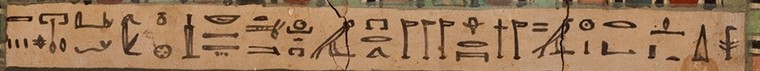

In [30]:
# ── الانبوت: صورة واحدة. غيّر الباث لأي صورة عندك ──
INPUT_IMAGE = '/kaggle/input/datasets/hebaadelali/testimgs-ds/IMG-20260515-WA0044.jpg'   # ← عدّل هنا

result = decipher_image(INPUT_IMAGE)


# ═══════════════════════════════════════════════════════════════
## C — 🌐 Web Backend (Image → EN / AR / Sentiment / Intention)
# ═══════════════════════════════════════════════════════════════

In [31]:
# ═══════════════════════════════════════════════════════════════════════════
#  🌐  C1 — Web Backend:  Image → (CV + NLP) → EN / AR / Sentiment / Intention
#       Flask + ngrok — بيخدم موقع الـ HTML/CSS/JS الفرعوني.
#       بياخد صورة واحدة، بيرجّع نفس الصورة (من غير أي boxes/boundaries)
#       + الترجمة الإنجليزي والعربي + الـ sentiment + الـ intention.
# ═══════════════════════════════════════════════════════════════════════════
import importlib, subprocess, sys
for _mod, _pkg in [('flask', 'flask'), ('flask_cors', 'flask-cors'), ('pyngrok', 'pyngrok')]:
    try:
        importlib.import_module(_mod)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', _pkg], check=False)

import os as _os, time as _time, threading as _threading, tempfile as _tempfile, traceback as _traceback
from pathlib import Path as _Path
from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok

# ── ngrok auth (نفس التوكن — متغيّرش) ───────────────────────────────────────
NGROK_AUTH_TOKEN = _os.environ.get(
    'NGROK_AUTH_TOKEN',
    '3BBILR8WLOgh6uQGi4jU0aN6YoR_68QjQ4J4eRxCyhsjHLWMr'
).strip()
# نفس الدومين الثابت اللي كان في main.js عشان الـ URL يبقى ثابت كل مرة.
NGROK_STATIC_DOMAIN = _os.environ.get(
    'NGROK_DOMAIN', 'irretrievably-unsimpering-darrin.ngrok-free.dev'
).strip()
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

app = Flask(__name__)
CORS(app)  # يسمح للموقع (origin تاني) إنه ينده على الـ API

# قفل واحد حوالين الـ inference عشان مفيش طلبين يتصادموا على الـ GPU
_PIPE_LOCK = _threading.Lock()


def _api_error(message, http=400):
    return jsonify({'success': False, 'error': {'message': str(message)}}), http


@app.route('/api/analyze', methods=['POST', 'OPTIONS'])
def api_analyze():
    """يستقبل صورة → يشغّل الـ pipeline كله → يرجّع الصورة الأصلية + التحليل."""
    if request.method == 'OPTIONS':            # CORS preflight
        return ('', 204)

    # 1) read uploaded image
    if 'image' not in request.files:
        return _api_error('No image uploaded ("image" field is required).')
    file = request.files['image']
    if not file or file.filename == '':
        return _api_error('Empty image file.')

    # 2) optional detection-confidence (slider) — default 0.25
    try:
        conf = float(request.form.get('conf_thresh', 0.25))
    except (TypeError, ValueError):
        conf = 0.25
    conf = max(0.05, min(0.95, conf))

    # 3) save to a temp path that the CV pipeline can open
    suffix = _Path(file.filename).suffix or '.jpg'
    tmp = _tempfile.NamedTemporaryFile(delete=False, suffix=suffix)
    tmp_path = tmp.name
    file.save(tmp_path)
    tmp.close()

    # 4) run the full pipeline  (CV → Gardiner → NLP), one request at a time
    try:
        with _PIPE_LOCK:
            out = decipher_image(tmp_path, layout_conf=conf, sign_conf=conf, show=False)
            image_uri = _img_data_uri(tmp_path)        # ← الصورة الأصلية بدون أي boxes
    except Exception as exc:
        _traceback.print_exc()
        return _api_error(exc, http=500)
    finally:
        try:
            _os.remove(tmp_path)
        except OSError:
            pass

    sent = out.get('sentiment') or {}
    it   = out.get('intention') or {}

    return jsonify({
        'success': True,
        'data': {
            'image'            : image_uri,                                   # data:image/jpeg;base64,...
            'english'          : (out.get('english') or '').strip(),
            'arabic'           : (out.get('arabic')  or '').strip(),
            'german'           : (out.get('german')  or '').strip(),
            'sentiment'        : sent.get('label', 'Neutral'),
            'sent_confidence'  : round(float(sent.get('confidence', 0.0) or 0.0), 4),
            'intention_en'     : it.get('intention_en', '') or '',
            'intention_ar'     : it.get('intention_ar', '') or '',
            'intent_confidence': round(float(it.get('confidence', 0.0) or 0.0), 4),
            'intent_ambiguous' : bool(it.get('ambiguous', False)),
            'n_signs'          : int(out.get('n_signs', 0) or 0),
            'direction'        : out.get('direction') or '',
        }
    }), 200


@app.route('/api/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok', 'version': 'image-multilingual-v1'}), 200


@app.route('/api/status', methods=['GET'])
def status():
    return jsonify({
        'status'           : 'ready',
        'version'          : 'image-multilingual-v1',
        'accepts'          : 'image (multipart/form-data, field "image")',
        'cv_pipeline'      : 'YOLOv11m layout + single-class sign detector + ConvNeXt CVV',
        'nlp_pipeline'     : 'Stage1 → ByT5 → RAG/NLLB (DE) → Seed-X (EN/AR) → sentiment + intention',
        'intention_classes': INTENTION_CLF.n if 'INTENTION_CLF' in globals() else None,
    }), 200


def _run_server():
    app.run(host='0.0.0.0', port=5000, use_reloader=False, debug=False, threaded=True)


_threading.Thread(target=_run_server, daemon=True).start()
_time.sleep(2)

# اقفل أي tunnels قديمة قبل ما نفتح واحدة جديدة
try:
    for _t in ngrok.get_tunnels():
        ngrok.disconnect(_t.public_url)
except Exception:
    pass

# جرّب الدومين الثابت الأول، ولو مش متاح ارجع لـ URL عشوائي
try:
    _tunnel = ngrok.connect(5000, domain=NGROK_STATIC_DOMAIN)
except Exception as _e:
    print(f'[ngrok] static domain not available ({_e}); falling back to a random URL.')
    _tunnel = ngrok.connect(5000)

PUBLIC_URL = _tunnel.public_url

print('=' * 72)
print('🏛️   HIEROGLYPH PIPELINE  —  IMAGE → EN / AR / SENTIMENT / INTENTION')
print(f'🌐   Public URL:\n\n     {PUBLIC_URL}\n')
print('📡   Endpoints:')
print(f'       POST {PUBLIC_URL}/api/analyze     (multipart: image, conf_thresh)')
print(f'       GET  {PUBLIC_URL}/api/health')
print(f'       GET  {PUBLIC_URL}/api/status')
print()
print('👉   لو الـ URL اتغيّر: حطّه في main.js (API_BASE) أو في خانة "Backend URL" في الموقع.')
print('=' * 72)


 * Serving Flask app '__main__'                                                                     
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.19.2.2:5000
Press CTRL+C to quit


🏛️   HIEROGLYPH PIPELINE  —  IMAGE → EN / AR / SENTIMENT / INTENTION
🌐   Public URL:

     https://irretrievably-unsimpering-darrin.ngrok-free.dev

📡   Endpoints:
       POST https://irretrievably-unsimpering-darrin.ngrok-free.dev/api/analyze     (multipart: image, conf_thresh)
       GET  https://irretrievably-unsimpering-darrin.ngrok-free.dev/api/health
       GET  https://irretrievably-unsimpering-darrin.ngrok-free.dev/api/status

👉   لو الـ URL اتغيّر: حطّه في main.js (API_BASE) أو في خانة "Backend URL" في الموقع.


127.0.0.1 - - [10/Jun/2026 19:33:30] "OPTIONS /api/health HTTP/1.1" 200 -
127.0.0.1 - - [10/Jun/2026 19:33:30] "GET /api/health HTTP/1.1" 200 -
127.0.0.1 - - [10/Jun/2026 19:33:36] "OPTIONS /api/analyze HTTP/1.1" 204 -


[CV]  7 signs | 1 line(s) | dir=ltr | ByT5 input ≈ 15 bytes
       line 1: r4 x1 q3 v13 d2 d21 i9


127.0.0.1 - - [10/Jun/2026 19:35:03] "POST /api/analyze HTTP/1.1" 200 -


[DE]  Mögest du mit ihm zufrieden sein.
[EN]  May you be satisfied with him.
